## Experiments

- remove backgrounds
- test multiple seam line views for same poses

In [1]:

    
import numpy as np
import pyrender
from scipy.spatial import cKDTree

def project_vertices_to_image(vertices, camera_info, depth_buffer=None, tolerance=0.01):
    """
    Project 3D vertices to image coordinates and determine visibility.
    
    Args:
        vertices: (N, 3) array of 3D vertex coordinates
        camera_info: Camera object with cam2world, fov, width, height
        depth_buffer: (H, W) depth buffer from rendering (optional for visibility check)
        tolerance: Depth tolerance for visibility check
    
    Returns:
        pixel_coords: (N, 2) array of pixel coordinates
        visibility_mask: (N,) boolean array indicating visibility
        depths: (N,) array of vertex depths in camera space
    """
    
    # Convert vertices to homogeneous coordinates
    vertices_homog = np.hstack([vertices, np.ones((vertices.shape[0], 1))])
    
    # Get camera parameters
    width, height = camera_info.width, camera_info.height
    fov_rad = np.deg2rad(camera_info.fov)
    
    # Convert cam2world to world2cam (view matrix)
    world2cam = np.linalg.inv(camera_info.cam2world)
    
    # Transform vertices to camera space
    vertices_cam = (world2cam @ vertices_homog.T).T
    
    # Extract camera space coordinates
    x_cam = vertices_cam[:, 0]
    y_cam = vertices_cam[:, 1]
    z_cam = vertices_cam[:, 2]  # Depth in camera space
    
    # Create projection matrix manually for better control
    aspect_ratio = width / height
    near = 0.01  # Near clipping plane
    far = 1000.0  # Far clipping plane
    
    # Perspective projection
    f = 1.0 / np.tan(fov_rad / 2.0)  # Focal length in normalized coordinates
    
    # Project to normalized device coordinates (NDC)
    # Note: In camera space, typically -Z is forward, so we use -z_cam
    x_ndc = (f / aspect_ratio) * x_cam / (-z_cam)
    y_ndc = f * y_cam / (-z_cam)
    
    # Convert NDC to pixel coordinates
    # NDC range is [-1, 1], pixel range is [0, width-1] and [0, height-1]
    pixel_x = (x_ndc + 1.0) * width / 2.0
    pixel_y = (1.0 - y_ndc) * height / 2.0  # Flip Y axis for image coordinates
    
    pixel_coords = np.column_stack([pixel_x, pixel_y])
    
    # Basic visibility checks
    visibility_mask = (
        (-z_cam > near) &  # In front of camera (negative Z in camera space)
        (-z_cam < far) &   # Within far clipping plane
        (pixel_x >= 0) &   # Within image bounds
        (pixel_x < width) &
        (pixel_y >= 0) &
        (pixel_y < height)
    )
    
    # Advanced visibility check using depth buffer
    if depth_buffer is not None:
        # Convert camera space depth to depth buffer values
        # This depends on how your depth buffer is encoded
        depth_values = -z_cam  # Assuming depth buffer stores positive distances
        
        # Get corresponding depth buffer values
        px = np.clip(pixel_x.astype(int), 0, width - 1)
        py = np.clip(pixel_y.astype(int), 0, height - 1)
        buffer_depths = depth_buffer[py, px]
        
        # Check if vertex is visible (not occluded)
        # Vertices are visible if their depth is close to or less than buffer depth
        depth_visibility = (buffer_depths > 0) & (depth_values <= buffer_depths + tolerance)
        visibility_mask = visibility_mask & depth_visibility
    
    return pixel_coords, visibility_mask, -z_cam


def improved_visibility_check(garment_mesh_list, body_mesh, camera_info, pyrender_scene, renderer):
    """
    Improved visibility checking for garment vertices.
    
    Args:
        garment_mesh_list: List of garment meshes
        body_mesh: Body mesh
        camera_info: Camera information
        pyrender_scene: Pyrender scene object
        renderer: Pyrender renderer
    
    Returns:
        visibility_results: List of (pixel_coords, visibility_mask, depths) for each garment
    """
    
    # Render the scene to get depth buffer
    try:
        color, depth = renderer.render(pyrender_scene, flags=pyrender.RenderFlags.SKIP_CULL_FACES)
    except Exception as e:
        print(f"Rendering error: {e}")
        return None
    
    visibility_results = []
    
    for garment_mesh in garment_mesh_list:
        # Project vertices and check visibility
        pixel_coords, visibility_mask, depths = project_vertices_to_image(
            garment_mesh.vertices, 
            camera_info, 
            depth_buffer=depth,
            tolerance=0.01  # Adjust based on your needs
        )
        
        visibility_results.append((pixel_coords, visibility_mask, depths))
    
    return visibility_results, color, depth


# Alternative method using ray casting for more accurate occlusion detection
def ray_based_visibility_check(vertices, camera_info, scene_meshes, sample_rays=True):
    """
    Use ray casting to determine vertex visibility more accurately.
    
    Args:
        vertices: (N, 3) array of vertex coordinates
        camera_info: Camera information
        scene_meshes: List of all meshes in the scene (for occlusion testing)
        sample_rays: Whether to sample multiple rays per vertex for better accuracy
    
    Returns:
        visibility_mask: (N,) boolean array
    """
    
    # Get camera position from cam2world matrix
    camera_pos = camera_info.cam2world[:3, 3]
    
    # Calculate ray directions from camera to each vertex
    ray_directions = vertices - camera_pos
    ray_lengths = np.linalg.norm(ray_directions, axis=1)
    ray_directions = ray_directions / ray_lengths[:, np.newaxis]
    
    visibility_mask = np.ones(len(vertices), dtype=bool)
    
    # This is a simplified version - you'd need to implement actual ray-mesh intersection
    # or use a library like trimesh for more accurate results
    
    return visibility_mask


# Usage example with your existing code structure
def process_visibility_improved(scene, camera_info, view_name):
    """
    Improved processing function for your existing code.
    """
    
    body_mesh = scene.body_mesh_dict[view_name]
    garment_mesh_dict = scene.garment_mesh_dict_dict[view_name]
    garment_mesh_list = list(garment_mesh_dict.values())
    
    # Create pyrender objects (your existing code)
    material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=(0.0, 0.0, 0.0, 1.0),
        metallicFactor=0.658,
        roughnessFactor=0.5
    )
    
    pyrender_body_mesh = pyrender.Mesh.from_trimesh(body_mesh, material=material)
    pyrender_garment_mesh_list = [
        pyrender.Mesh.from_trimesh(garment_mesh, material=material)
        for garment_mesh in garment_mesh_list
    ]
    
    pyrender_cam = pyrender.PerspectiveCamera(yfov=np.deg2rad(camera_info.fov))
    pyrender_scene = pyrender.Scene(bg_color=(1.0, 1.0, 1.0, 1.0))
    
    pyrender_scene.add(pyrender_body_mesh)
    for pyrender_garment_mesh in pyrender_garment_mesh_list:
        pyrender_scene.add(pyrender_garment_mesh)
    pyrender_scene.add(pyrender_cam, pose=camera_info.cam2world)
    
    # Add lighting (your existing code)
    intensity = 80.
    light_positions = [
        np.array([1.60614, 1.5341, 1.23701]),
        np.array([1.31844, 1.92831, -2.52238]),
        np.array([-2.80522, 1.2594, 2.34624]),
        np.array([0.160261, 1.81789, 3.52215]),
        np.array([-2.65752, 1.41194, -1.26328])
    ]
    
    for i, pos in enumerate(light_positions):
        light = pyrender.PointLight(color=[1.0, 1.0, 1.0], intensity=intensity)
        light_pose = np.eye(4)
        light_pose[:3, 3] = pos
        pyrender_scene.add(light, pose=light_pose)
    
    # Create renderer
    renderer = pyrender.OffscreenRenderer(
        viewport_width=camera_info.width, 
        viewport_height=camera_info.height
    )
    
    try:
        # Use improved visibility checking
        results = improved_visibility_check(
            garment_mesh_list, body_mesh, camera_info, pyrender_scene, renderer
        )
        
        if results is not None:
            visibility_results, color, depth = results
            return visibility_results, color, depth
        else:
            return None
            
    finally:
        renderer.delete()
    

In [2]:
# CLO Viewpoints

import numpy as np
from dataclasses import dataclass

@dataclass
class CloCamera :
    name: str = None
    cam2world: np.ndarray = None
    fov: float = None
    width: int = None
    height: int = None
    
camera_info = {
    "Custom_View_0": CloCamera(
        name = "Custom_View_1",
        cam2world = np.array([
            [1, 0, 0, -9.2e-05],
            [0, 1, 0, -896.122],
            [0, 0, 1, -7998.56],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),  
    "Custom_View_1": CloCamera(
        name = "Custom_View_1",
        cam2world = np.array([
            [1, 0, 0, -9.2e-05],
            [0, 1, 0, -896.122],
            [0, 0, 1, -7998.56],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),  
    "Custom_View_2": CloCamera(
        name = "Custom_View_2",
        cam2world = np.array([
            [0.707107, 0, 0.707107, 1.01581],
            [0, 1, 0, -896.122],
            [-0.707107, 0, 0.707107, -7998.98],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_3": CloCamera(
        name = "Custom_View_3",
        cam2world = np.array([
            [0.707107, 0, -0.707107, -1.01581],
            [0, 1, 0, -896.122],
            [0.707107, 0, 0.707107, -7998.98],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_4": CloCamera(
        name = "Custom_View_4",
        cam2world = np.array([
            [0, 0, 1, 1.44049],
            [0, 1, 0, -896.122],
            [-1, 0, 0, -8000],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_5": CloCamera(
        name = "Custom_View_5",
        cam2world = np.array([
            [0, 0, -1, -1.44093],
            [0, 1, 0, -896.122],
            [1, 0, 0, -8000],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_6": CloCamera(
        name = "Custom_View_6",
        cam2world = np.array([
            [-1, 0, 0, -0.000608],
            [0, 1, 0, -896.122],
            [0, 0, -1, -8001.44],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_7": CloCamera(
        name = "Custom_View_7",
        cam2world = np.array([
            [-0.677822, 0, -0.735226, -1.0604],
            [-0.051424, 0.997551, 0.047409, -893.857],
            [0.733425, 0.069943, -0.676162, -8063.65],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_8": CloCamera(
        name = "Custom_View_8",
        cam2world = np.array([
            [-0.773786, 0, 0.633447, 0.911345],
            [0.035455, 0.998432, 0.043309, -894.654],
            [-0.632454, 0.055971, -0.772573, -8051.27],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_9": CloCamera(
        name = "Custom_View_9",
        cam2world = np.array([
            [0.847255, 0, 0.531186, 0.765239],
            [0.223366, 0.907291, -0.356274, -813.553],
            [-0.48194, 0.420503, 0.768707, -8375.71],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    ),
    "Custom_View_10": CloCamera(
        name = "Custom_View_10",
        cam2world = np.array([
            [0.716937, 0, -0.697138, -1.0054],
            [-0.275326, 0.918708, -0.283145, -823.685],
            [0.640466, 0.394938, 0.658656, -8352.96],
            [0, 0, 0, 1]
        ]),
        fov = 15,
        width = 480,
        height = 640
    )   
}
for camera in camera_info.values() :
    camera.cam2world = np.linalg.inv(camera.cam2world)

In [3]:
import os, sys
import json
import cv2
from glob import glob
from pathlib import Path
import trimesh
import xml.etree.ElementTree as ET

from analysis_utils import visualize_meshes_plotly

@dataclass
class SeamDressScene :
    garment_dir: str = None
    garment_version: str = None
    
    spec_path_list: list = None
    stitch_dict_list: list = None
    
    # pose_list: list = None
    view_name_list: list = None
    
    mesh_path_list: list = None
    meta_path_list: list = None
    mesh_list: list = None
    
    rendered_path_list: list = None

    def __post_init__(self, garment_version = "01"):
        self.garment_id_list = str(Path(self.garment_dir).name).split("__")[::2]
        # self.spec_path_list = list(map(
        #     lambda gid : str(Path(self.garment_dir) / f"{gid}__{garment_version}__specification.json"),
        #     self.garment_id_list,
        # ))
        
        self.spec_path_list = []
        for garment_id in self.garment_id_list :
            spec_path = str(Path(self.garment_dir) / f"{garment_id}__{garment_version}__specification.json")
            if os.path.exists(spec_path) :
                self.spec_path_list.append(spec_path)
            else :
                spec_path = str(Path(self.garment_dir) / f"{garment_id}_specification.json")
                self.spec_path_list.append(spec_path)
        
        self.stitch_dict_list = []
        for spec_path in self.spec_path_list:
            with open(spec_path, "r") as f:
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]):
                stitch_dict[idx] = stitch
            self.stitch_dict_list.append(stitch_dict)
            
        self.stitch_dict_dict = {}
        for garment_id, spec_path in zip(self.garment_id_list, self.spec_path_list) :
            with open(spec_path, "r") as f :
                spec = json.load(f)
            stitch_dict = {}
            for idx, stitch in enumerate(spec["pattern"]["stitches"]) :
                stitch_dict[idx] = stitch
            self.stitch_dict_dict[garment_id] = stitch_dict
        
        self.garment_count = len(self.spec_path_list)
        # self.rendered_path_list = list(filter(
        #     lambda x : "__" in Path(x).stem,
        #     glob(str(Path(self.garment_dir) / "Custom*.png"))
        # ))
        
        self.meta_path_list = sorted(
            glob(os.path.join(self.garment_dir, "*meta_data.xml")),
            key = lambda x : int(Path(x).stem.split("_")[2])
        )
        self.rendered_path_list = list(map(
            lambda x : str(Path(self.garment_dir) / f"{Path(x).stem[:-10]}_1.png"),
            self.meta_path_list
        ))
        
        self.view_name_list = list(map(
            lambda x: Path(x).stem[:-2],
            self.rendered_path_list
        ))
        self.rendered_img_dict = dict(zip(
            self.view_name_list,
            list(map(
                lambda x : cv2.imread(x),
                self.rendered_path_list
            ))
        ))
        
        self.mesh_path_list = sorted(
            glob(str(Path(self.garment_dir)/"*.obj")),
            key = lambda x : int(Path(x).stem.split("_")[2])
        )
        
        # from pprint import pprint
        # pprint(list(map(
        #     os.path.basename,
        #     self.rendered_path_list
        # )))
        # print()
        # pprint(list(map(
        #     os.path.basename,
        #     self.meta_path_list
        # )))
        # print()
        # pprint(list(map(
        #     os.path.basename,
        #     self.mesh_path_list
        # )))
        
        
        
        assert list(map(
            lambda x : Path(x).stem[:-2], self.rendered_path_list
        )) == list(map(
            lambda x : Path(x).stem, self.mesh_path_list
        )) and list(map(
            lambda x : Path(x).stem, self.mesh_path_list
        )) == list(map(
            lambda x : Path(x).stem[:-10], self.meta_path_list
        ))
        
    def read_mesh(self):
        
        self.body_mesh_dict = {}
        self.garment_mesh_dict_dict = {}
        for mesh_path in self.mesh_path_list :
            view_name = str(Path(mesh_path).stem)
                            
            mesh_scene = trimesh.load(mesh_path)
            mesh_list = []
            for geometry in mesh_scene.geometry.values() :
                if isinstance(geometry, trimesh.Trimesh):
                    mesh_list.append(geometry)
            self.body_mesh_dict[view_name] = trimesh.util.concatenate(mesh_list[:-self.garment_count])
            self.garment_mesh_dict_dict[view_name] = dict(zip(
                self.garment_id_list,
                # mesh_list[-1:-self.garment_count-1:-1]
                mesh_list[-self.garment_count:]
            ))
        
        # self.read_stitch_vert()
        
    def read_stitch_vert(self, same_vert_thresh=1e-1) :
        """
        Set below member variables.
        - self.stitch_vert_mask_dict_list
            - list for each garment, dict containing stitch vertex mask for each stitch
        - self.stitch_vert_idx_arr_list
        - self.stitch_vert_idx_arr_dict_list
        """
        
        self.stch_vert_idx_arr_list_dict_dict = {}
        self.stch_vert_mask_list_dict_dict = {}
        self.seam_line_vert_idx_arr_list_dict_dict = {}
        
        for view_name, meta_path in zip(self.view_name_list, self.meta_path_list) :
            assert view_name == Path(meta_path).stem[:-10], f"inconsistent view name and meta path"
        
            # CLO saved metatdata does not distinguish stitches between garments
            raw_stitch_vert_idx_list_list = []
            
            tree = ET.parse(meta_path)
            root = tree.getroot()
            seam_line_pair_list = root.find("SeamLinePairList")
            for pair in seam_line_pair_list.findall("SeamLinePair") :
                seam_lines = pair.findall("SeamLine")
                if len(seam_lines) >= 2 :
                    first_indexes_str = seam_lines[0].get("MeshPointIndexes")
                    second_indexes_str = seam_lines[1].get("MeshPointIndexes")
                    first_list = list(map(lambda x: int(x)-1, first_indexes_str.split("/")))
                    second_list = list(map(lambda x: int(x)-1, second_indexes_str.split("/")))
                    raw_stitch_vert_idx_list_list.append(first_list + second_list)
                else :
                    print("SeamLinePair has less than 2 SeamLine")
            
            stch_vert_idx_arr_list_dict = {}
            if len(self.garment_id_list) == 1 : # single garment
                garment_id = self.garment_id_list[0]
                stch_vert_idx_arr_list_dict[garment_id] = []
                for idx in self.stitch_dict_dict[garment_id].keys() :
                    stch_vert_idx_arr_list_dict[garment_id].append(
                        np.array(raw_stitch_vert_idx_list_list[idx])
                    )
            elif len(self.garment_id_list) == 2 : # combination of two garments
                bottom_id = self.garment_id_list[1]
                top_id = self.garment_id_list[0]
                
                stch_vert_idx_arr_list_dict[bottom_id] = []
                stch_vert_idx_arr_list_dict[top_id] = []
                
                for idx in self.stitch_dict_dict[bottom_id].keys() :
                    stch_vert_idx_arr_list_dict[bottom_id].append(
                        np.array(raw_stitch_vert_idx_list_list[idx])
                    )
                
                idx_accum = idx + 1
                vert_offset = len(self.garment_mesh_dict_dict[view_name][bottom_id].vertices)
                
                for idx in self.stitch_dict_dict[top_id].keys() :
                    stch_vert_idx_arr_list_dict[top_id].append(
                        np.array(raw_stitch_vert_idx_list_list[idx + idx_accum]) - vert_offset
                    )
            
            stch_vert_mask_list_dict = {}
            for garment_id, stch_vert_idx_arr_list in stch_vert_idx_arr_list_dict.items() :
                garment_mesh = self.garment_mesh_dict_dict[view_name][garment_id]
                vert_count = garment_mesh.vertices.shape[0]
                
                stch_vert_mask_list_dict[garment_id] = []
                for (stch_idx, stch_vert_idx_arr) in enumerate(stch_vert_idx_arr_list) :
                    mask = np.zeros(vert_count, dtype=bool)
                    mask[stch_vert_idx_arr] = True
                    stch_vert_mask_list_dict[garment_id].append(mask)
                
            # dict per garment, dict per stitch, array of seam line vertex idx, ordered so that it follows seam line linearly
            # vertex idx is already sorted linearly. just need to remove overlapping vertices
            # In the case of stitch between two garments, every seam vertex is duplicated,
            seam_line_vert_idx_arr_list_dict = {}
            for garment_id, stch_vert_idx_arr_list in stch_vert_idx_arr_list_dict.items() :
                seam_line_vert_idx_arr_list_dict[garment_id] = []
                
                garment_mesh = self.garment_mesh_dict_dict[view_name][garment_id]
                vert_count = garment_mesh.vertices.shape[0]
                
                for stch_idx, stch_vert_idx_arr in enumerate(stch_vert_idx_arr_list) :
                    seam_line_vert_idx_list = [stch_vert_idx_arr[0]]
                    for vert_idx in stch_vert_idx_arr[1:] :
                        
                        dist_arr = garment_mesh.vertices[seam_line_vert_idx_list] - garment_mesh.vertices[[vert_idx]]
                        dist_arr = np.linalg.norm(dist_arr, axis=1)
                        if np.min(dist_arr) < same_vert_thresh :
                            continue
                        seam_line_vert_idx_list.append(vert_idx)
                        # for i in seam_line_vert_idx_list :
                        #     if (garment_mesh.vertices[vert_idx] == garment_mesh.vertices[i]).all() :
                        #         break
                        # else :
                        #     seam_line_vert_idx_list.append(vert_idx)

                    seam_line_vert_idx_arr_list_dict[garment_id].append(np.array(seam_line_vert_idx_list))

            self.stch_vert_idx_arr_list_dict_dict[view_name] = stch_vert_idx_arr_list_dict
            self.stch_vert_mask_list_dict_dict[view_name] = stch_vert_mask_list_dict
            self.seam_line_vert_idx_arr_list_dict_dict[view_name] = seam_line_vert_idx_arr_list_dict

[Line(start=(-54.7448-1465.06j), end=(-54.7448-838.648j)), CubicBezier(start=(-54.7448-838.648j), control1=(-54.7448-765.201j), control2=(-51.5242-692.01j), end=(-64.1571-619.076j)), Line(start=(-64.1571-619.076j), end=(-134.807-619.076j)), Line(start=(-134.807-619.076j), end=(-155.083-776.717j)), Line(start=(-155.083-776.717j), end=(-167.014-619.076j)), Line(start=(-167.014-619.076j), end=(-205.762-619.076j)), Line(start=(-205.762-619.076j), end=(-217.693-794.328j)), Line(start=(-217.693-794.328j), end=(-229.624-619.076j)), Line(start=(-229.624-619.076j), end=(-287.746-619.076j)), Line(start=(-287.746-619.076j), end=(-287.746-658.776j)), CubicBezier(start=(-287.746-658.776j), control1=(-273.489-849.437j), control2=(-308.664-913.564j), end=(-350.502-913.564j)), CubicBezier(start=(-350.502-913.564j), control1=(-339.169-1023.62j), control2=(-333.463-1198.29j), end=(-333.463-1455.9j)), Line(start=(-333.463-1455.9j), end=(-54.7448-1465.06j))]
[Line(start=(308.088-1336.48j), end=(550.556-13

In [4]:

import random
import matplotlib.pyplot as plt
from analysis_utils import visualize_meshes_plotly


In [12]:
import os, sys
from glob import glob
import random

# garment_dir_list = sorted(glob(os.path.join("..", "SAMPLE_DATA", "GCD__GOOD", "*")))
garment_dir_list = sorted(glob(os.path.join("..", "SAMPLE_DATA", "0822", "*")))

IDX = 1
IDX = 0
IDX = 2


scene = SeamDressScene(Path(garment_dir_list[IDX]))
scene.read_mesh()
scene.read_stitch_vert(same_vert_thresh=3)

In [13]:
scene.view_name_list

[]

In [ ]:
import pickle
import pyrender

VIS = True
NROWS = 4
NCOLS = 2

MIN_CONSEC_VERT_TO_BE_SEGMENT = 3
MIN_CONSEC_VERT_TO_DISCONNECT = 2

depth_list = []
# for rendered_img_path in scene.rendered_path_list :
for view_name, rendered_img_path in zip(scene.view_name_list, scene.rendered_path_list) :
    
    assert view_name == Path(rendered_img_path).stem[:-2], f"{view_name} != {Path(rendered_img_path).stem[:-2]}"
    
    # print(rendered_img_path)
    
    # pose_name, cam_name = Path(rendered_img_path).stem.split("__")
    # cam_name = "_".join(cam_name.split("_")[:-1])
    # view_name = Path(rendered_img_path).stem[:-2]
    cam_name, pose_name = view_name.split("__")
    
    cam_info = camera_info[cam_name]

    # body_mesh = scene.body_mesh_dict[pose_name]
    # garment_mesh_dict = scene.garment_mesh_dict_dict[pose_name]
    body_mesh = scene.body_mesh_dict[view_name]
    garment_mesh_dict = scene.garment_mesh_dict_dict[view_name]
    garment_mesh_list = list(garment_mesh_dict.values())

    if VIS :
        PLOT_IDX = 1
        plt.figure(figsize=(20, 60))
        ax = plt.subplot(NROWS, NCOLS, PLOT_IDX); PLOT_IDX += 1
        ax.imshow(plt.imread(rendered_img_path))
        
    material = pyrender.MetallicRoughnessMaterial(
        baseColorFactor=(0.0, 0.0, 0.0, 1.0),  # RGB color, Alpha
        metallicFactor=0.658,  # Range: [0.0, 1.0]
        roughnessFactor=0.5  # Range: [0.0, 1.0]
    )
    
    pyrender_body_mesh = pyrender.Mesh.from_trimesh(
        body_mesh, material=material
    )
    
    pyrender_garment_mesh_list = [pyrender.Mesh.from_trimesh(
        garment_mesh, material=material
    ) for garment_mesh in garment_mesh_list]
    
    
    pyrender_cam = pyrender.PerspectiveCamera(
        yfov = np.deg2rad(cam_info.fov),
    )
    
    pyrender_scene = pyrender.Scene(bg_color=(1.0, 1.0, 1.0, 1.0))
    
    pyrender_scene.add(pyrender_body_mesh)
    
    for pyrender_garment_mesh in pyrender_garment_mesh_list :
        pyrender_scene.add(pyrender_garment_mesh)
    pyrender_scene.add(pyrender_cam, pose=cam_info.cam2world)
    
    camera_node = list(filter(
        lambda x : x.camera is not None,
        pyrender_scene.get_nodes()
    ))[-1]
    
    
    intensity = 80.
    light_positions = [
        np.array([1.60614, 1.5341, 1.23701]),
        np.array([1.31844, 1.92831, -2.52238]),
        np.array([-2.80522, 1.2594, 2.34624]),
        np.array([0.160261, 1.81789, 3.52215]),
        np.array([-2.65752, 1.41194, -1.26328])
    ]
    light_colors = [
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0],
        [1.0, 1.0, 1.0]
    ]

    for i in range(5):
        light = pyrender.PointLight(color=light_colors[i], intensity=intensity)
        light_pose = np.eye(4)
        light_pose[:3, 3] = light_positions[i]
        pyrender_scene.add(light, pose=light_pose)

    try :    
        r = pyrender.OffscreenRenderer(
            viewport_width=cam_info.width, viewport_height=cam_info.height
        )
        flags = pyrender.RenderFlags.SKIP_CULL_FACES
        color, depth = r.render(pyrender_scene, flags=flags)
        r.delete()
        depth_list.append(depth)
    except Exception as e :
        print(e)
        continue
    
    # remove image backgground and save image
    bg_img = plt.imread(rendered_img_path)
    mask = depth.copy()
    mask[mask != 0] = 1
    bg_img[:, :, -1] = mask
    plt.imsave(
        os.path.join(scene.garment_dir, f"{view_name}.png"),
        bg_img
    )
    
    if VIS :
        ax = plt.subplot(NROWS, NCOLS, PLOT_IDX); PLOT_IDX += 1
        ax.imshow(bg_img)
        # ax.imshow(plt.imread(rendered_img_path), alpha=0.5)
        # ax.imshow(color, alpha=0.5)
        
    width, height = cam_info.width, cam_info.height
    view_matrix = np.linalg.inv(pyrender_scene.get_pose(camera_node))
    proj_matrix = camera_node.camera.get_projection_matrix(width, height)
    
    visibility_mask_list = []
    pixel_coords_list = []
    for garment_mesh in garment_mesh_list :
        vertices_homog = np.hstack([
            garment_mesh.vertices,
            np.ones((garment_mesh.vertices.shape[0], 1))
        ])

        view_proj = proj_matrix @ view_matrix
        projected = vertices_homog @ view_proj.T

        z_coords = projected[:, 2].copy()
        projected = projected[:, :3] / projected[:, 3:4]

        pixel_coords = np.zeros((projected.shape[0], 2))
        pixel_coords[:, 0] = (projected[:, 0] + 1.0) * width / 2.0
        pixel_coords[:, 1] = height - (projected[:, 1] + 1.0) * height / 2.0

        px = np.clip(pixel_coords[:, 0].astype(int), 0, width - 1)
        py = np.clip(pixel_coords[:, 1].astype(int), 0, height - 1)

        THRESHOLD = -0.5
        THRESHOLD = -70.
        # THRESHOLD = -80.
        visibility_mask = (
            z_coords > 0
        ) &  (
            pixel_coords[:, 0] >= 0
        ) & (
            pixel_coords[:, 0] < width
        ) & (
            pixel_coords[:, 1] >= 0
        ) & (
            pixel_coords[:, 1] < height
        ) & (
            z_coords + THRESHOLD <= depth[py, px]
        )
        
        visibility_mask_list.append(visibility_mask)
        pixel_coords_list.append(pixel_coords)
        
        
        if VIS :
            ax = plt.subplot(NROWS, NCOLS, PLOT_IDX); PLOT_IDX += 1
            ax.imshow(bg_img)
            ax.scatter(
                pixel_coords[visibility_mask][:, 0],
                pixel_coords[visibility_mask][:, 1],
                c="red",
                s=10,
            )

            ax = plt.subplot(NROWS, NCOLS, PLOT_IDX); PLOT_IDX += 1
            ax.imshow(bg_img)
            ax.scatter(
                pixel_coords[~visibility_mask][:, 0],
                pixel_coords[~visibility_mask][:, 1],
                c="blue",
                s=10,
            )
        
        
        
    visible_seam_line_dict_dict = {}
    
    for idx, garment_id in enumerate(scene.stitch_dict_dict.keys()) :
        visible_seam_line_dict_dict[garment_id] = {}
        
        print(idx, garment_id)
        garment_mesh = garment_mesh_dict[garment_id]
        vert_count = garment_mesh.vertices.shape[0]
        
        stitch_dict = scene.stitch_dict_dict[garment_id]
        # seam_line_vert_idx_arr_dict = scene.seam_line_vert_idx_arr_dict_dict[garment_id]
        seam_line_vert_idx_arr_list = scene.seam_line_vert_idx_arr_list_dict_dict[view_name][garment_id]
        
        visibility_mask = visibility_mask_list[idx]
        pixel_coords = pixel_coords_list[idx]
        
        
        # for stch_idx, seam_line_vert_idx_arr in seam_line_vert_idx_arr_dict.items() :
        for stch_idx, seam_line_vert_idx_arr in enumerate(seam_line_vert_idx_arr_list) :
            # seam_line_vert_idx_arr = np.array(seam_line_vert_idx_arr)
            
            seam_line_vis_mask = []
            for seam_vert_idx in seam_line_vert_idx_arr :
                seam_line_vis_mask.append(visibility_mask[seam_vert_idx])
            seam_line_vis_mask = np.array(seam_line_vis_mask)
                
            # If length of disconnection between visible seam vertices
            # is less then MIN_CONSEC_VERT_TO_DISCONNECT,
            # consider the disconnection is connected
            # (which change invisible seam vertices to visible)
            idx = 0
            while idx < len(seam_line_vis_mask) :
                if idx >= len(seam_line_vis_mask) -2 :
                    break

                while not (seam_line_vis_mask[idx] == True and seam_line_vis_mask[idx + 1] == False) :
                    if idx >= len(seam_line_vis_mask) - 2 :
                        break
                    idx += 1
                if idx >= len(seam_line_vis_mask) - 2 :
                    break
                window_end_idx = min(idx + MIN_CONSEC_VERT_TO_DISCONNECT + 1, len(seam_line_vis_mask) - 1)
                for rid in range(window_end_idx, idx, -1) :
                    if seam_line_vis_mask[rid] == True :
                        seam_line_vis_mask[idx:rid] = True
                        break
                idx = rid
            

            # If length of connection between visible seam vertices
            # is less then MIN_CONSEC_VERT_TO_BE_SEGMENT,
            # consider the connection is not a segment
            # (which change visible seam vertices to invisible)
            idx = 0
            while idx < len(seam_line_vis_mask) :
                if seam_line_vis_mask[idx] != True :
                    idx += 1
                    continue
                idx2 = idx + 1
                while idx2 < len(seam_line_vis_mask) and seam_line_vis_mask[idx2] == True :
                    idx2 += 1
                if idx2 - idx < MIN_CONSEC_VERT_TO_BE_SEGMENT :
                    seam_line_vis_mask[idx:idx2] = False
                idx = idx2
                
            line_segment_idx_arr_list = []
            line_segment_pos_arr_list = []
            if True in seam_line_vis_mask :
                idx = seam_line_vis_mask.tolist().index(True)
                while idx < len(seam_line_vis_mask) :
                    line_segment_idx_list = []
                    line_segment_pos_list = []
                    while idx < len(seam_line_vis_mask) and seam_line_vis_mask[idx] == True :
                        line_segment_idx_list.append(
                            seam_line_vert_idx_arr[idx]
                        )
                        line_segment_pos_list.append(
                            pixel_coords[seam_line_vert_idx_arr[idx]]
                        )
                        idx += 1
                    if len(line_segment_idx_list) > 0 :
                        line_segment_idx_arr_list.append(np.array(line_segment_idx_list))
                        line_segment_pos_arr_list.append(np.array(line_segment_pos_list))
                    idx += 1

            if len(line_segment_pos_arr_list) > 0 :
                segment_edge_len_arr_list = []
                segment_t_arr_list = []
                segment_u_arr_list = []
                segment_v_arr_list = []
                for segment_pos_arr in line_segment_pos_arr_list :
                    i_vec = segment_pos_arr[-1] - segment_pos_arr[0]
                    j_vec = np.array([i_vec[1], -i_vec[0]])
                    
                    i_vec_normalized = i_vec / np.linalg.norm(i_vec)
                    j_vec_normalized = j_vec / np.linalg.norm(j_vec)
                    
                    edge_len_arr = np.concatenate((
                        [0],
                        np.linalg.norm(segment_pos_arr[1:] - segment_pos_arr[:-1], axis=1)
                    ))
                    segment_edge_len_arr_list.append(edge_len_arr)
                    t_arr = np.cumsum(edge_len_arr) / np.sum(edge_len_arr)
                    
                    vect_arr = segment_pos_arr - segment_pos_arr[0]
                    u_arr = np.sum(vect_arr * i_vec_normalized, axis=1) / np.linalg.norm(i_vec)
                    v_arr = np.sum(vect_arr * j_vec_normalized, axis=1) / np.linalg.norm(j_vec)
                    
                    segment_t_arr_list.append(t_arr)
                    segment_u_arr_list.append(u_arr)
                    segment_v_arr_list.append(v_arr)
                
                    
                    if len(t_arr) != len(segment_pos_arr) :
                        print(segment_pos_arr.shape, t_arr.shape, u_arr.shape, v_arr.shape)
                        print("error")
                    
                    
                    if len(t_arr) != len(u_arr) or len(t_arr) != len(v_arr) :
                        print(edge_len_arr.shape, t_arr.shape, u_arr.shape, v_arr.shape)
                        print("error")
                    
                    error_num = np.sum(
                        vect_arr - (u_arr.reshape(-1, 1) * i_vec.reshape(1, -1) + v_arr.reshape(-1, 1) * j_vec.reshape(1, -1))
                    )
                    if error_num > 1e-6 :
                        print(vect_arr.shape, u_arr.shape, v_arr.shape)
                        print(error_num)
                        print("error")

                visible_seam_line_dict_dict[garment_id][stch_idx] = {
                    "segment_idx_arr_list" : line_segment_idx_arr_list,
                    "segment_pos_arr_list" : line_segment_pos_arr_list,
                    "segment_edge_len_arr_list" : segment_edge_len_arr_list,
                    "segment_t_arr_list" : segment_t_arr_list,
                    "segment_u_arr_list" : segment_u_arr_list,
                    "segment_v_arr_list" : segment_v_arr_list
                }

    with open(
        str(Path(scene.garment_dir) / f"{view_name}.pkl"), "wb"
    ) as f :
        pickle.dump(
            visible_seam_line_dict_dict, f
        )

    if VIS :
        ax = plt.subplot(NROWS, NCOLS, PLOT_IDX); PLOT_IDX += 1
        ax.imshow(bg_img)
        
        vis_seam_seg_pos_list = []
        for garment_id in visible_seam_line_dict_dict.keys() :
            for stch_idx, sema_line in visible_seam_line_dict_dict[garment_id].items() :
                for segment_pos_arr in sema_line['segment_pos_arr_list'] :
                    vis_seam_seg_pos_list.append(segment_pos_arr)
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(vis_seam_seg_pos_list)))
        for pos_arr, color in zip(vis_seam_seg_pos_list, color_list) :
            ax.plot(pos_arr[:, 0], pos_arr[:, 1], color=color)
        
        ax = plt.subplot(NROWS, NCOLS, PLOT_IDX); PLOT_IDX += 1
        
        vis_seam_seg_pos_list = []
        for garment_id in visible_seam_line_dict_dict.keys() :
            for stch_idx, sema_line in visible_seam_line_dict_dict[garment_id].items() :
                for segment_pos_arr in sema_line['segment_pos_arr_list'] :
                    vis_seam_seg_pos_list.append(segment_pos_arr)
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(vis_seam_seg_pos_list)))
        for pos_arr, color in zip(vis_seam_seg_pos_list, color_list) :
            ax.plot(pos_arr[:, 0], -pos_arr[:, 1], color=color)
        
        
        
        plt.show()
        

    print()
    print()

(12939,) (12939, 2)


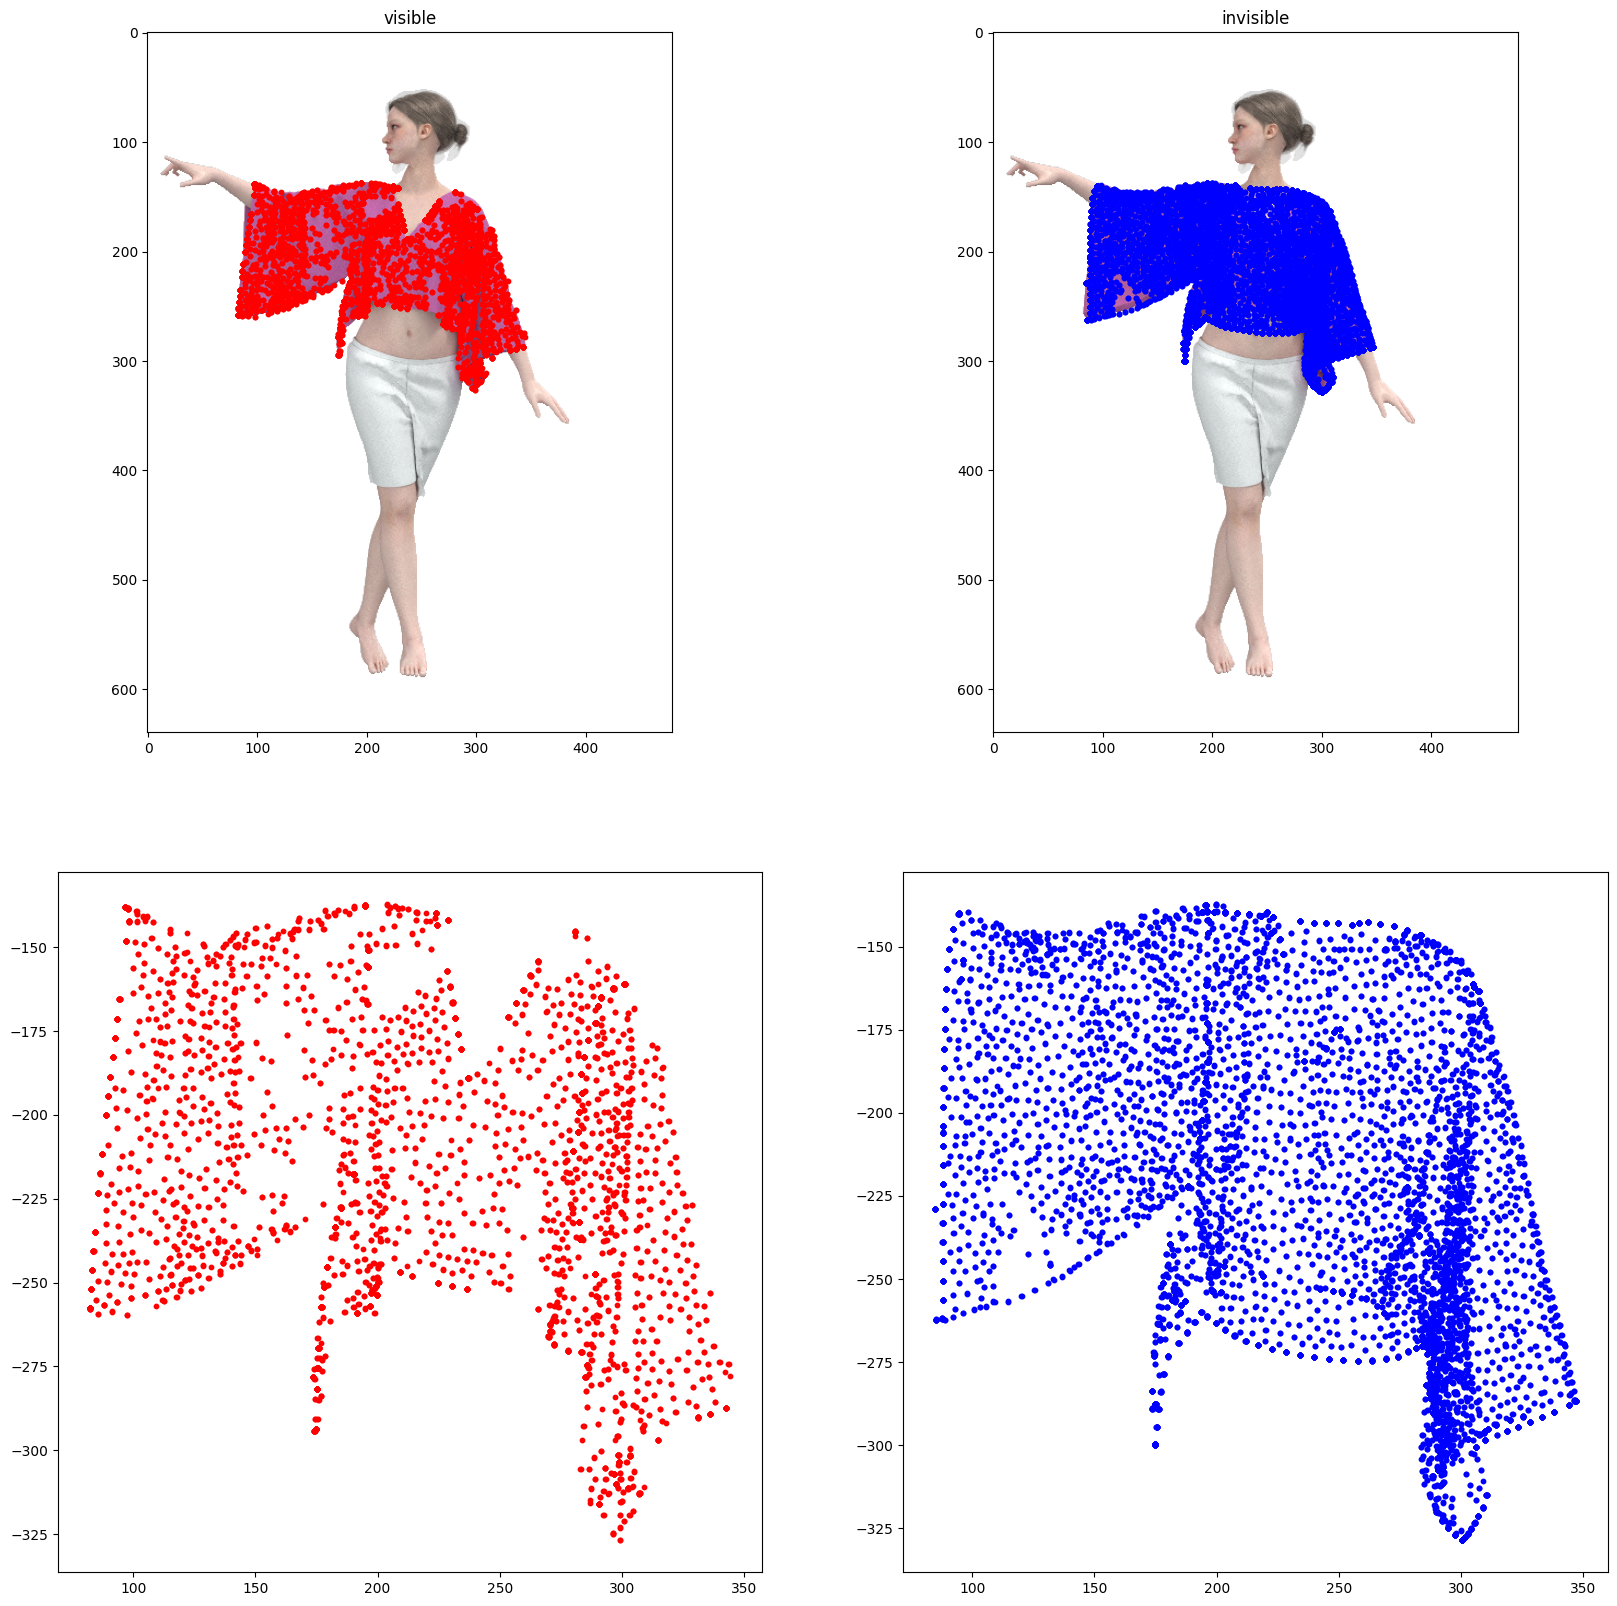

(5096,) (5096, 2)


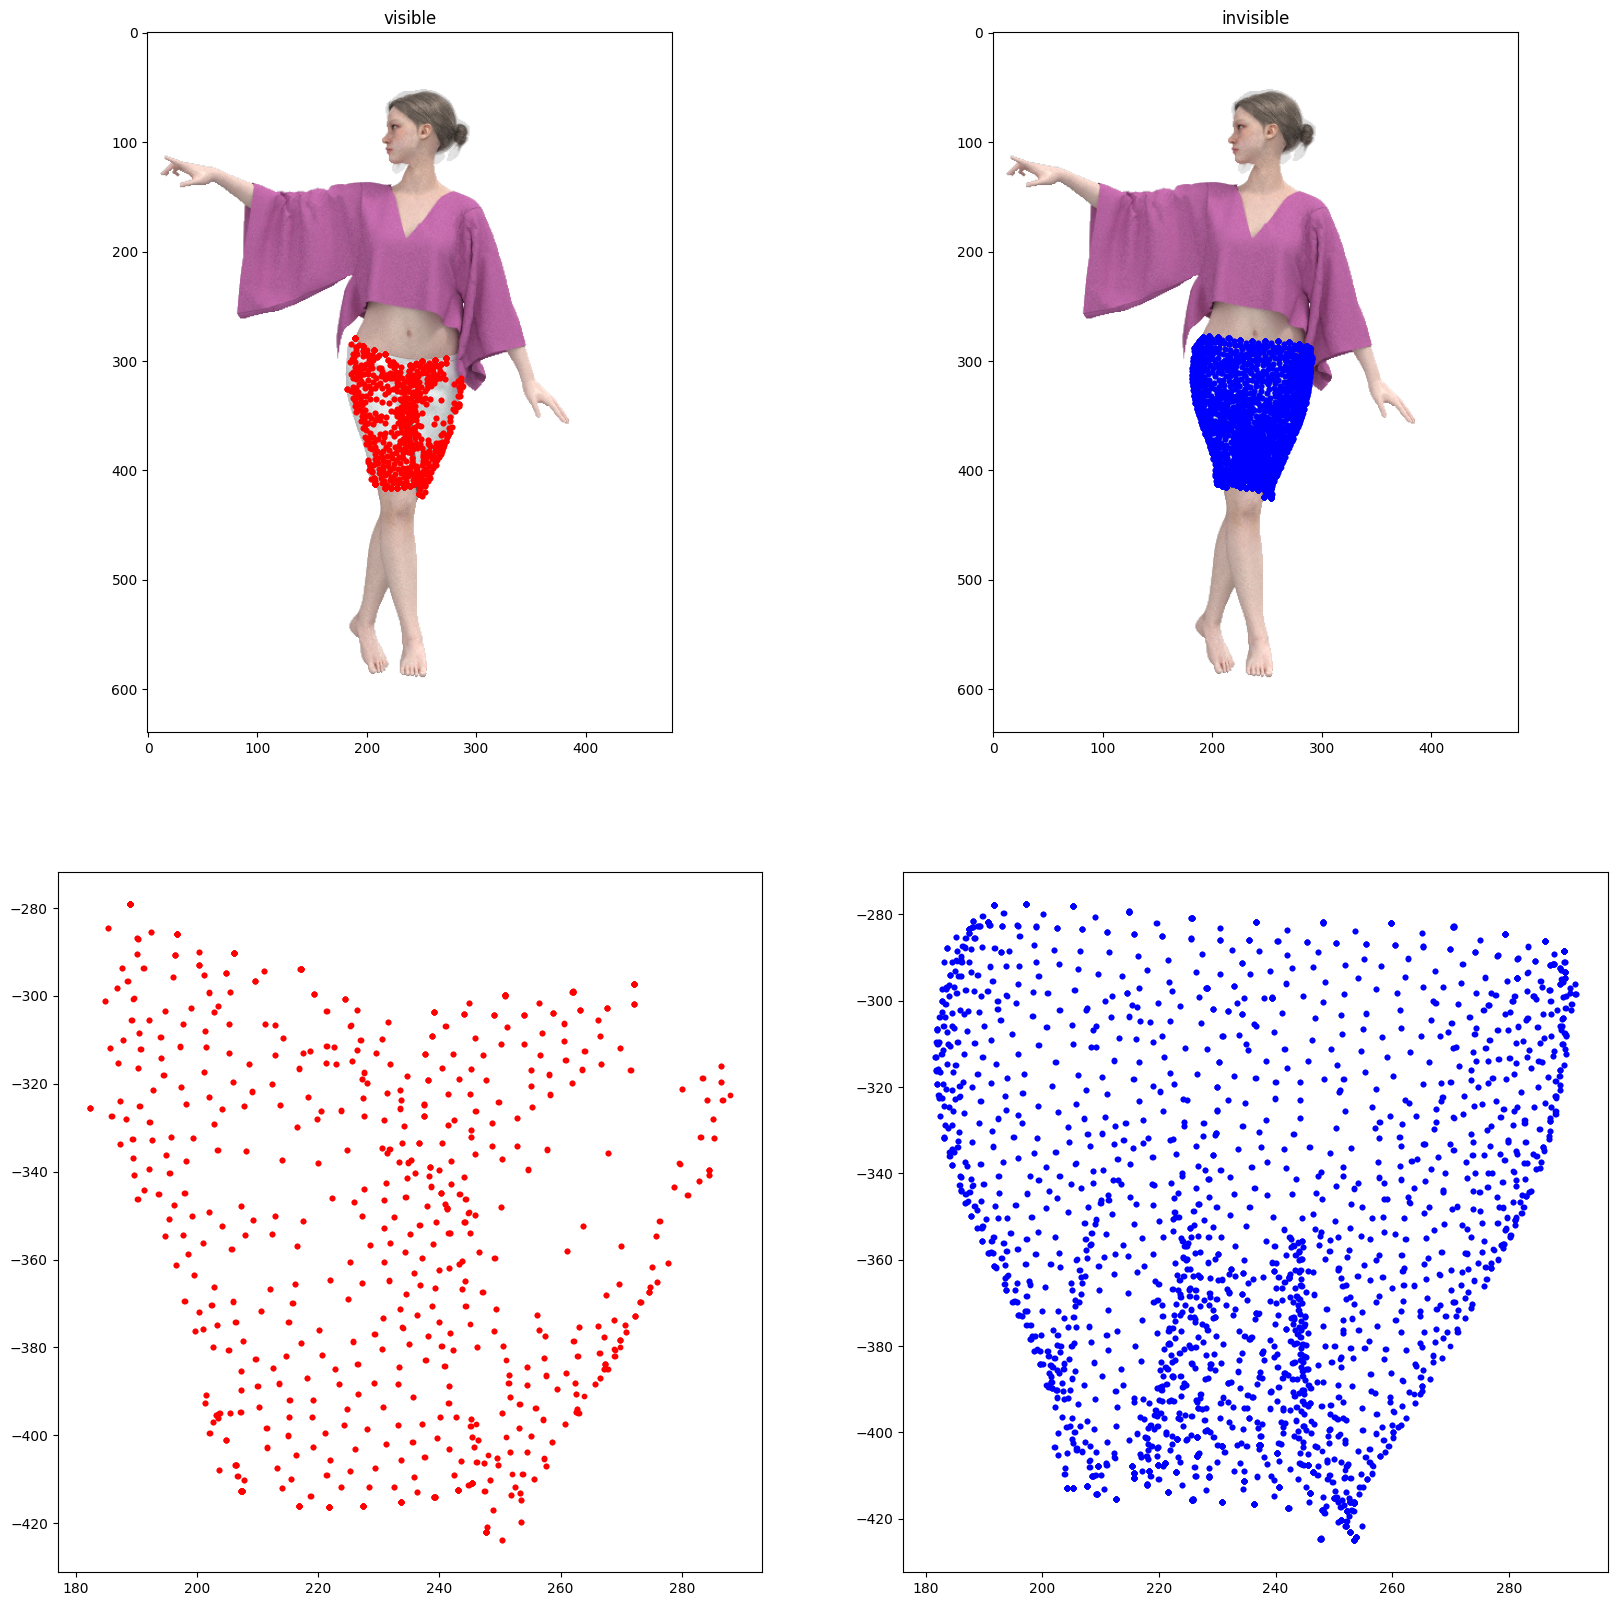

(11791,) (11791, 2)


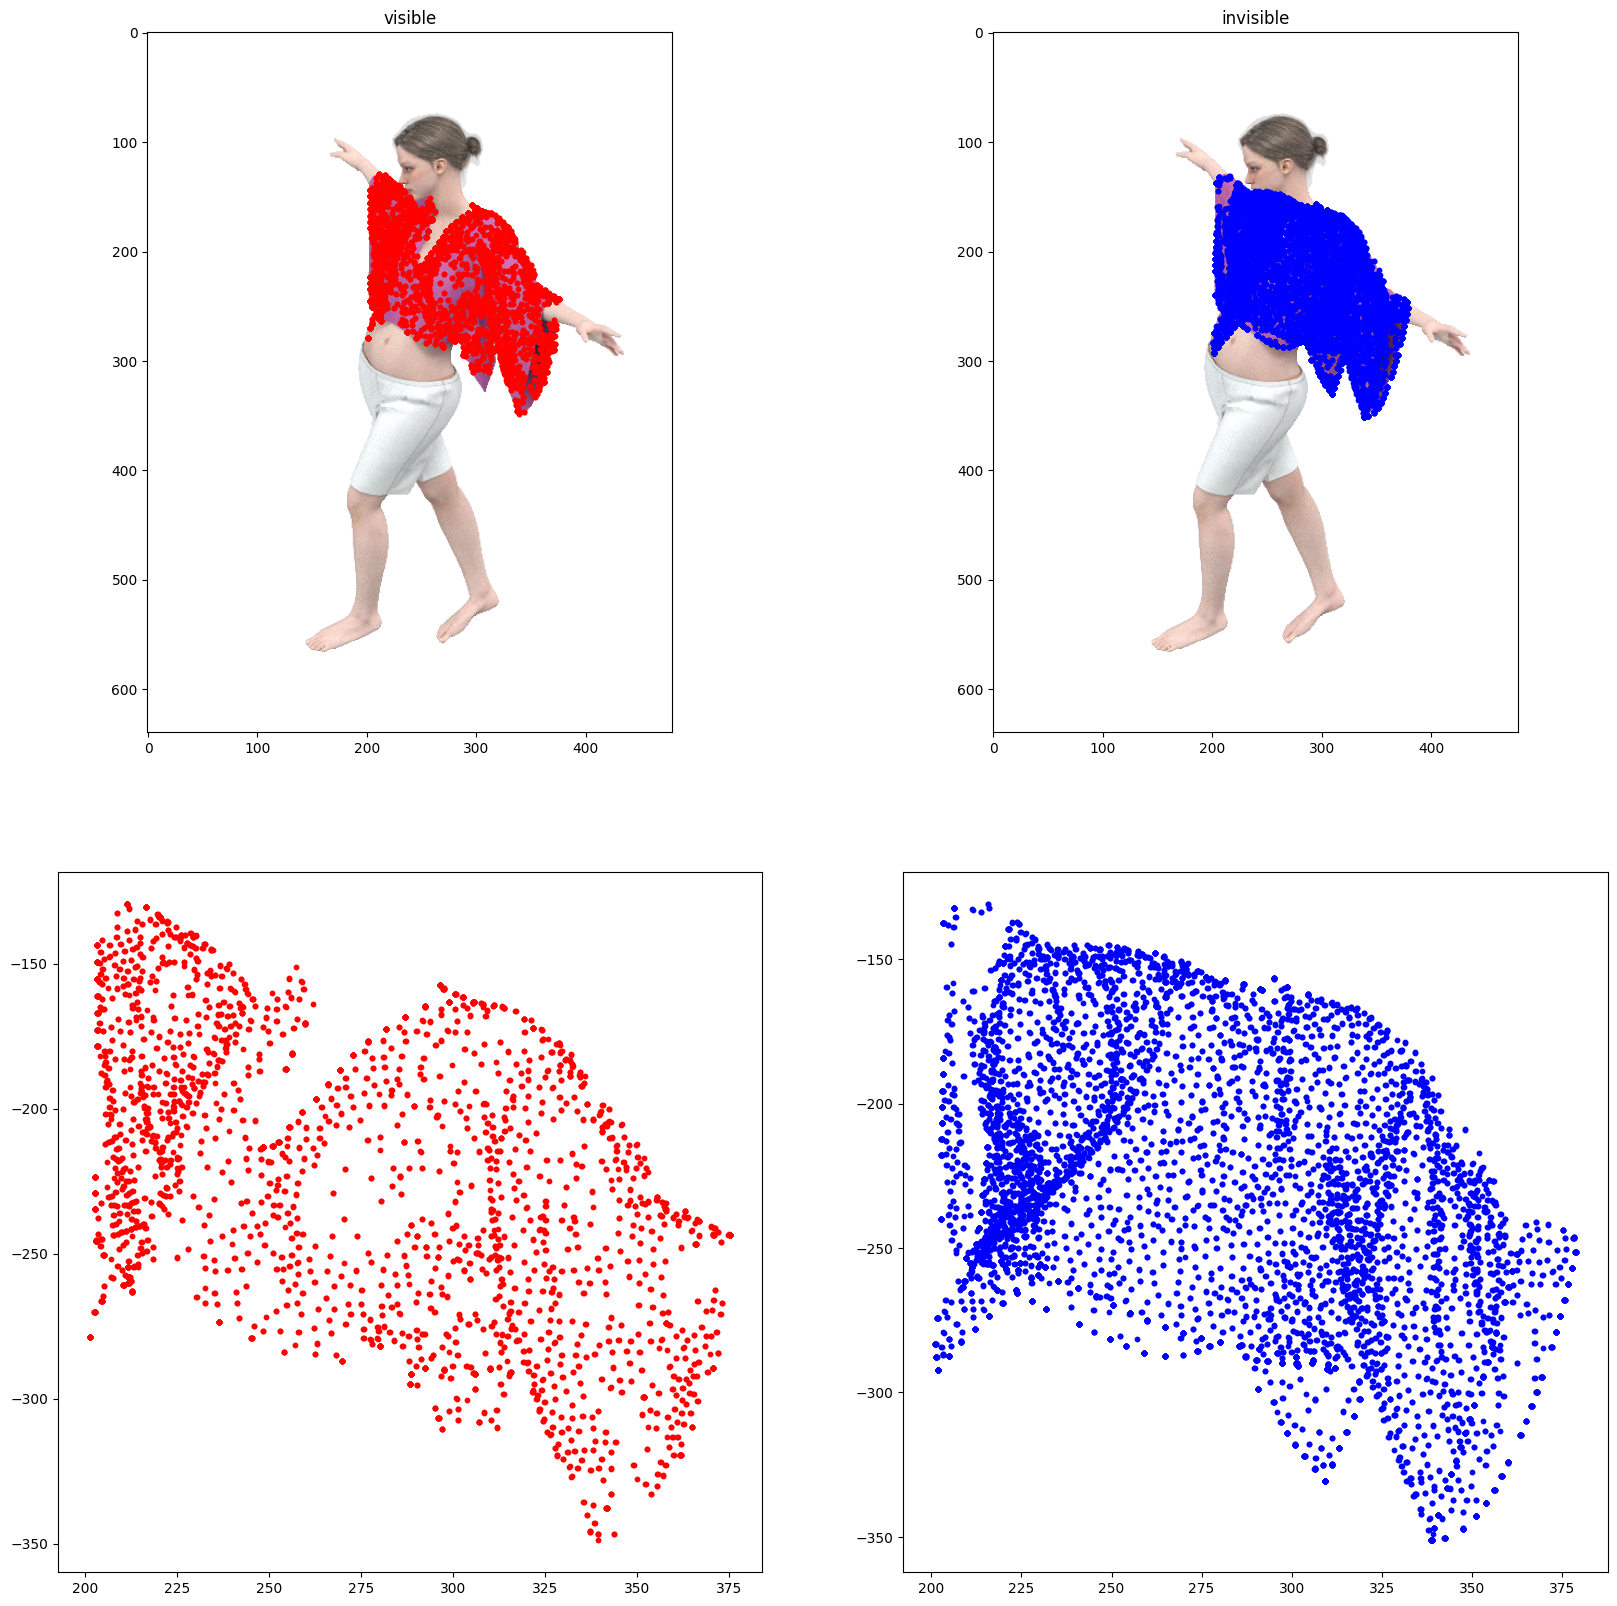

(6006,) (6006, 2)


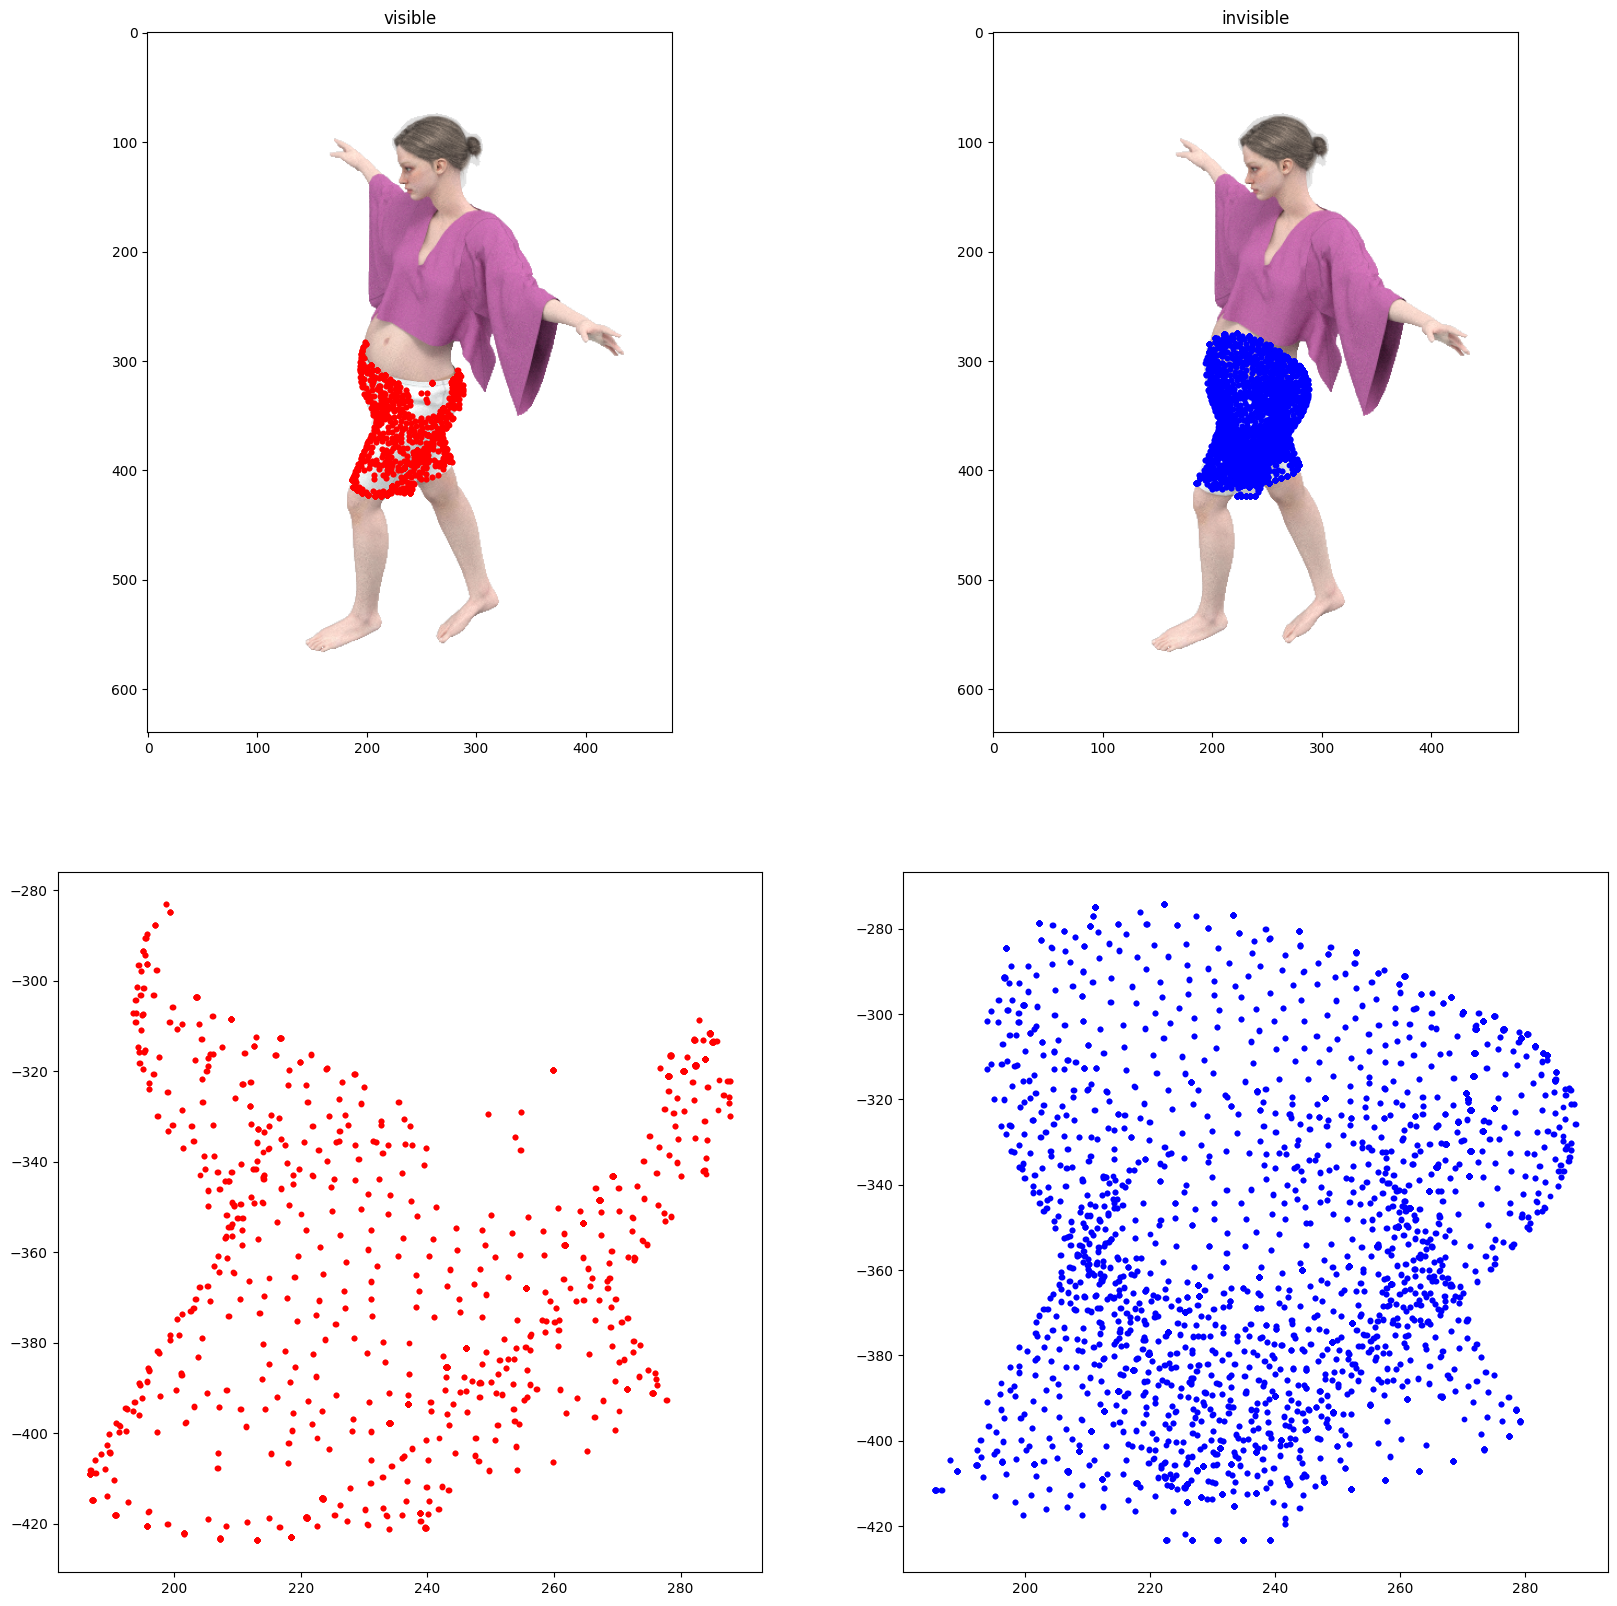

(12673,) (12673, 2)


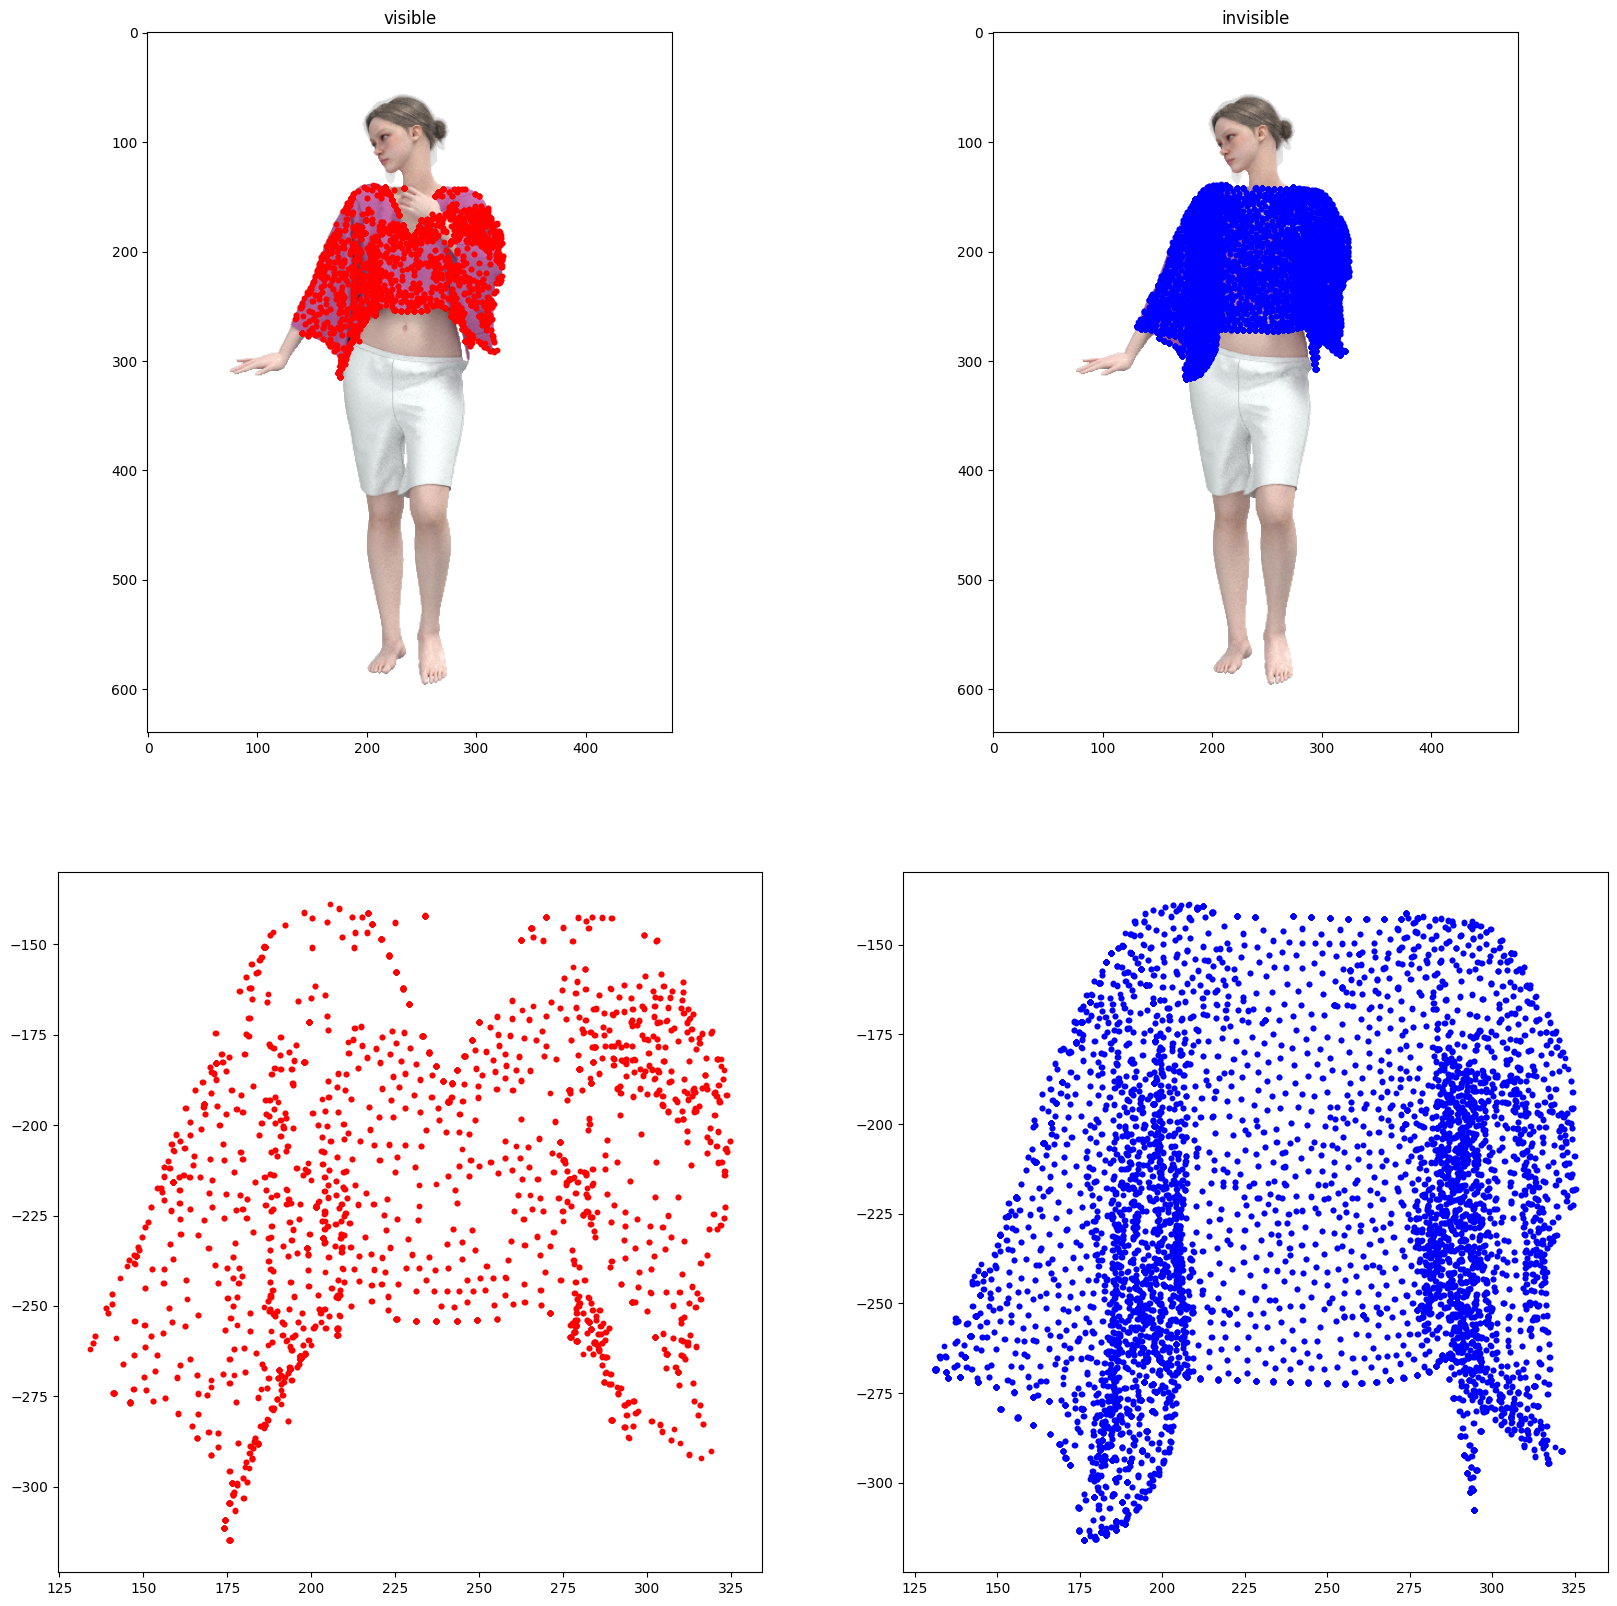

(5096,) (5096, 2)


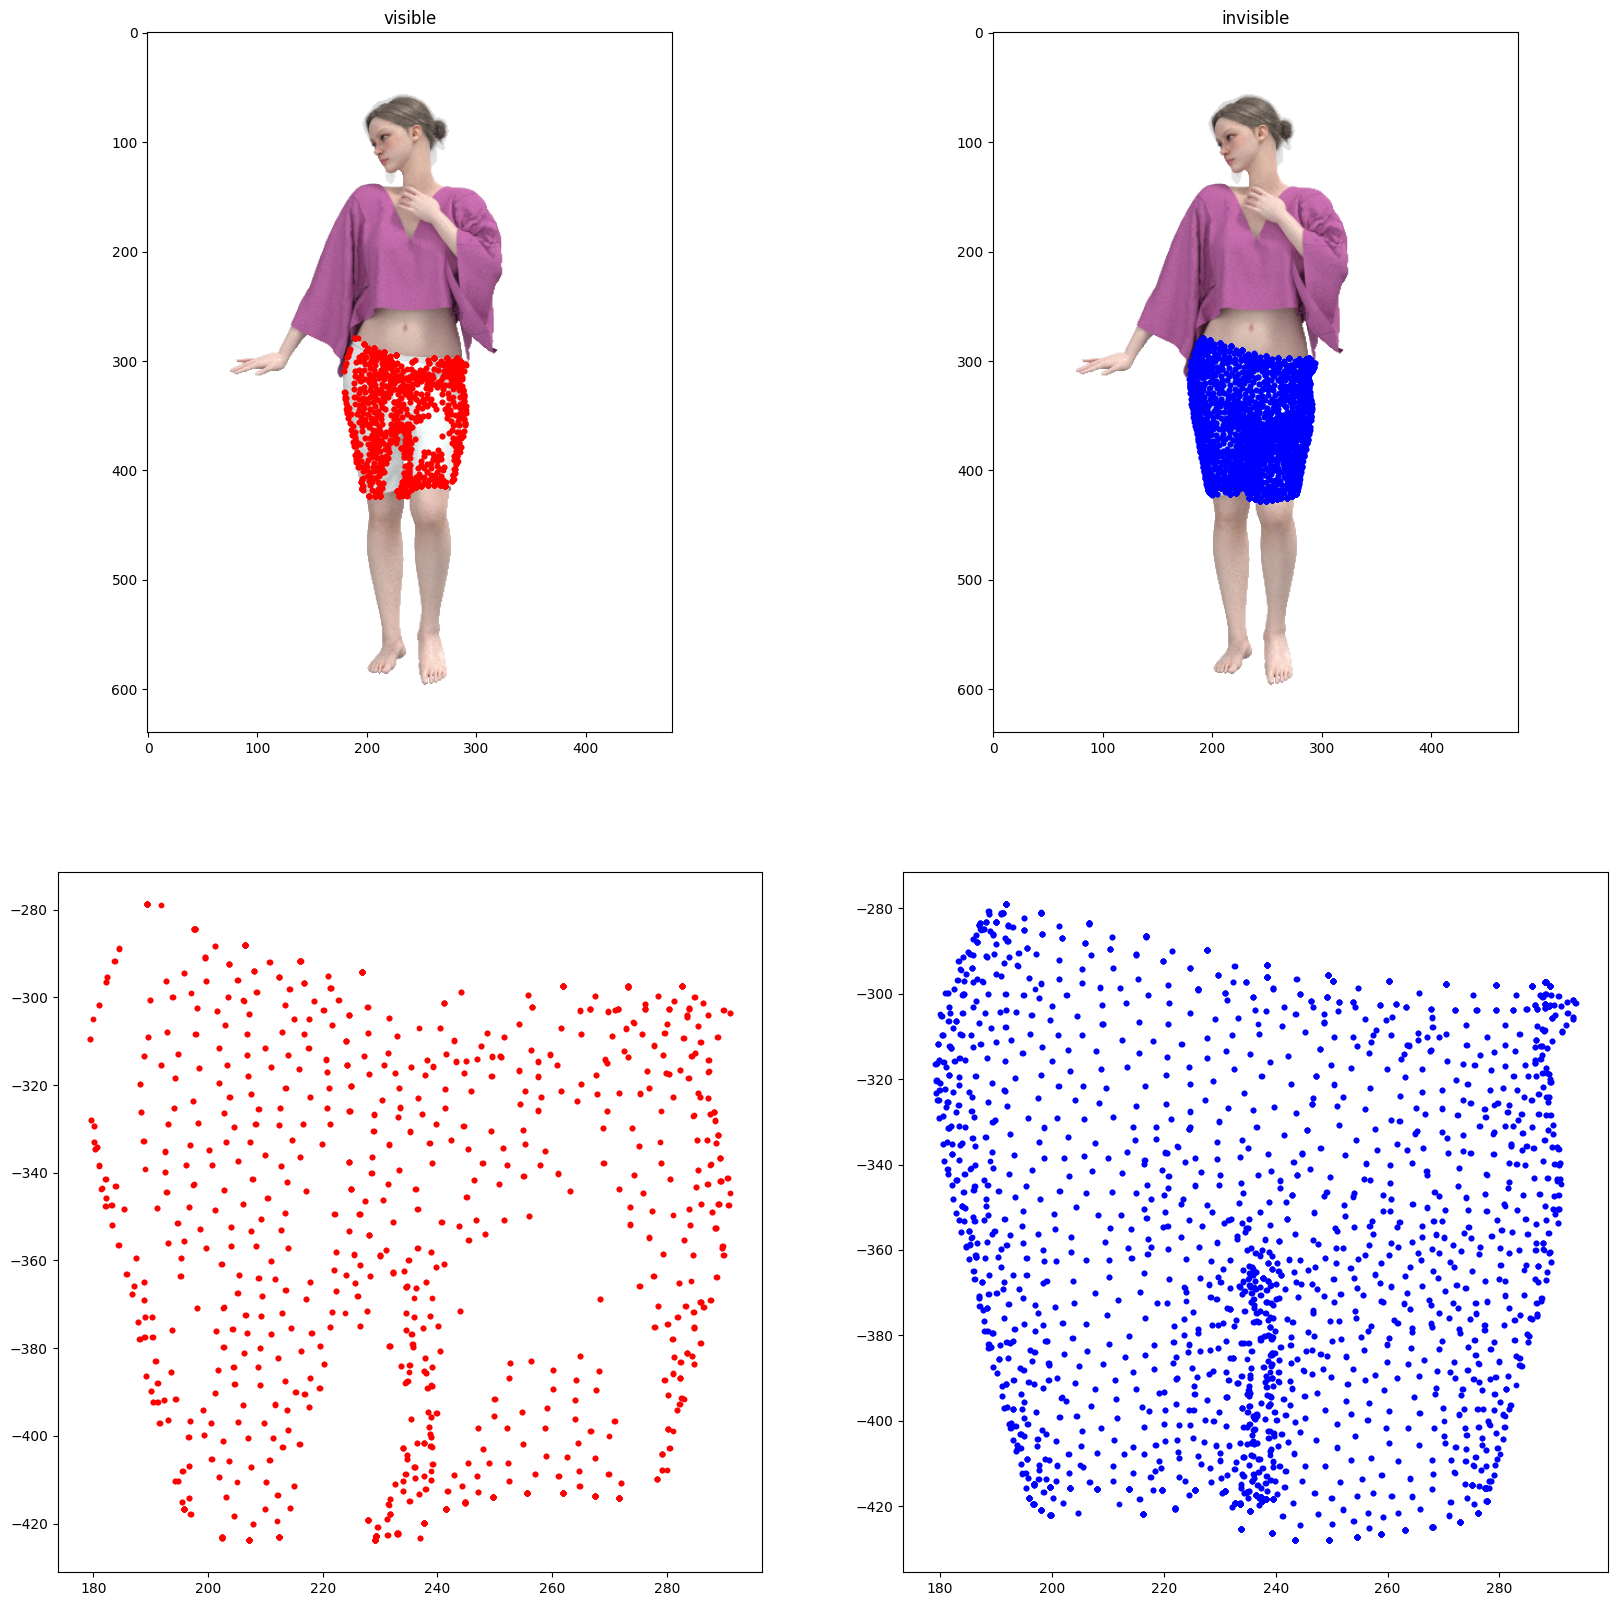

(12673,) (12673, 2)


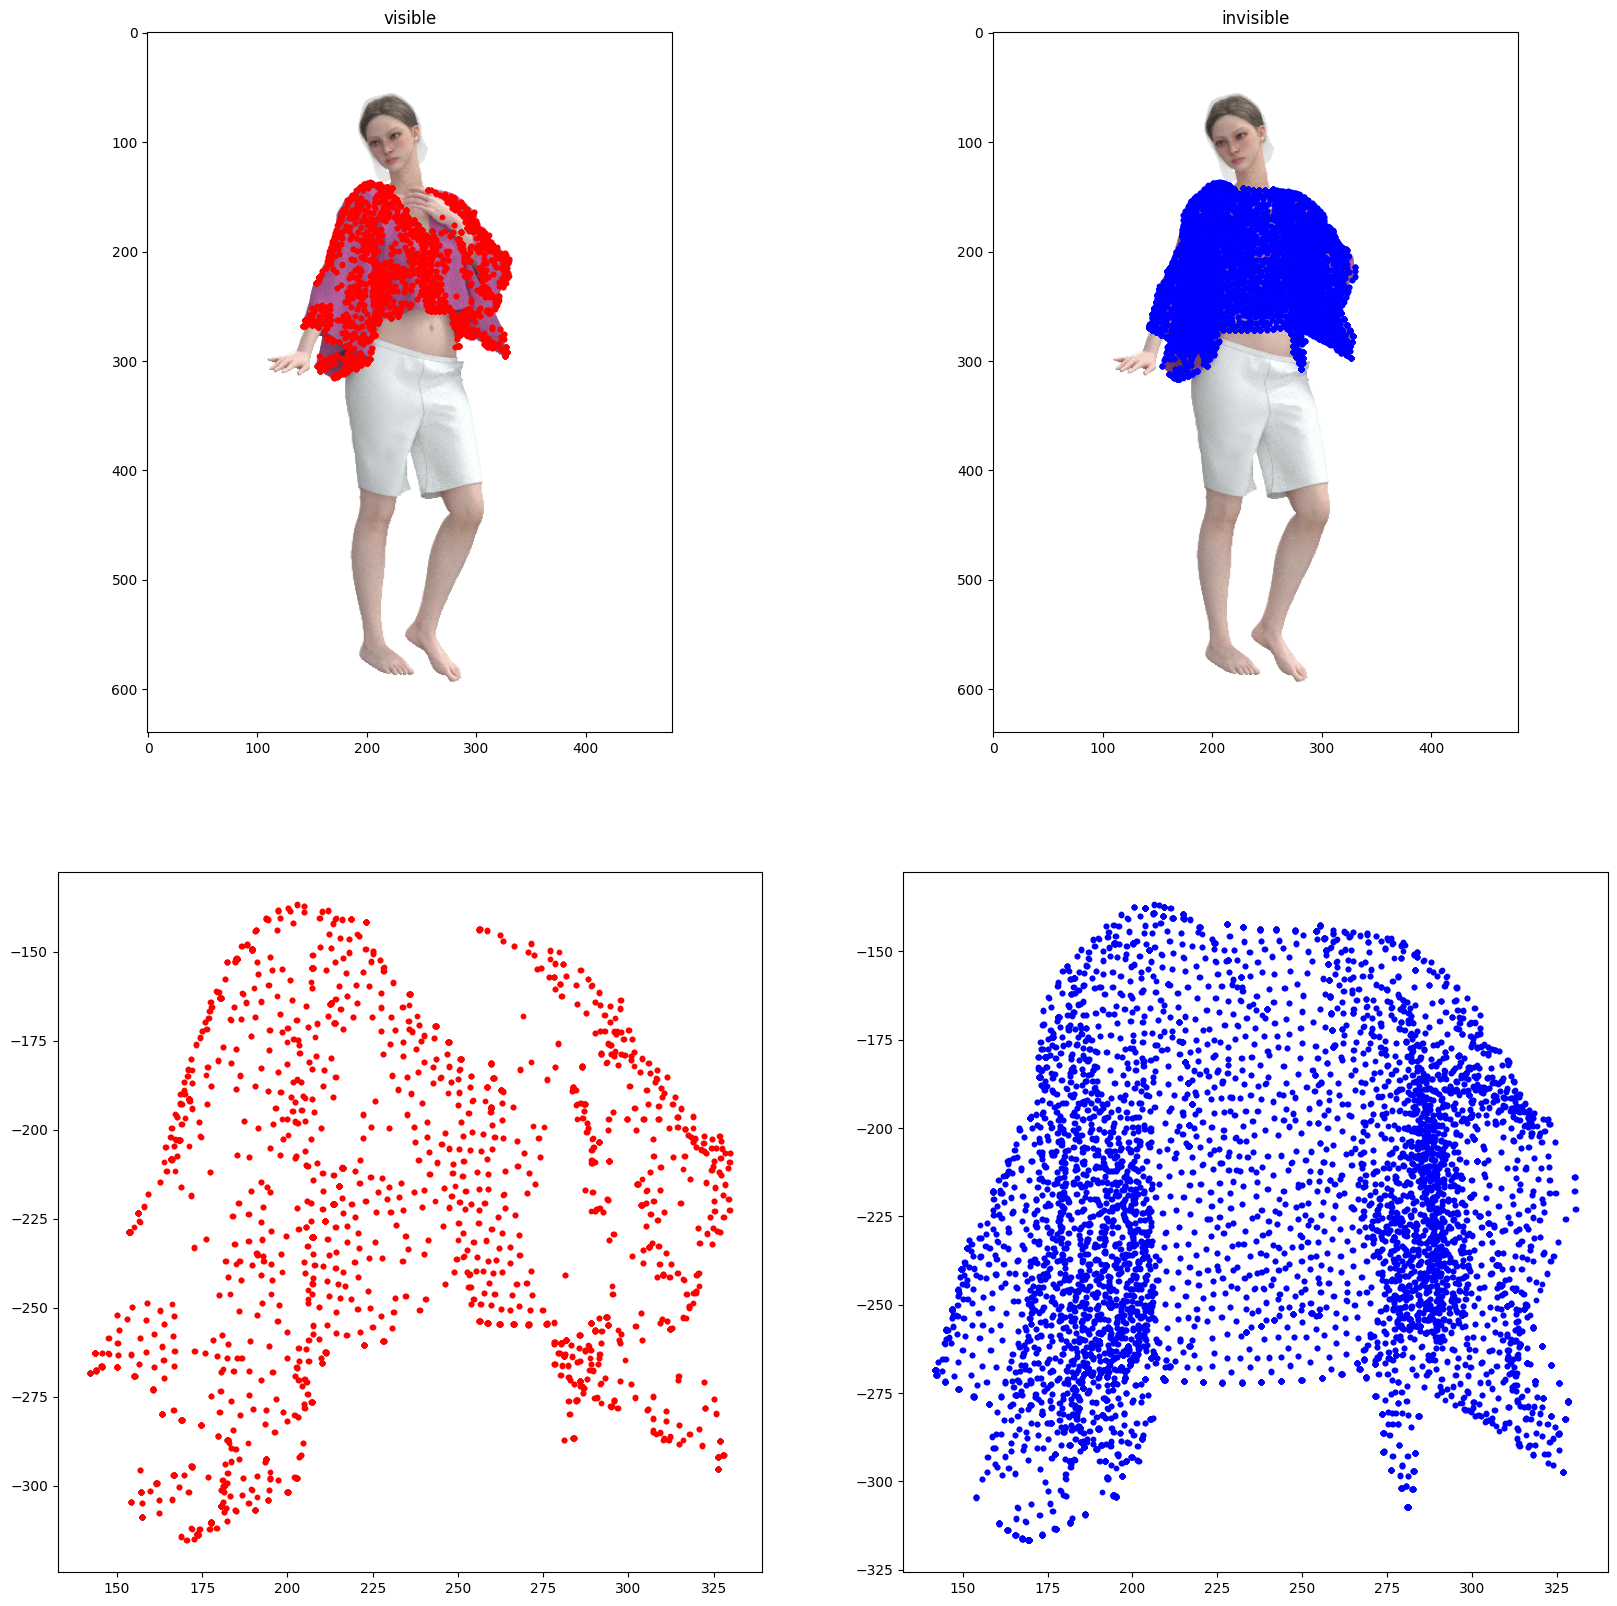

(5096,) (5096, 2)


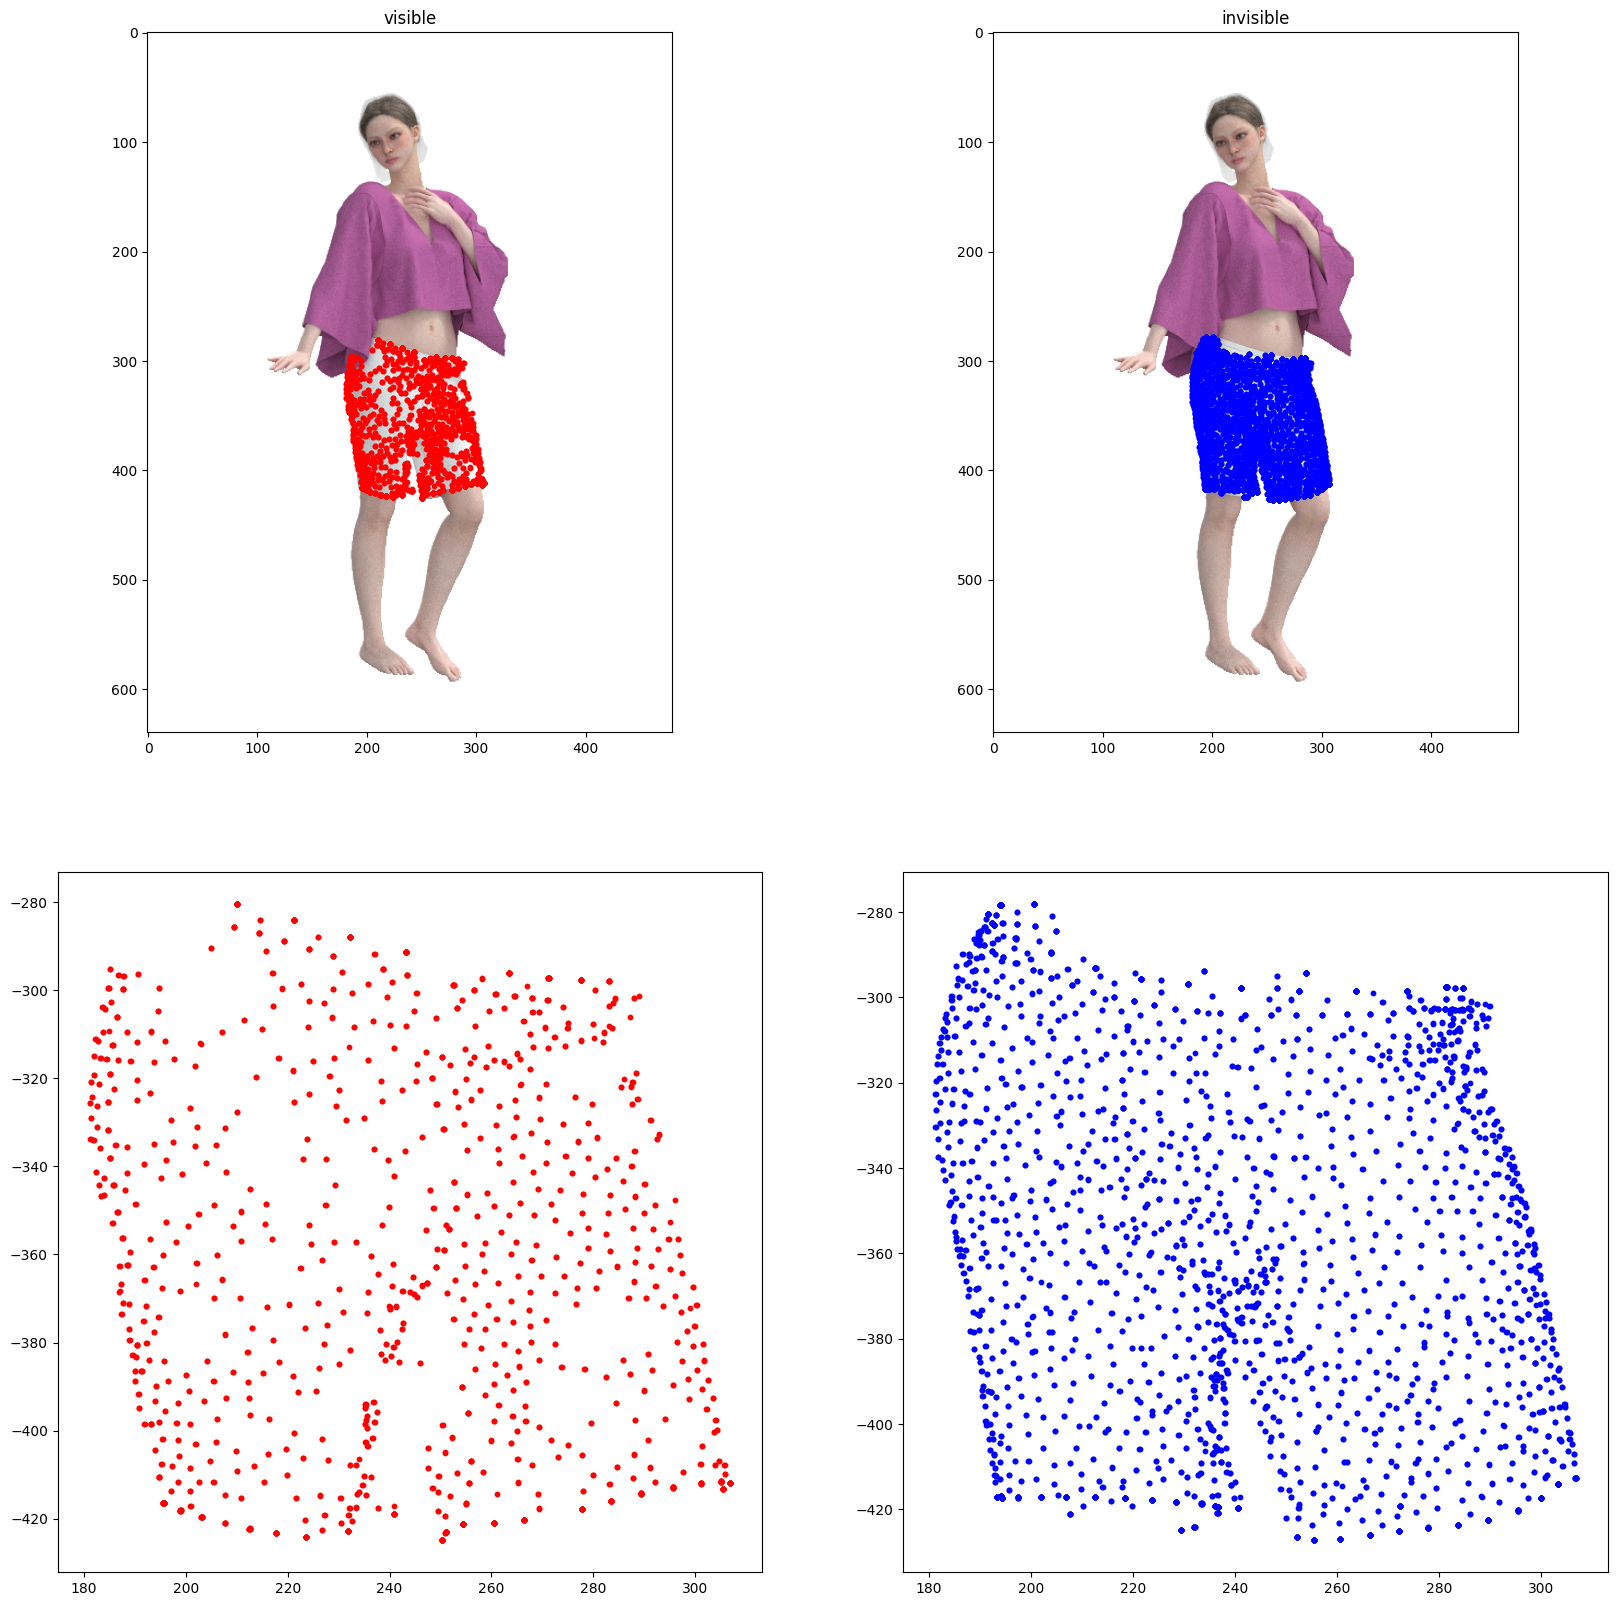

(12673,) (12673, 2)


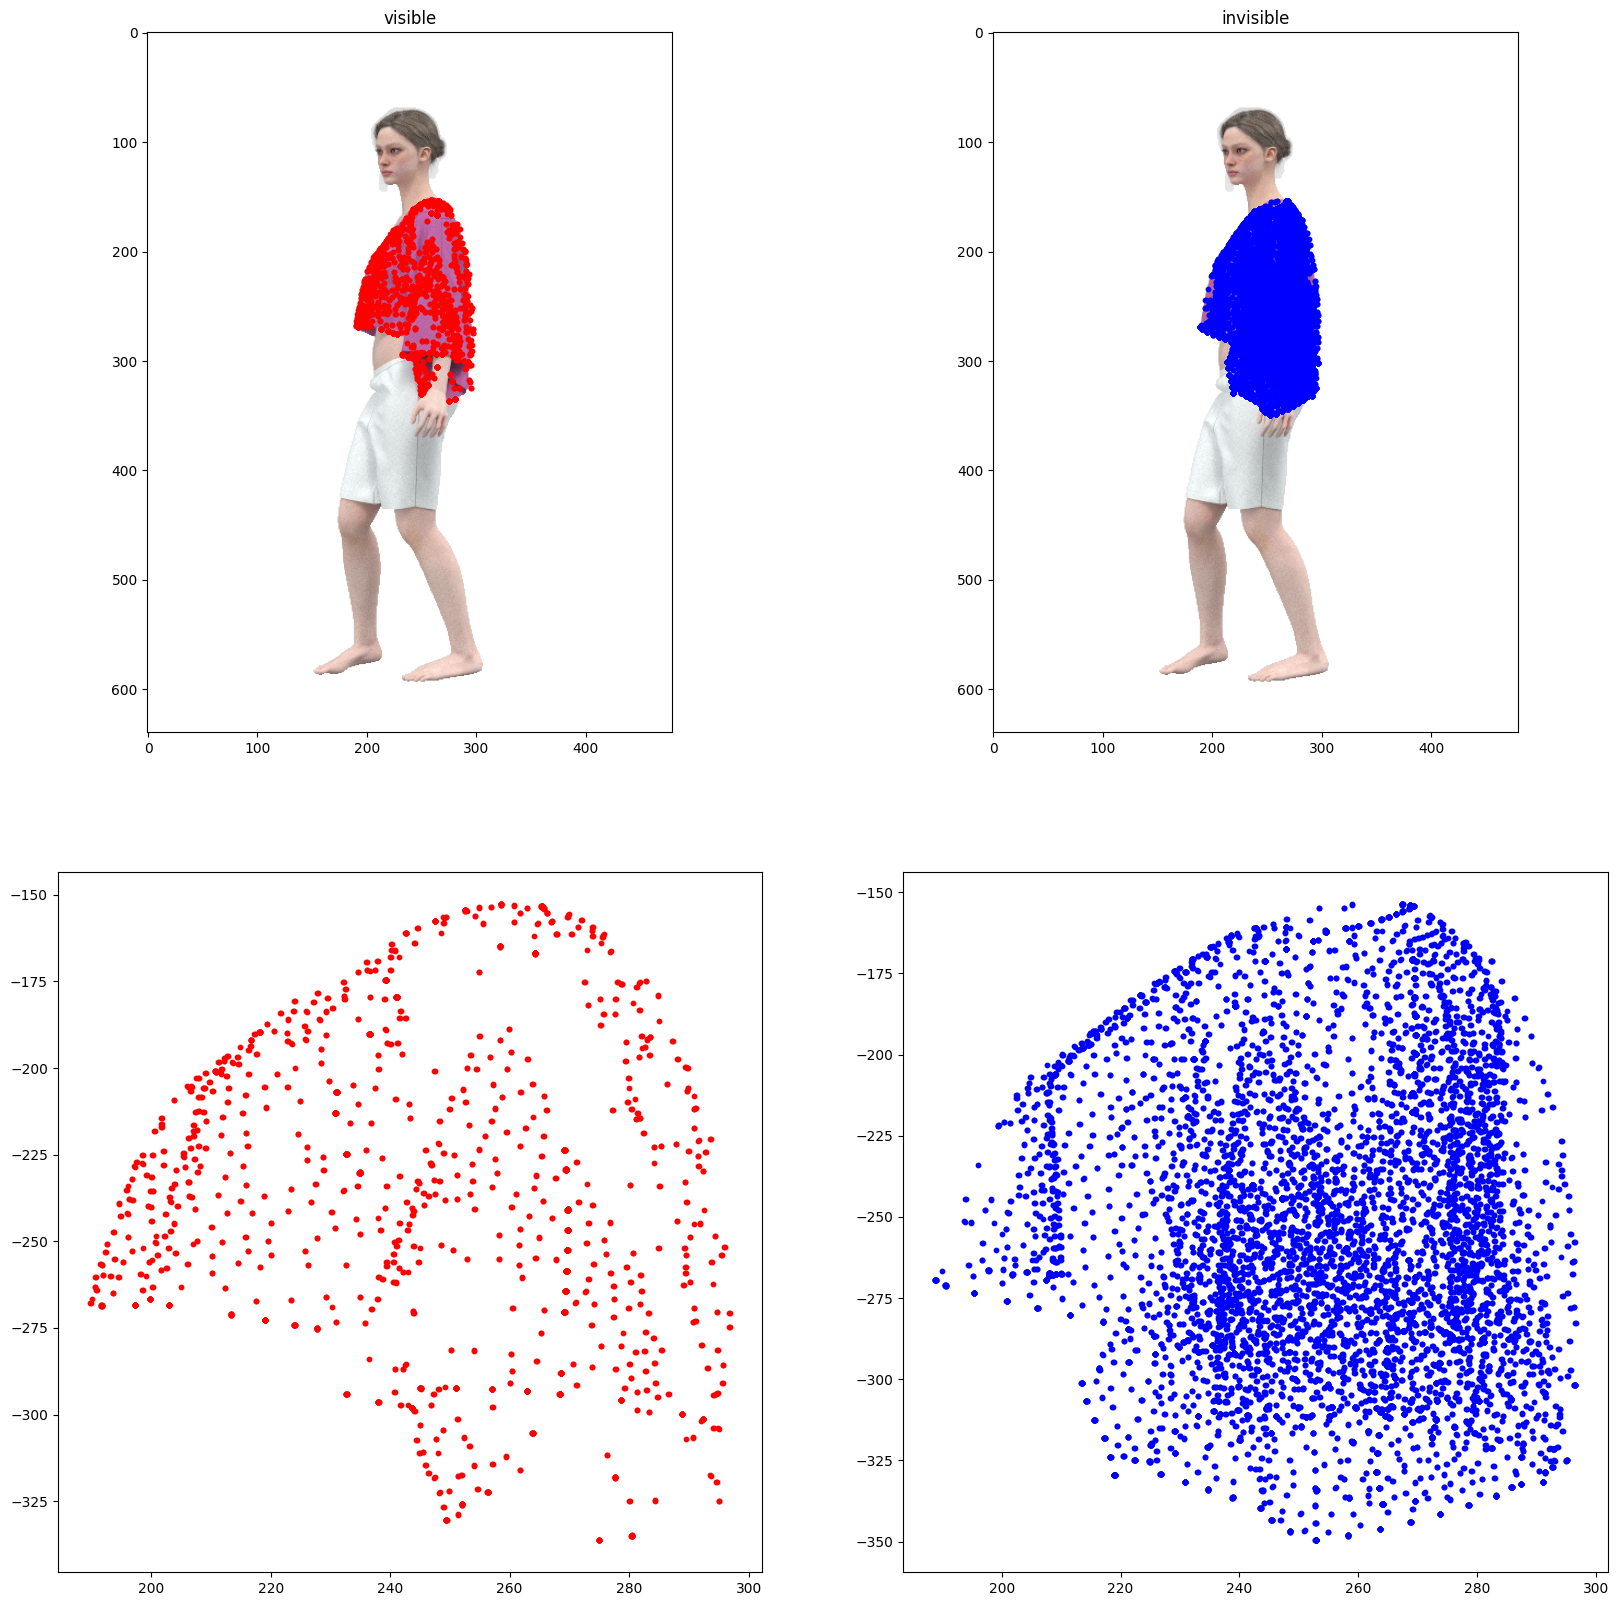

(5096,) (5096, 2)


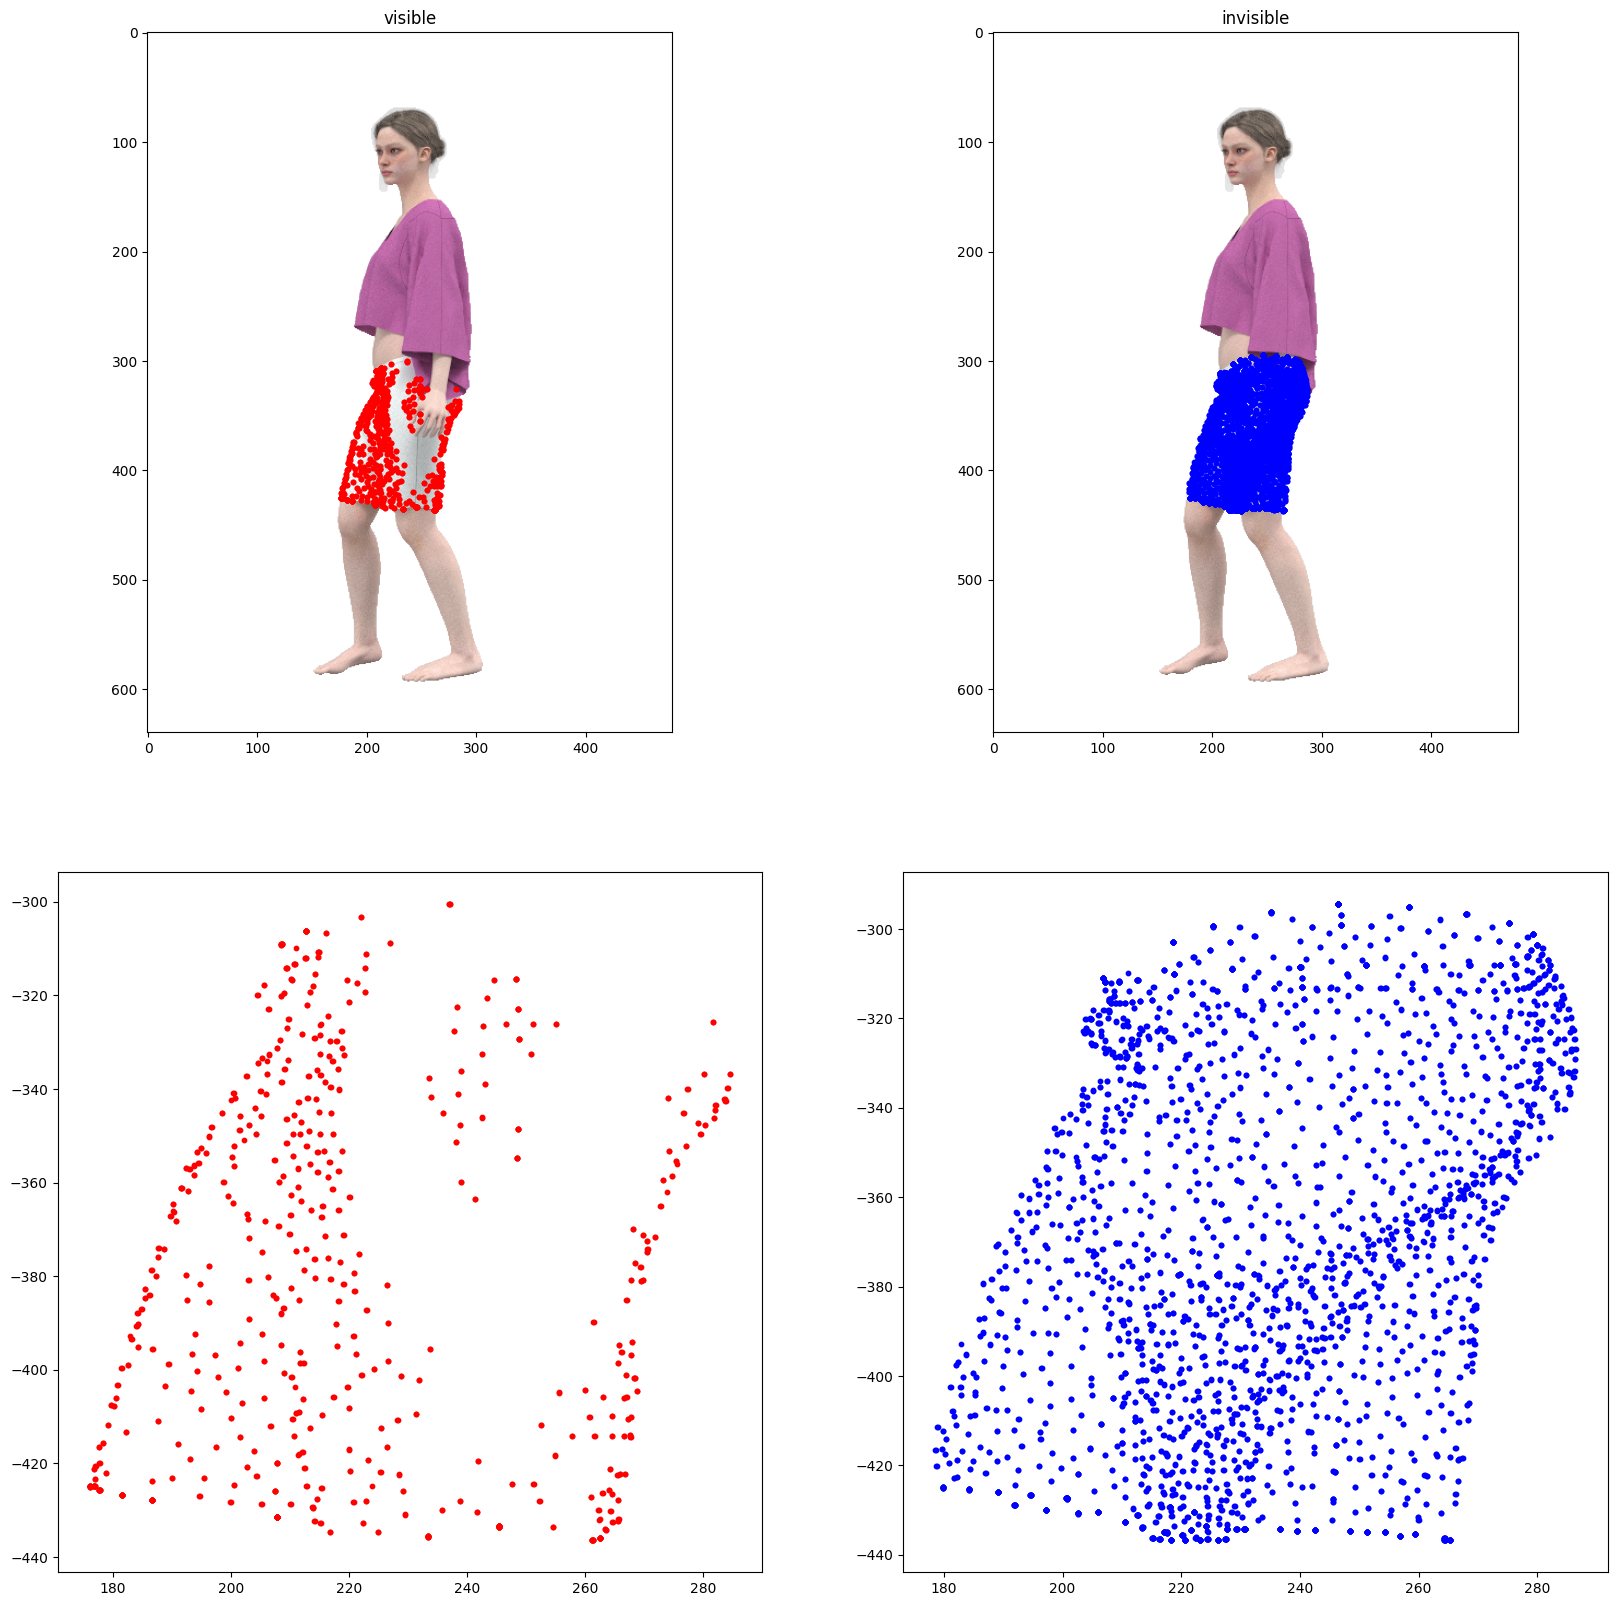

(12939,) (12939, 2)


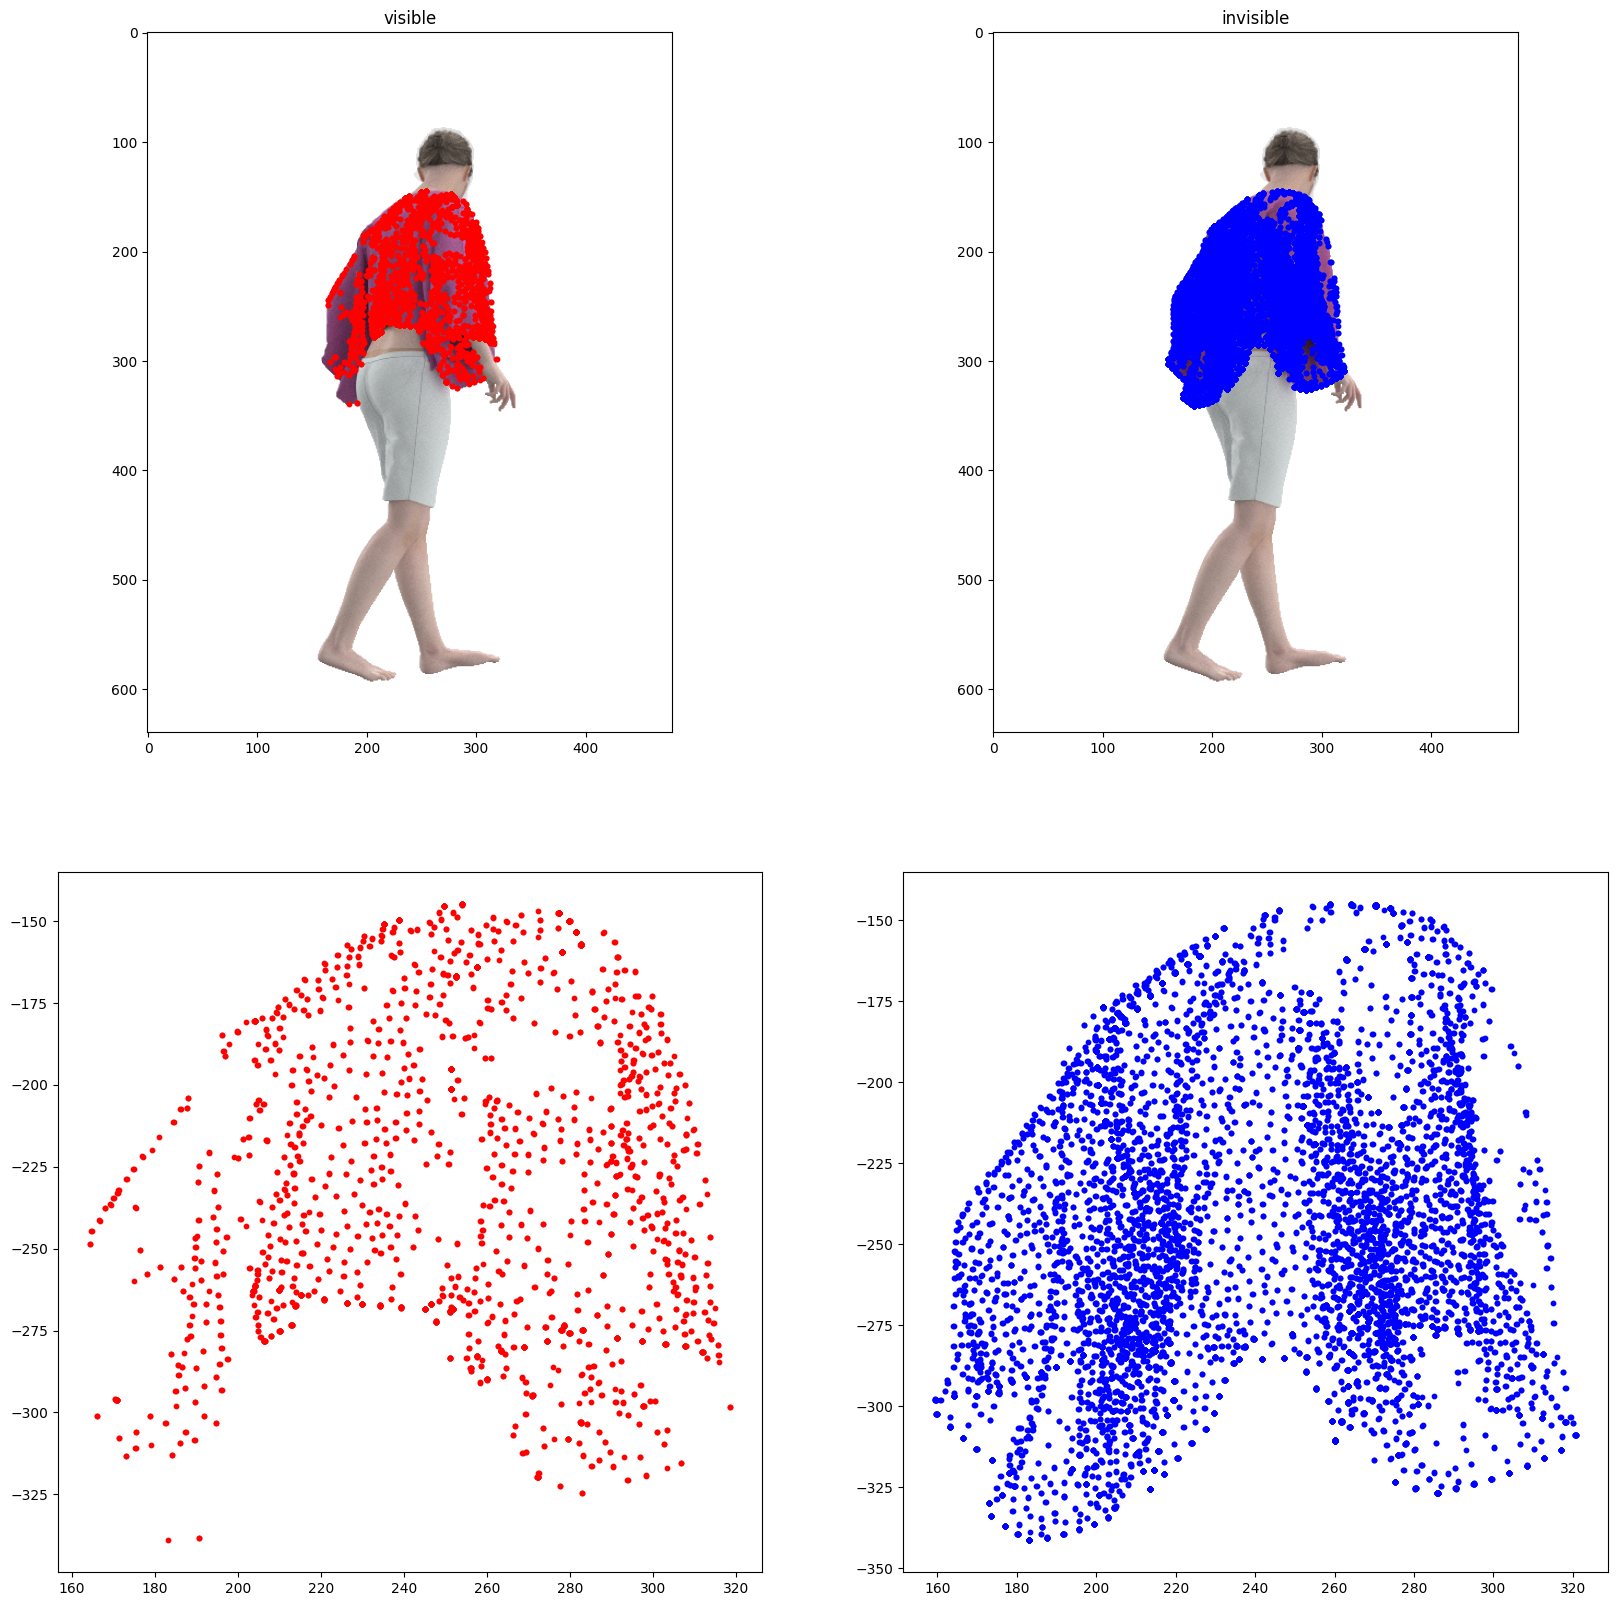

(5096,) (5096, 2)


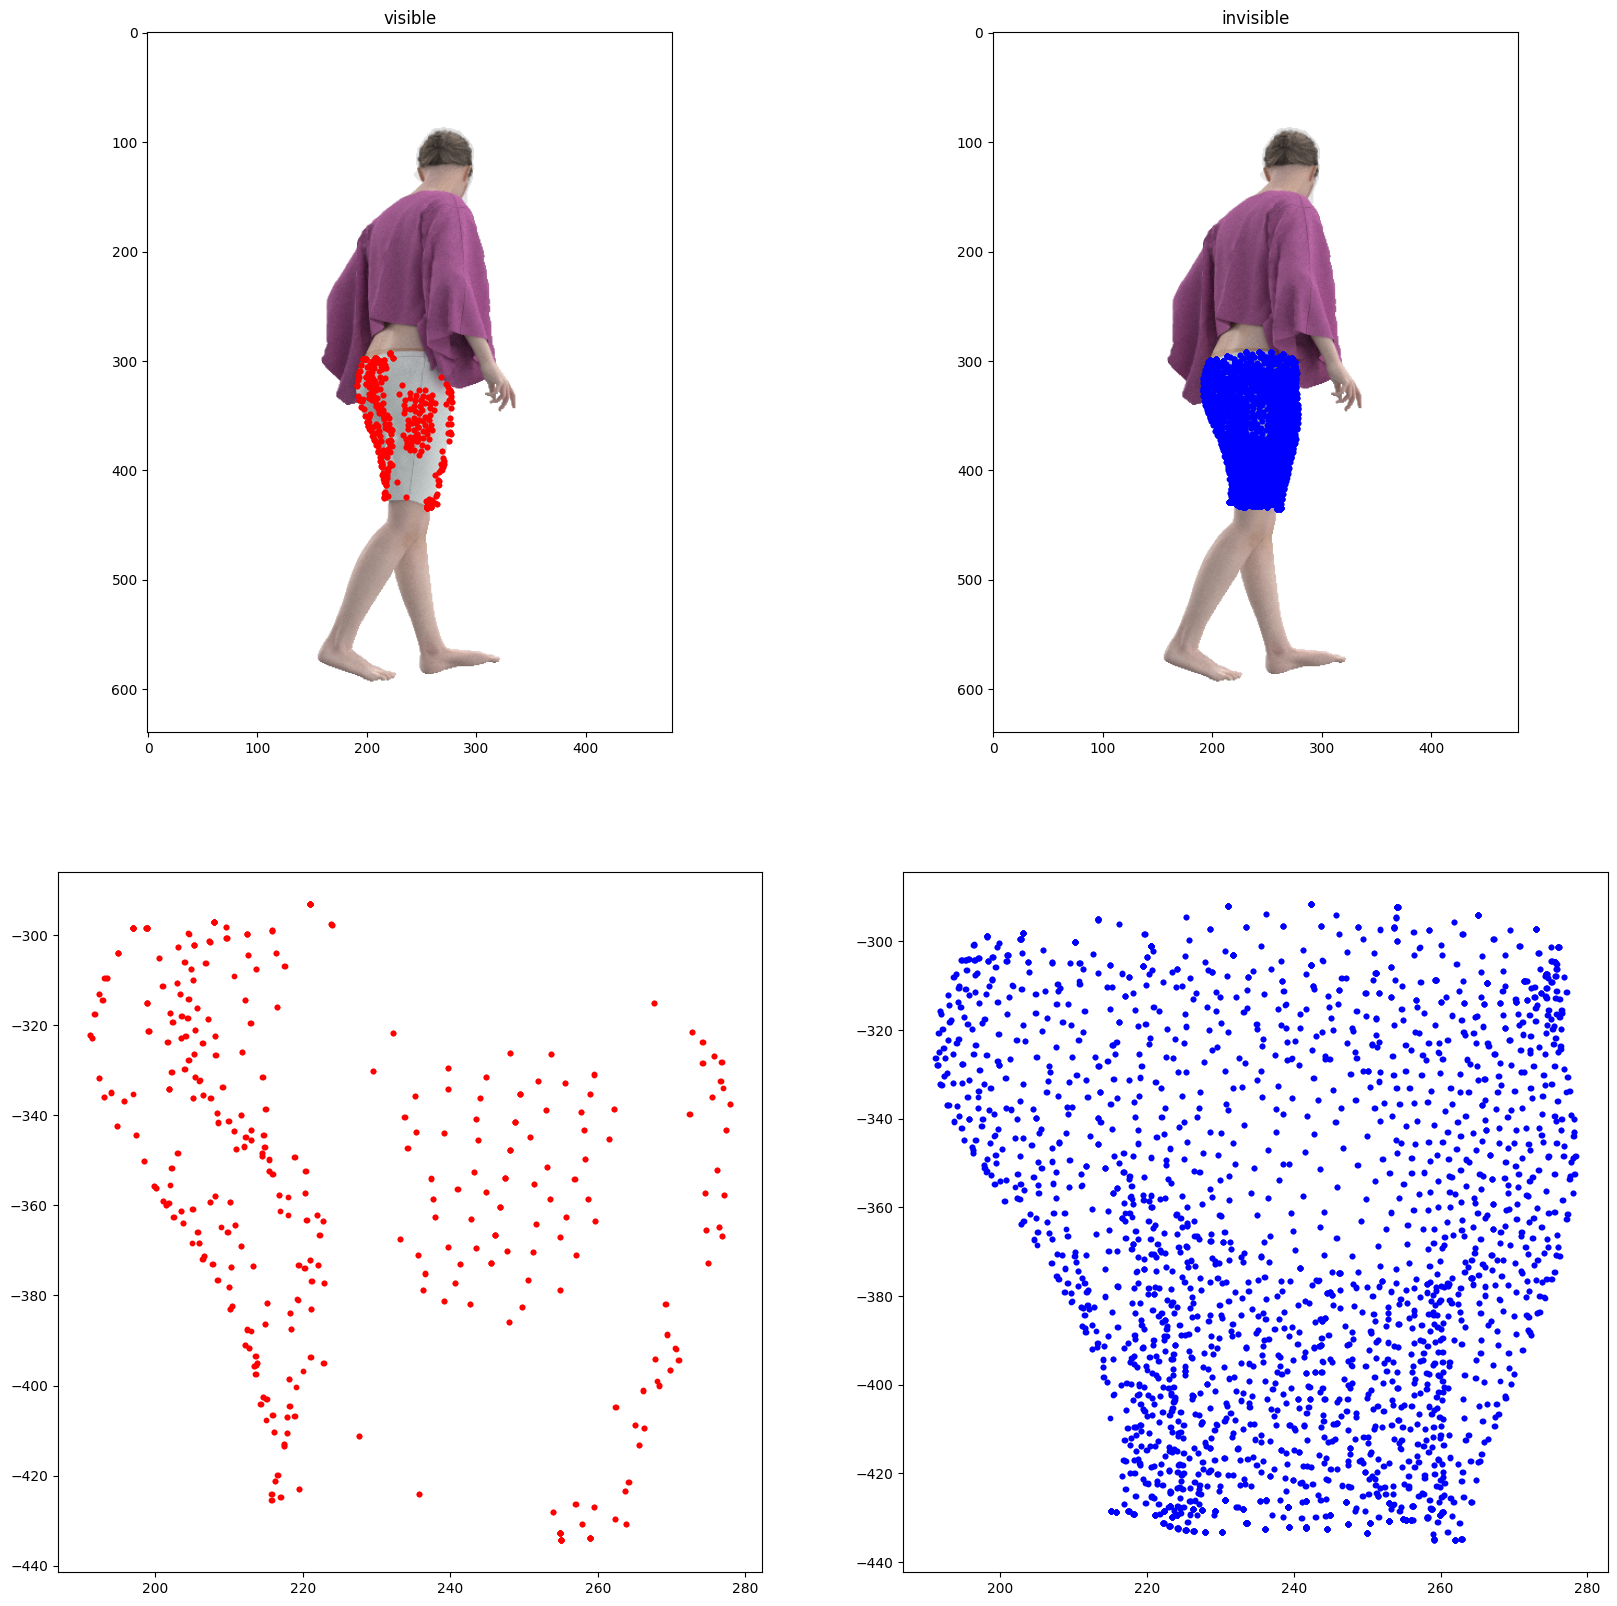

(11791,) (11791, 2)


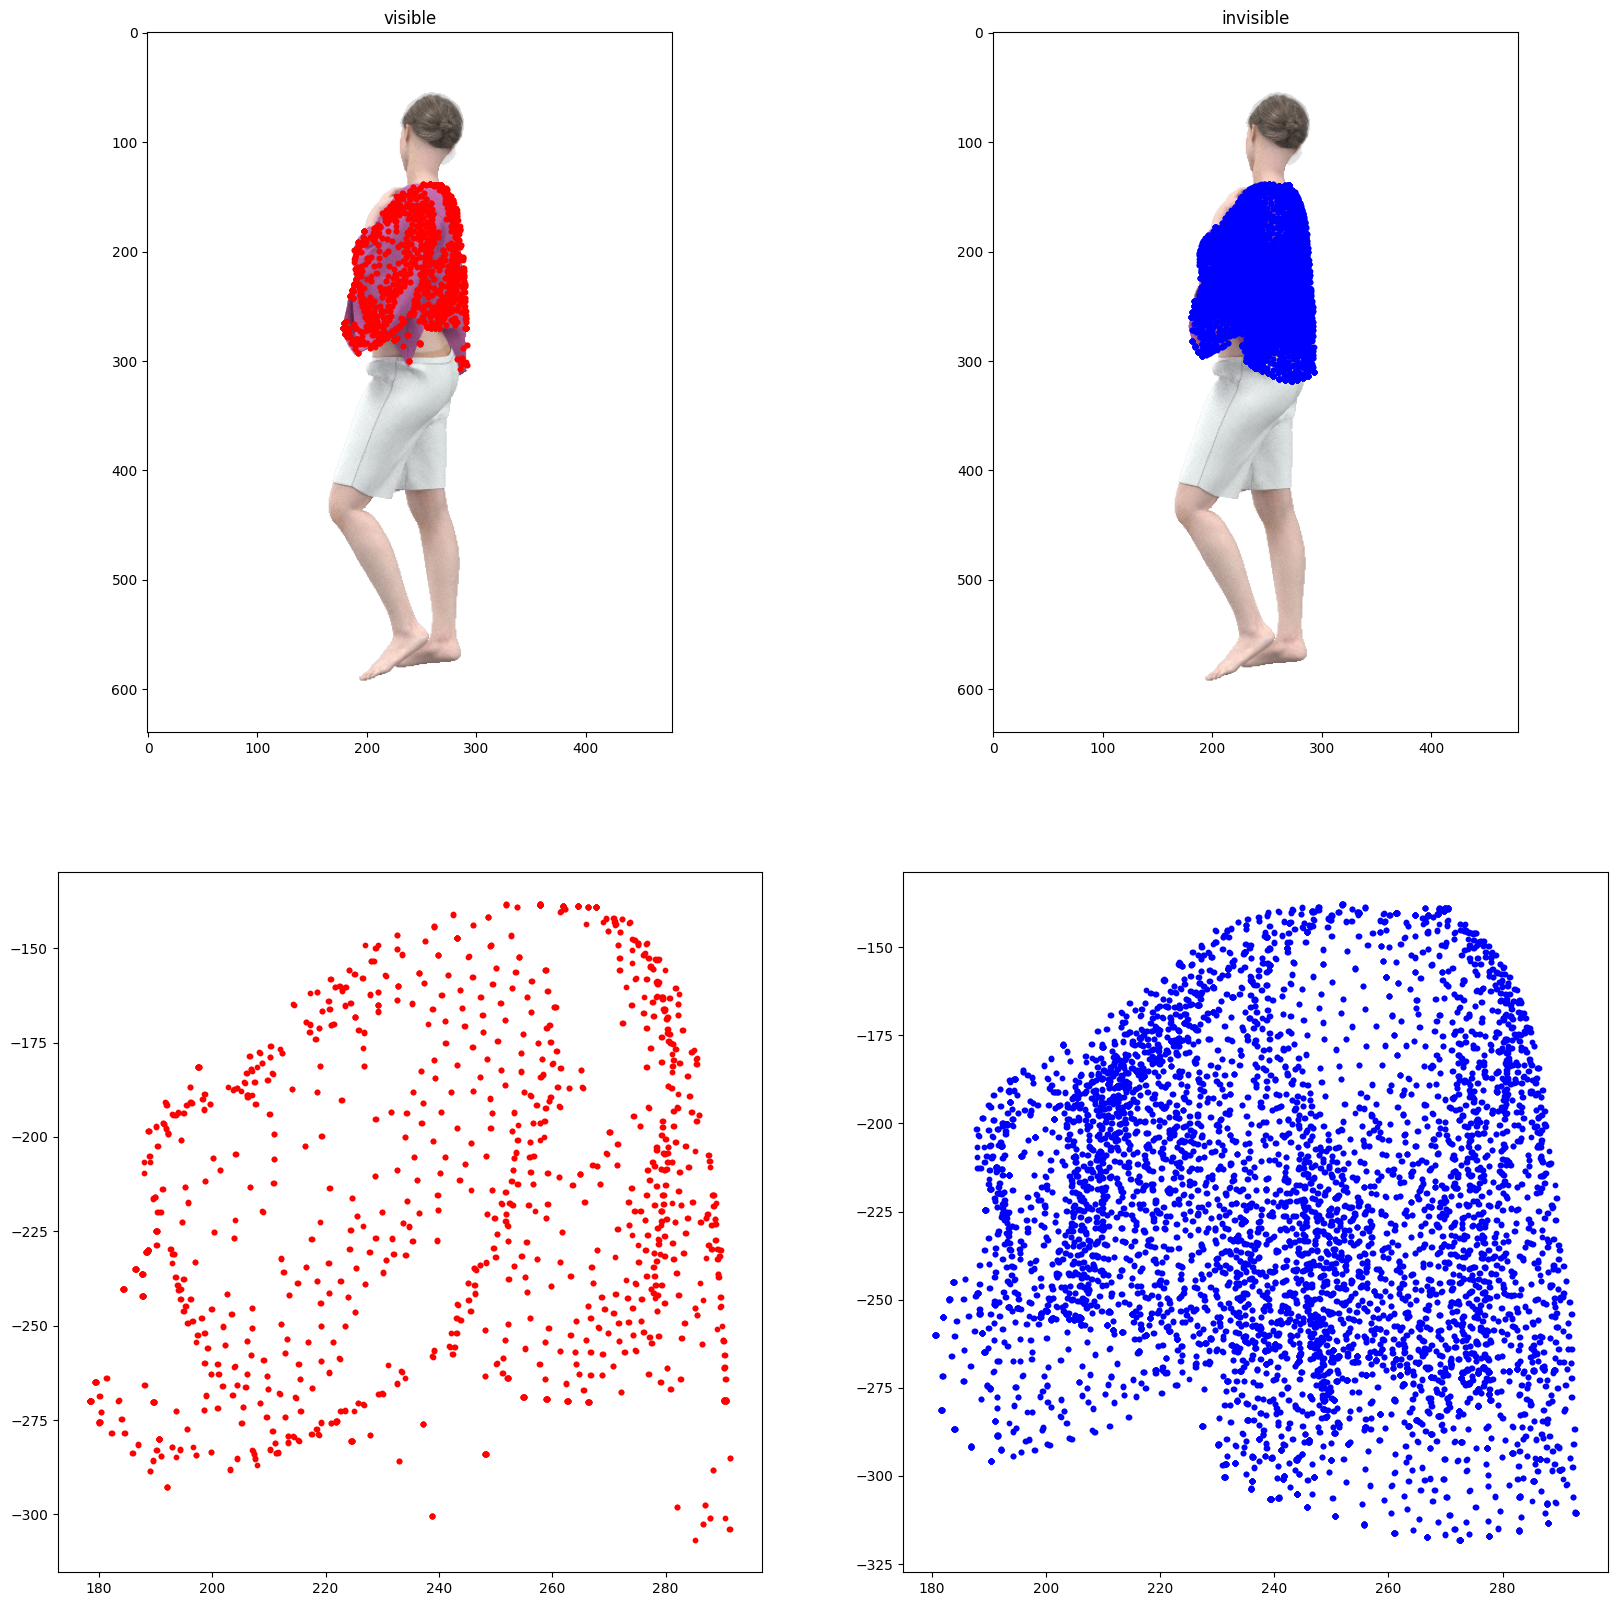

(5600,) (5600, 2)


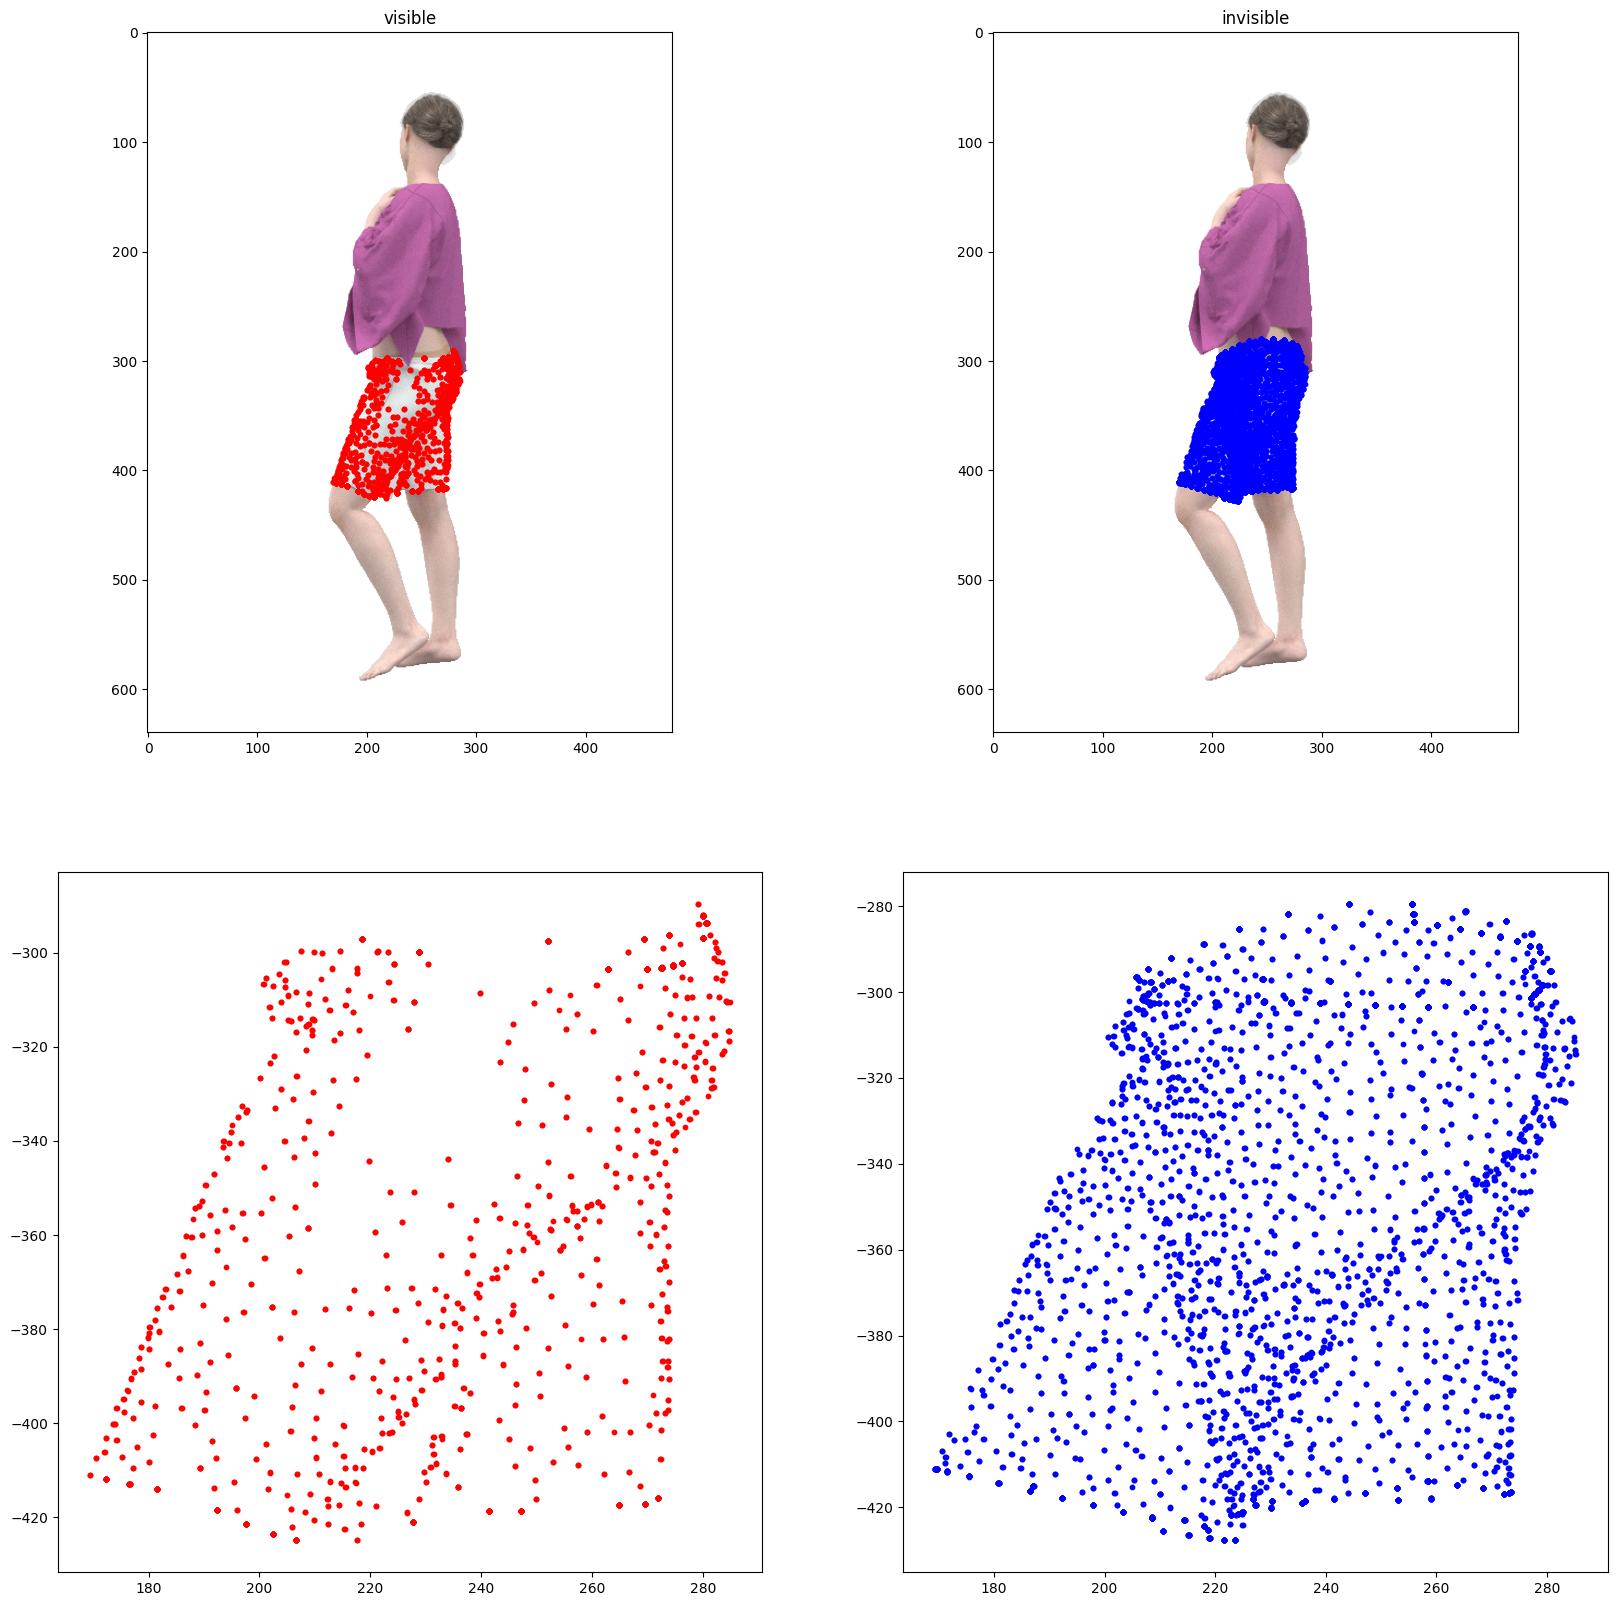

(11791,) (11791, 2)


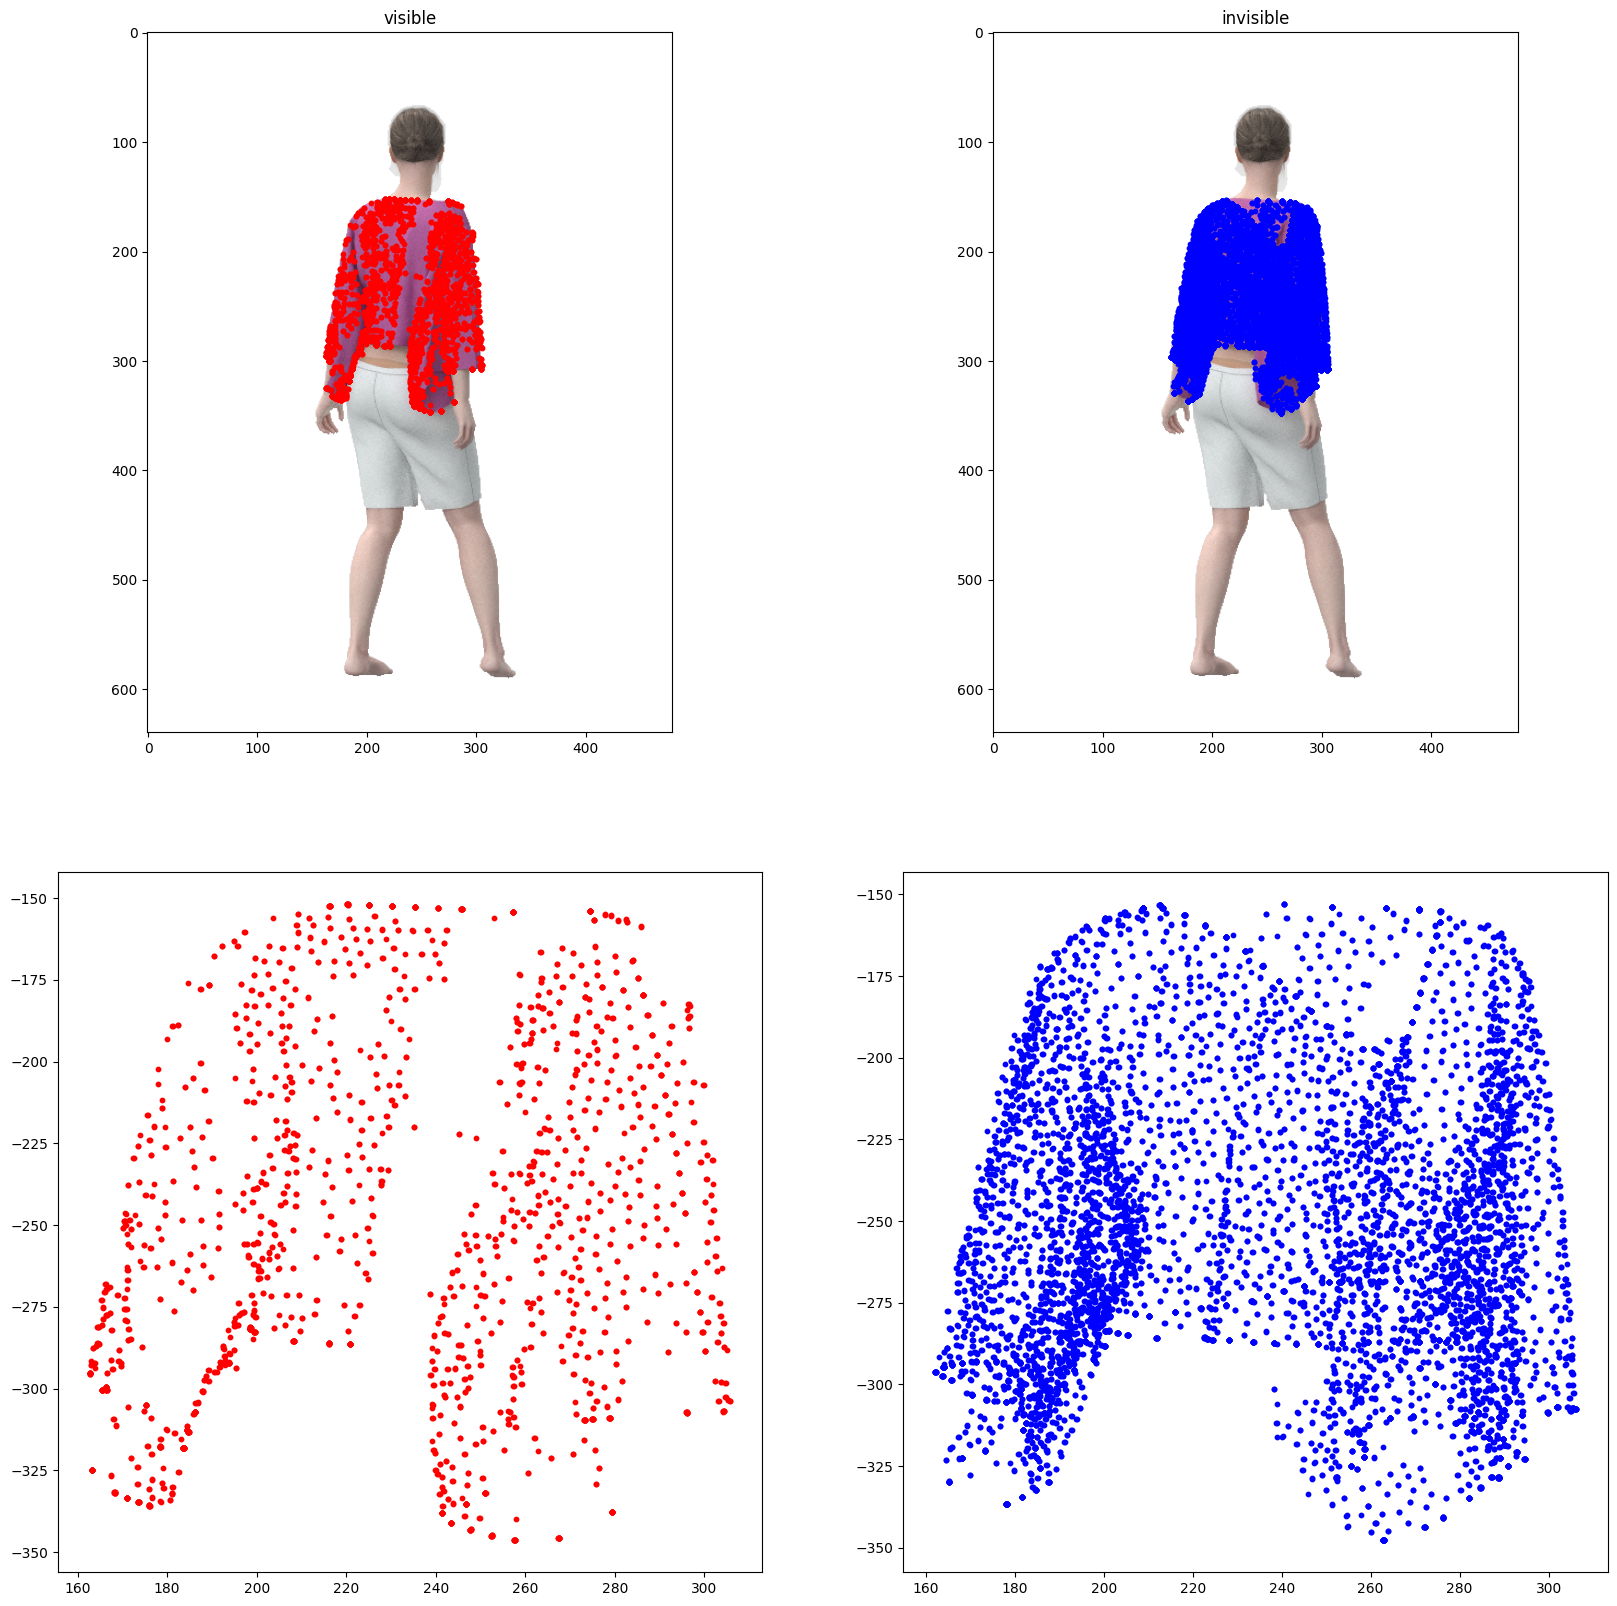

(6006,) (6006, 2)


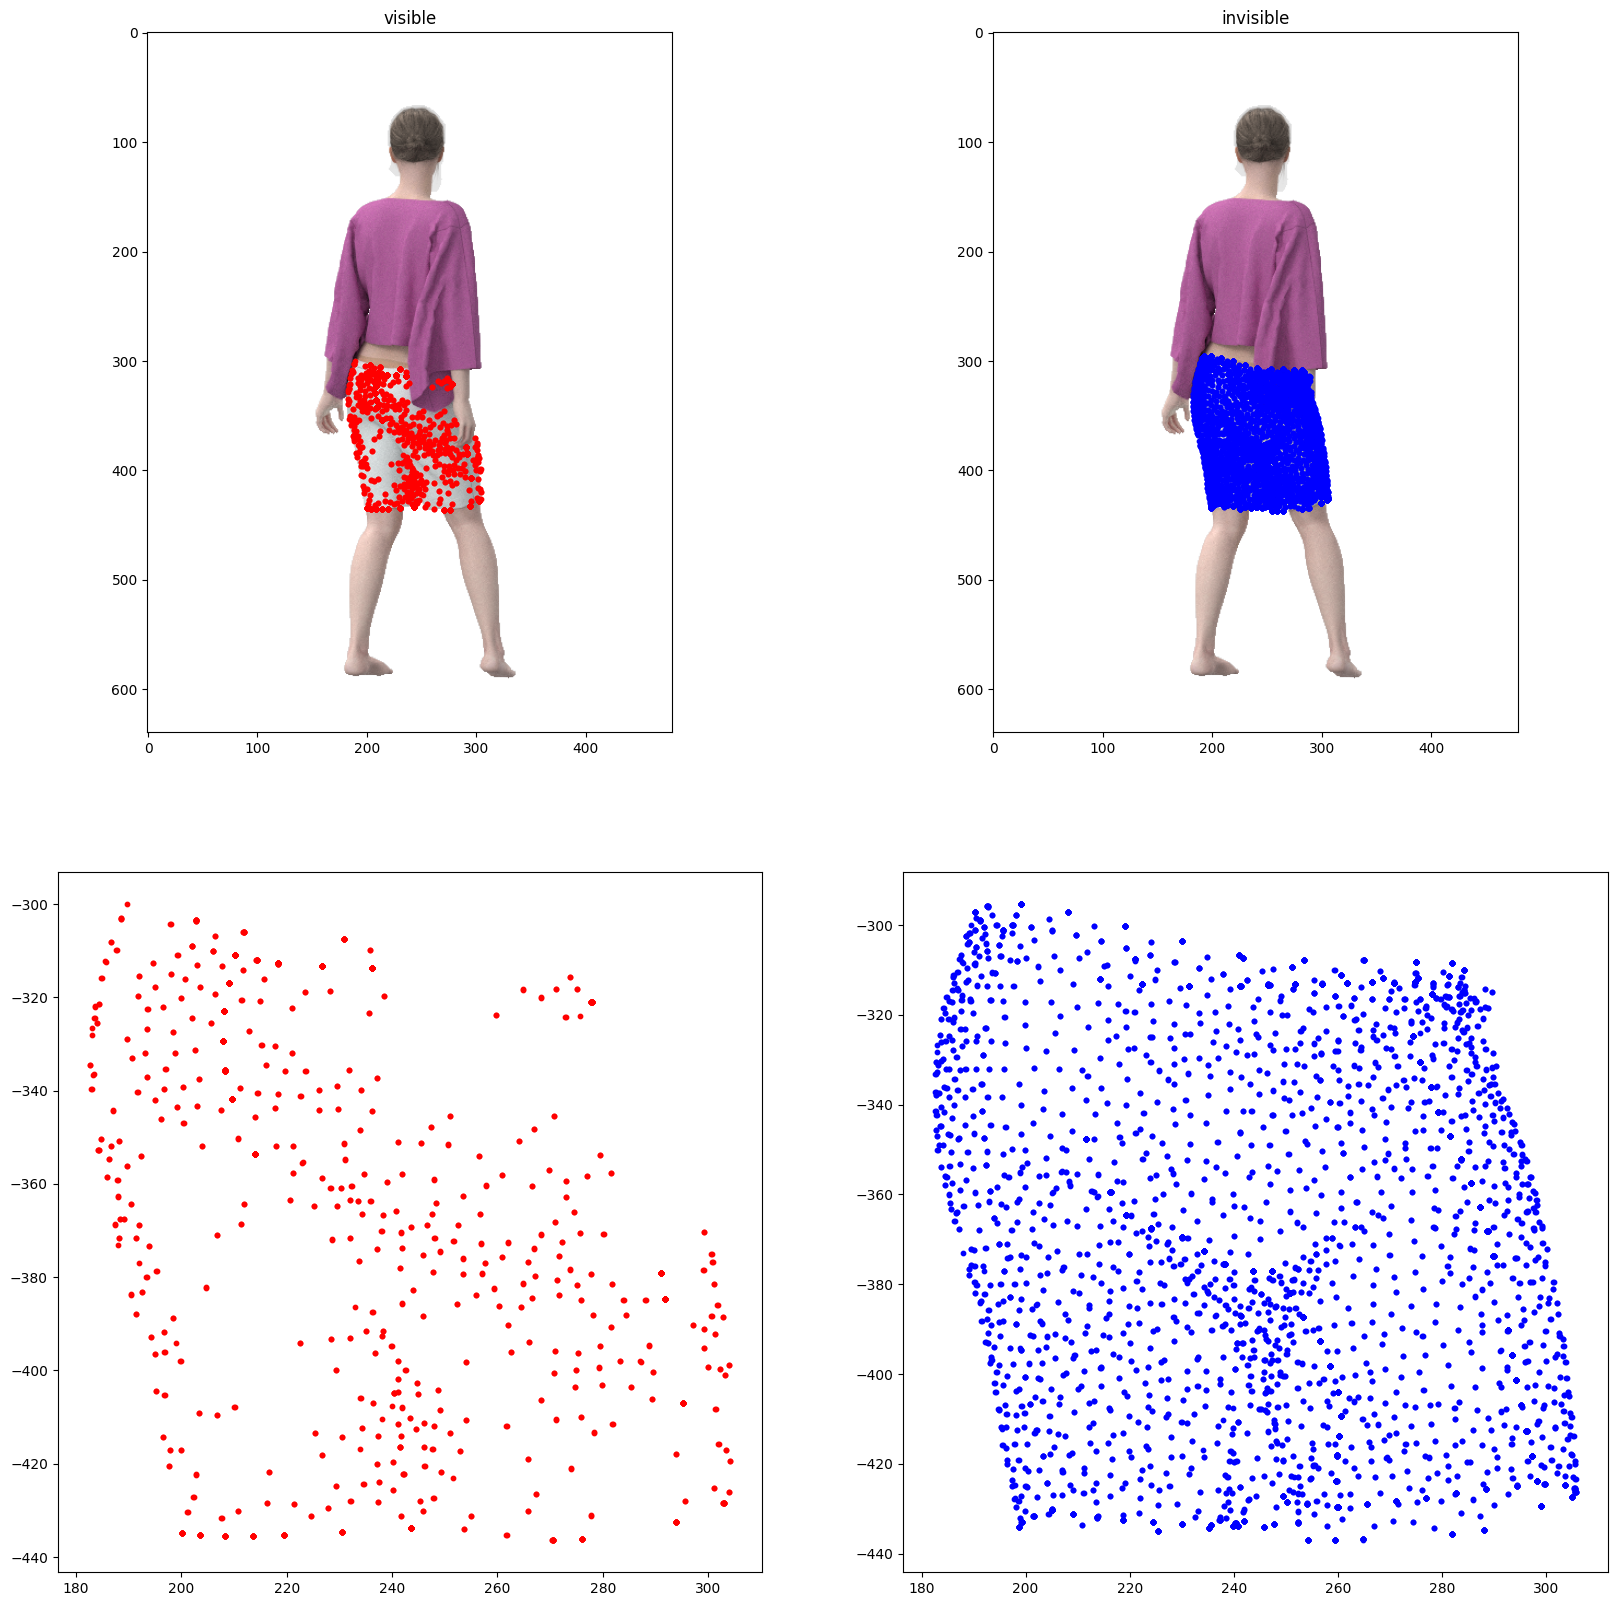

(11791,) (11791, 2)


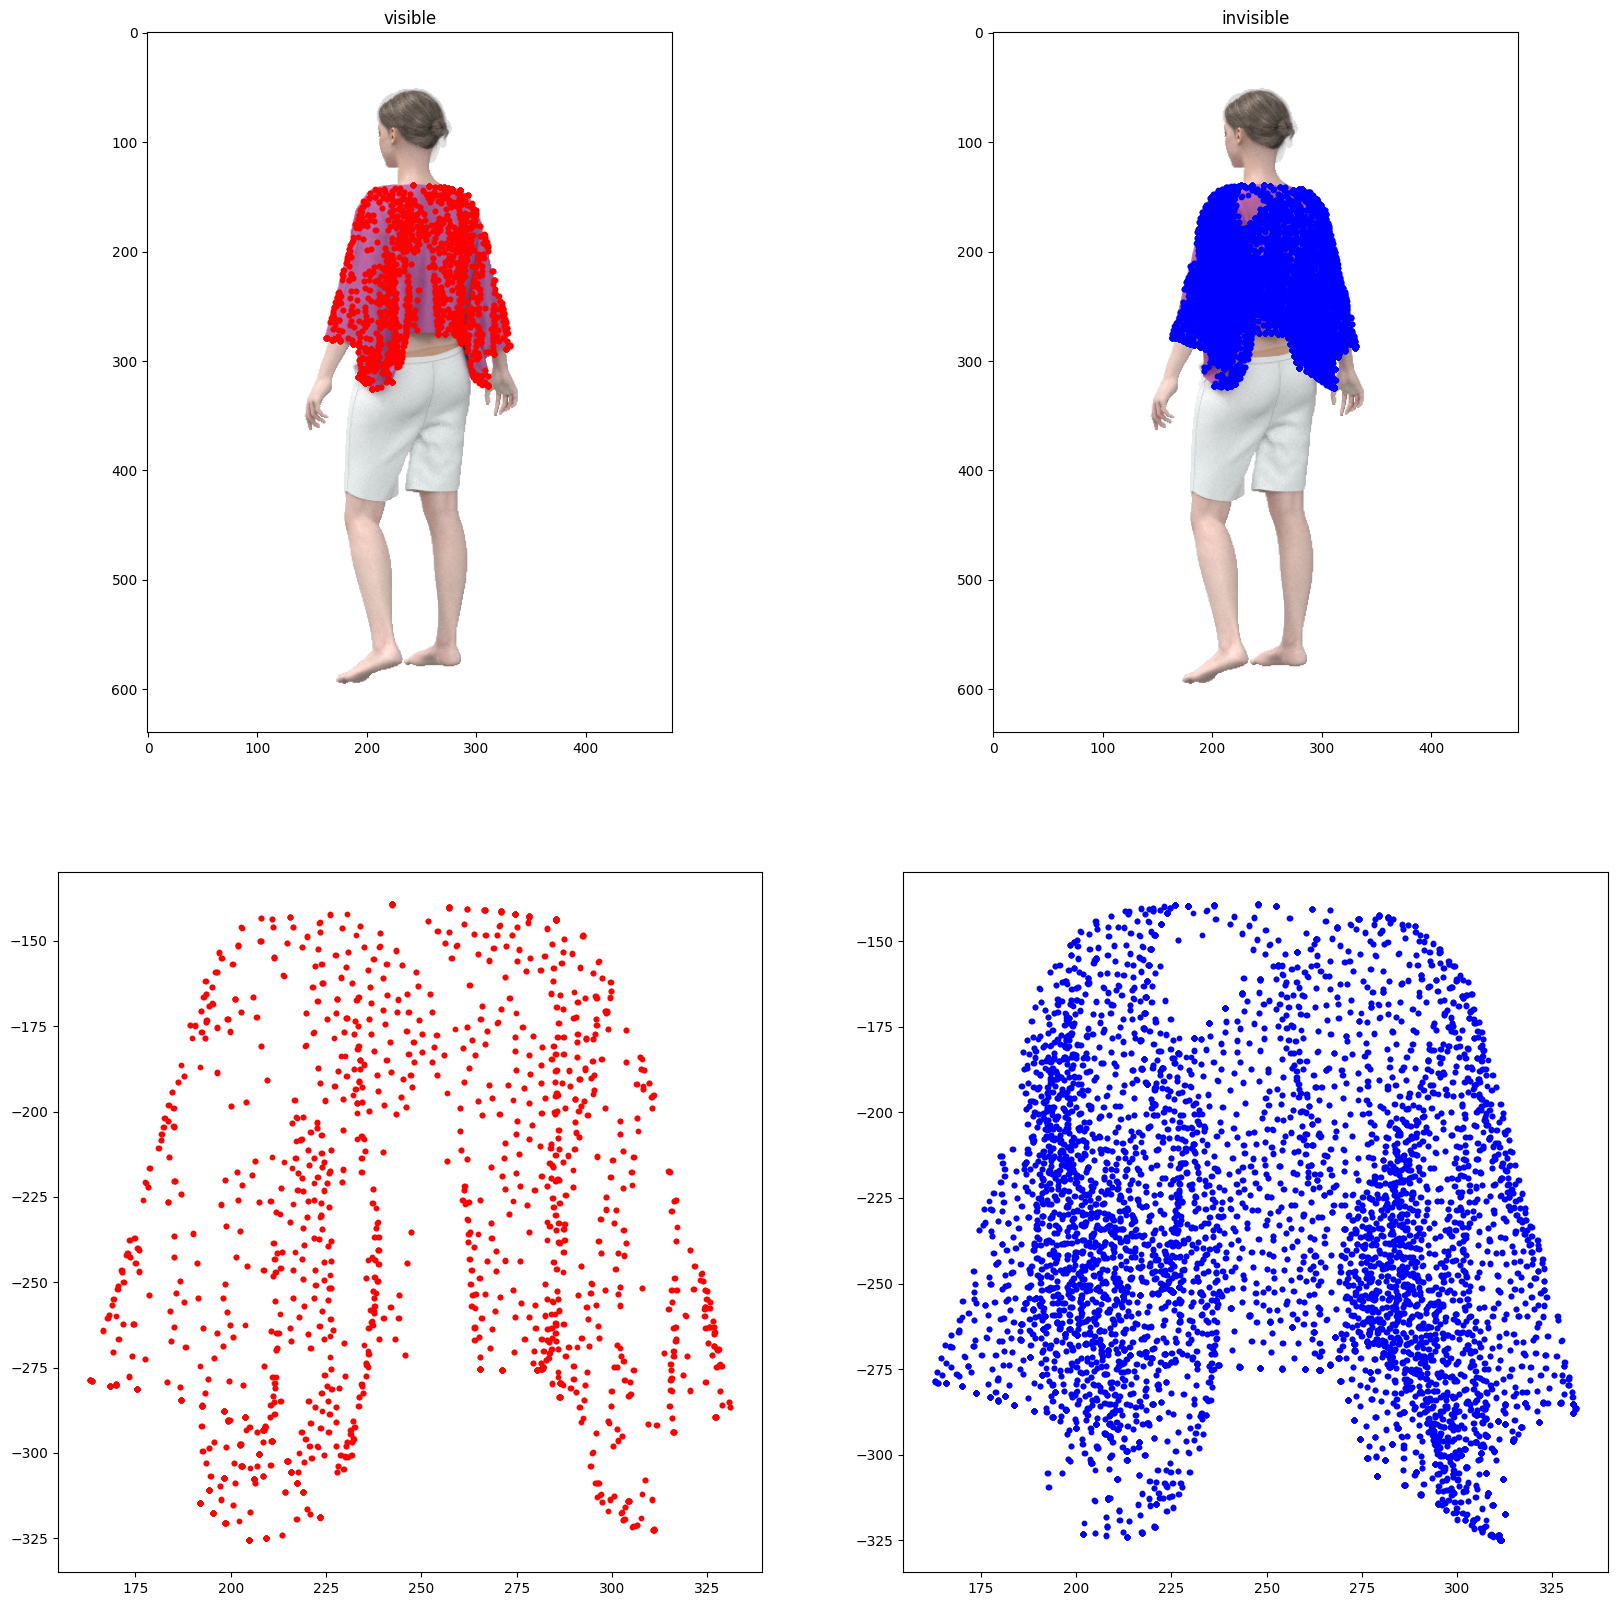

(5599,) (5599, 2)


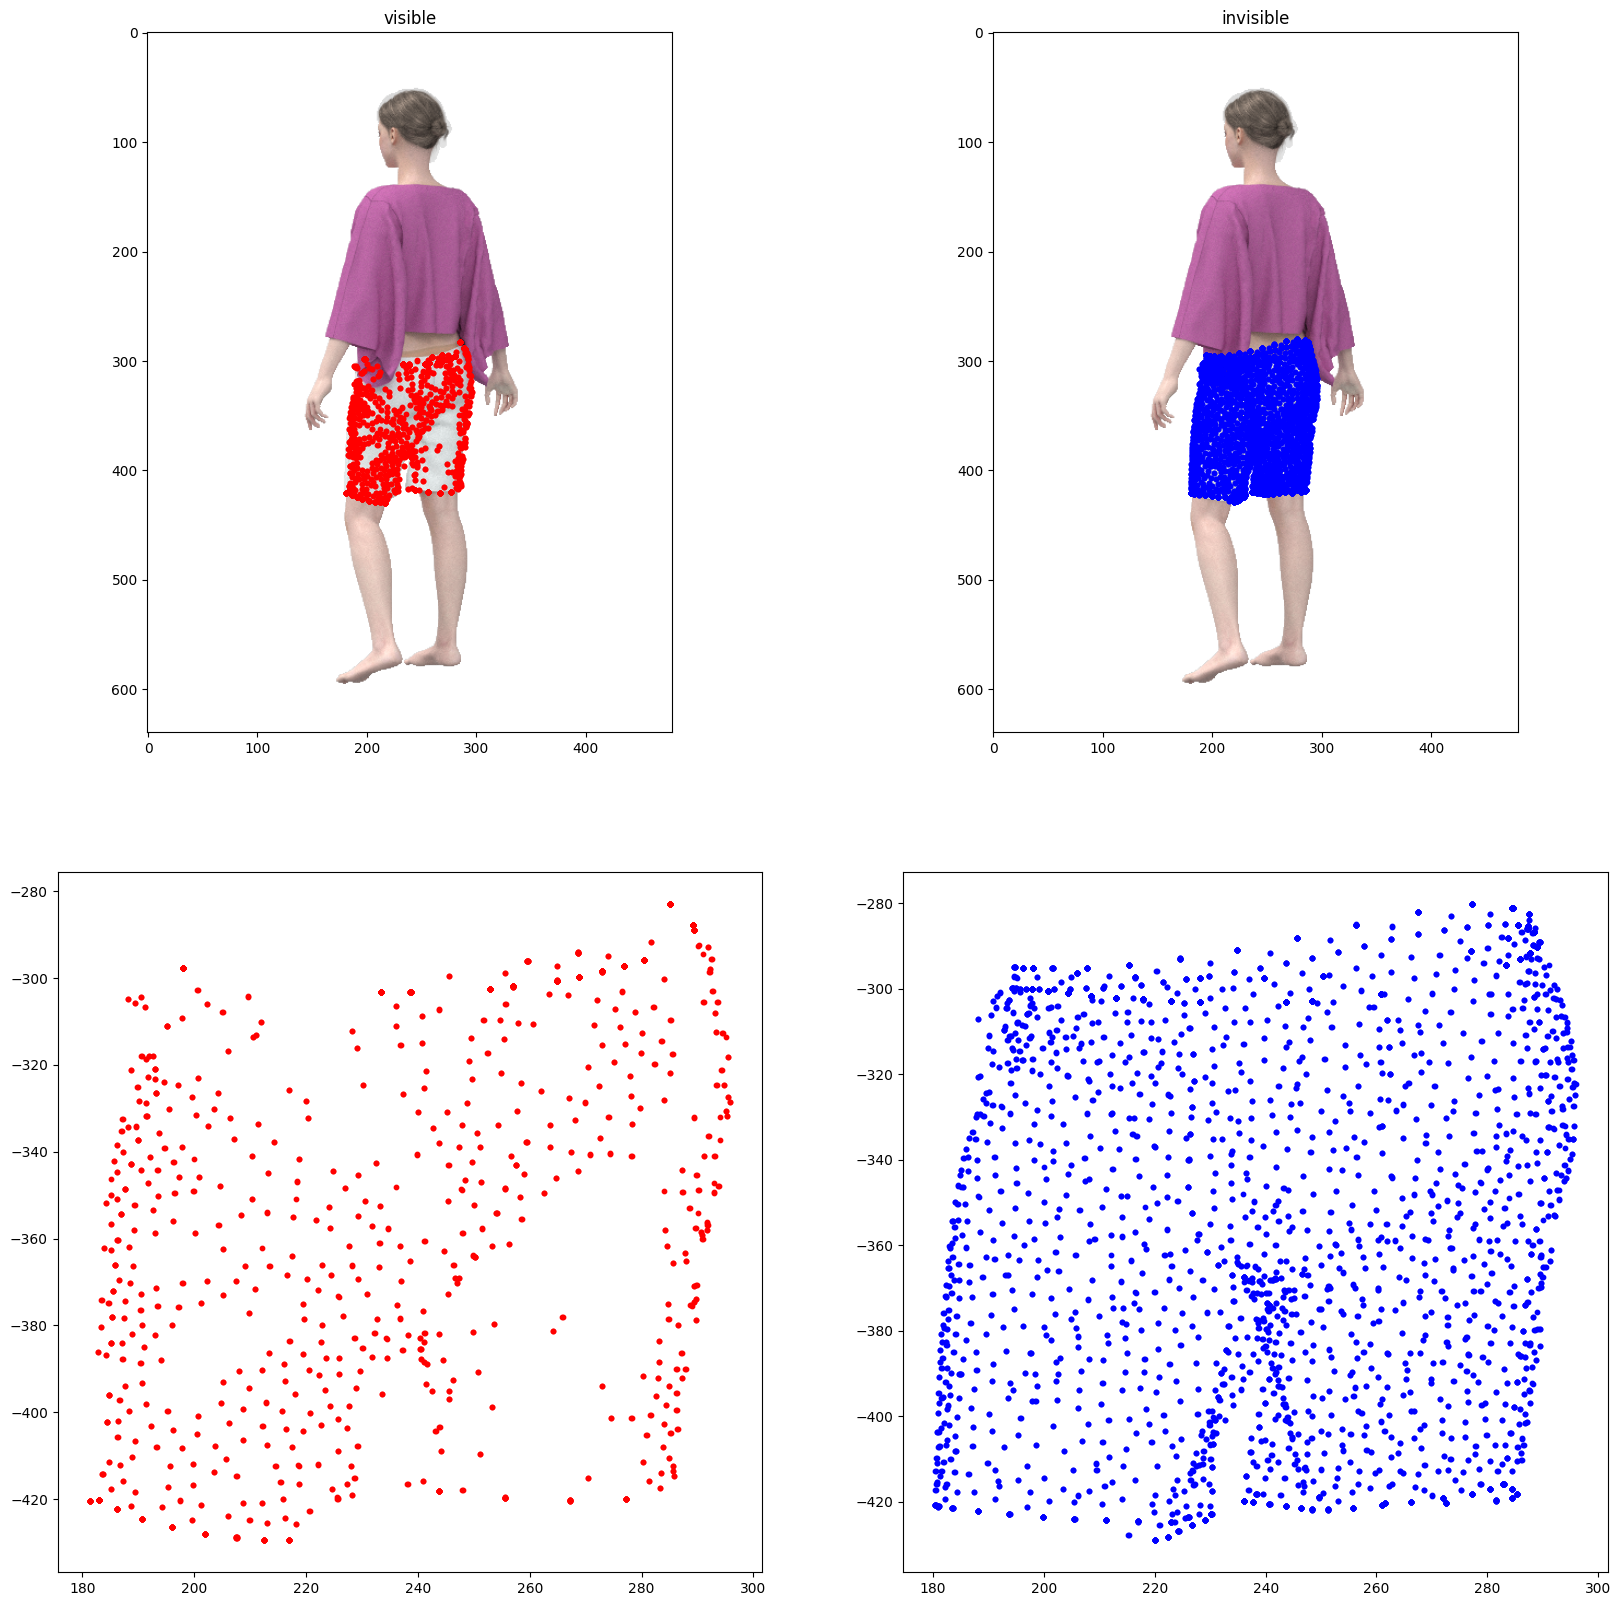

(12673,) (12673, 2)


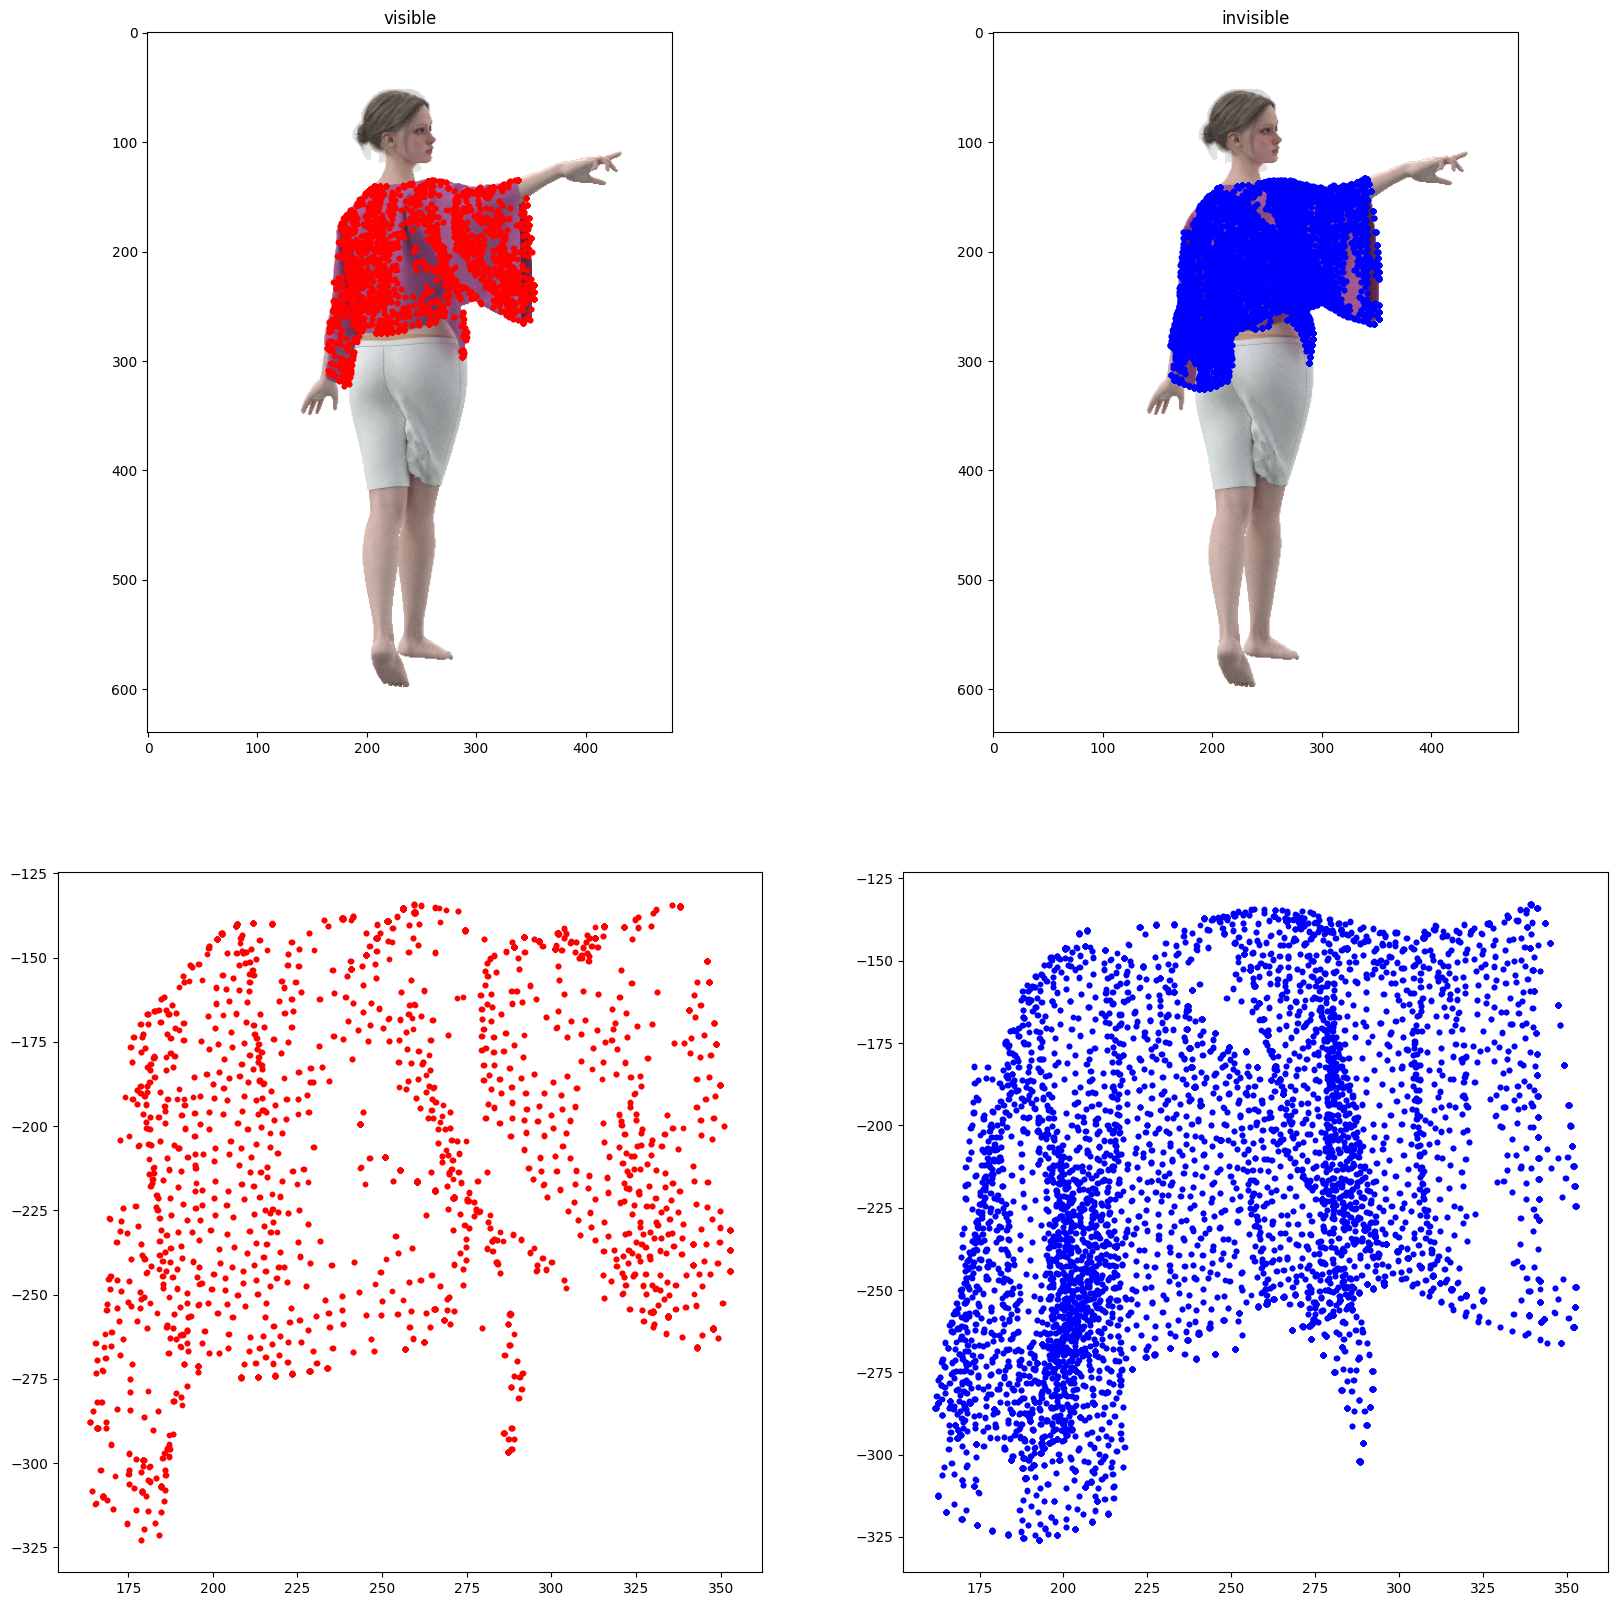

(5096,) (5096, 2)


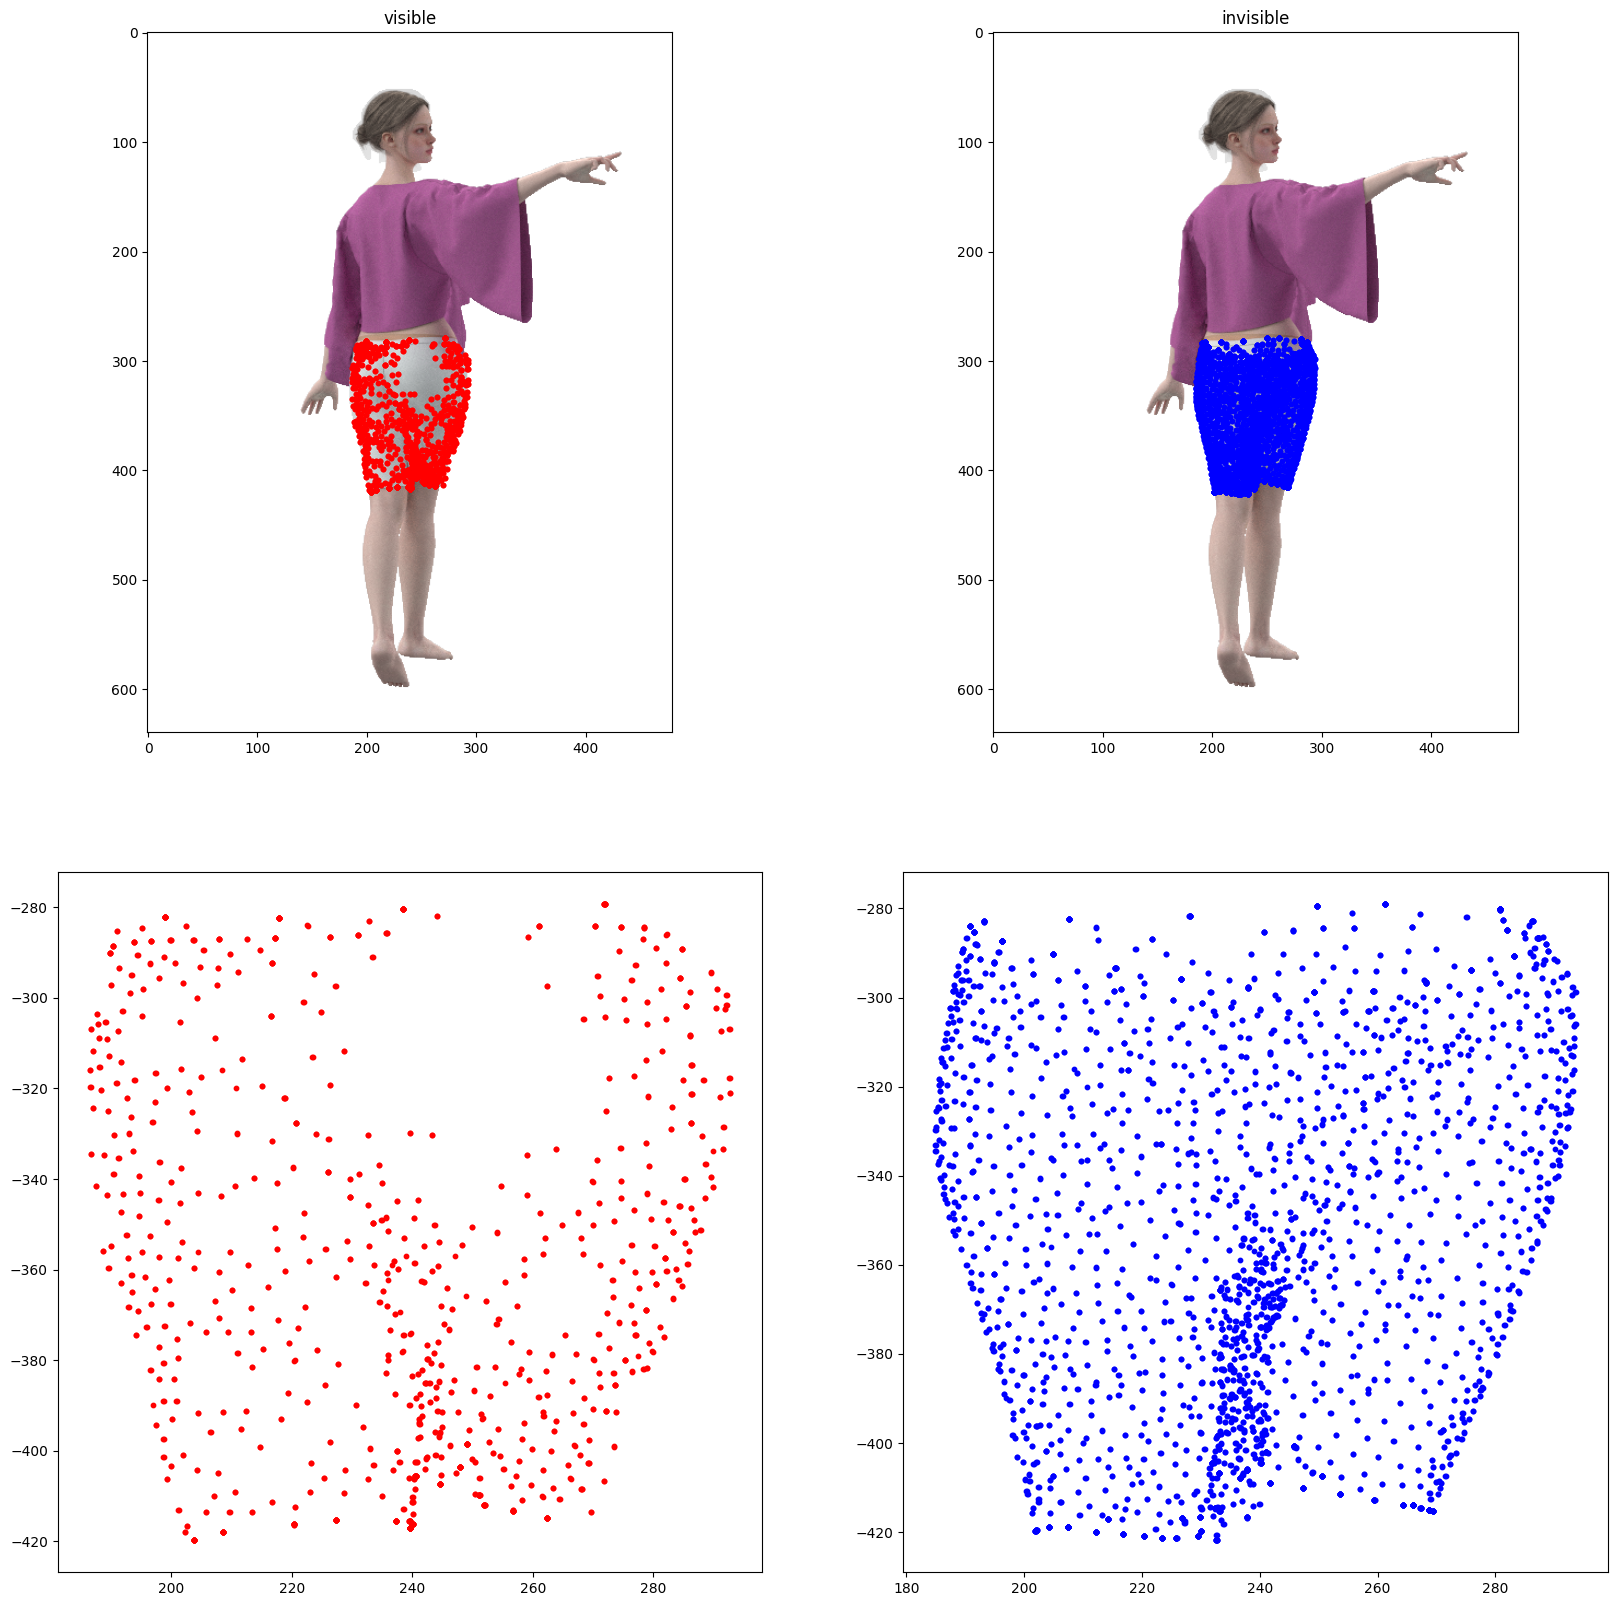

(11791,) (11791, 2)


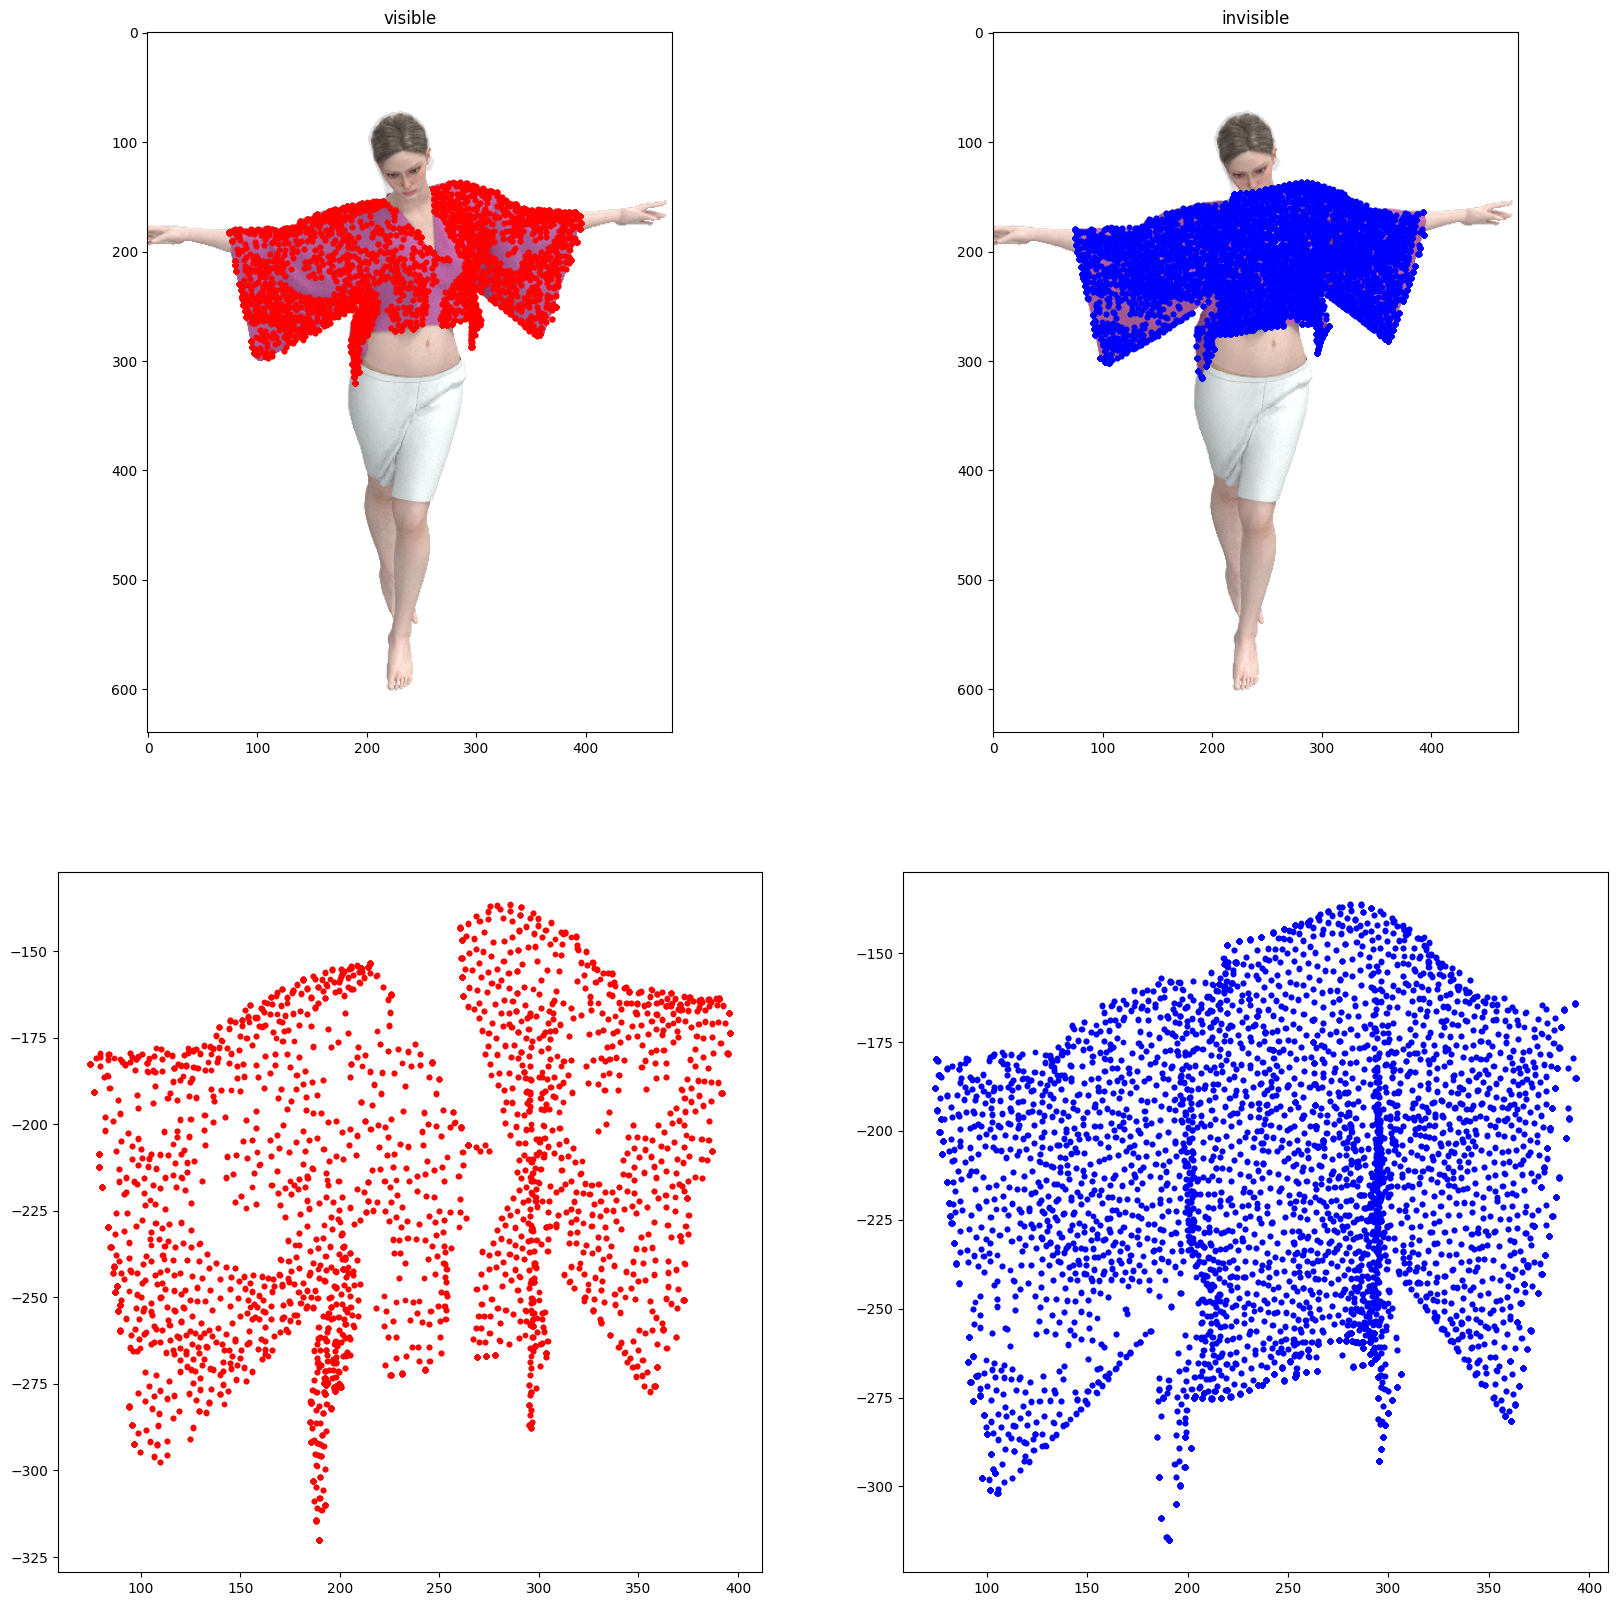

(5600,) (5600, 2)


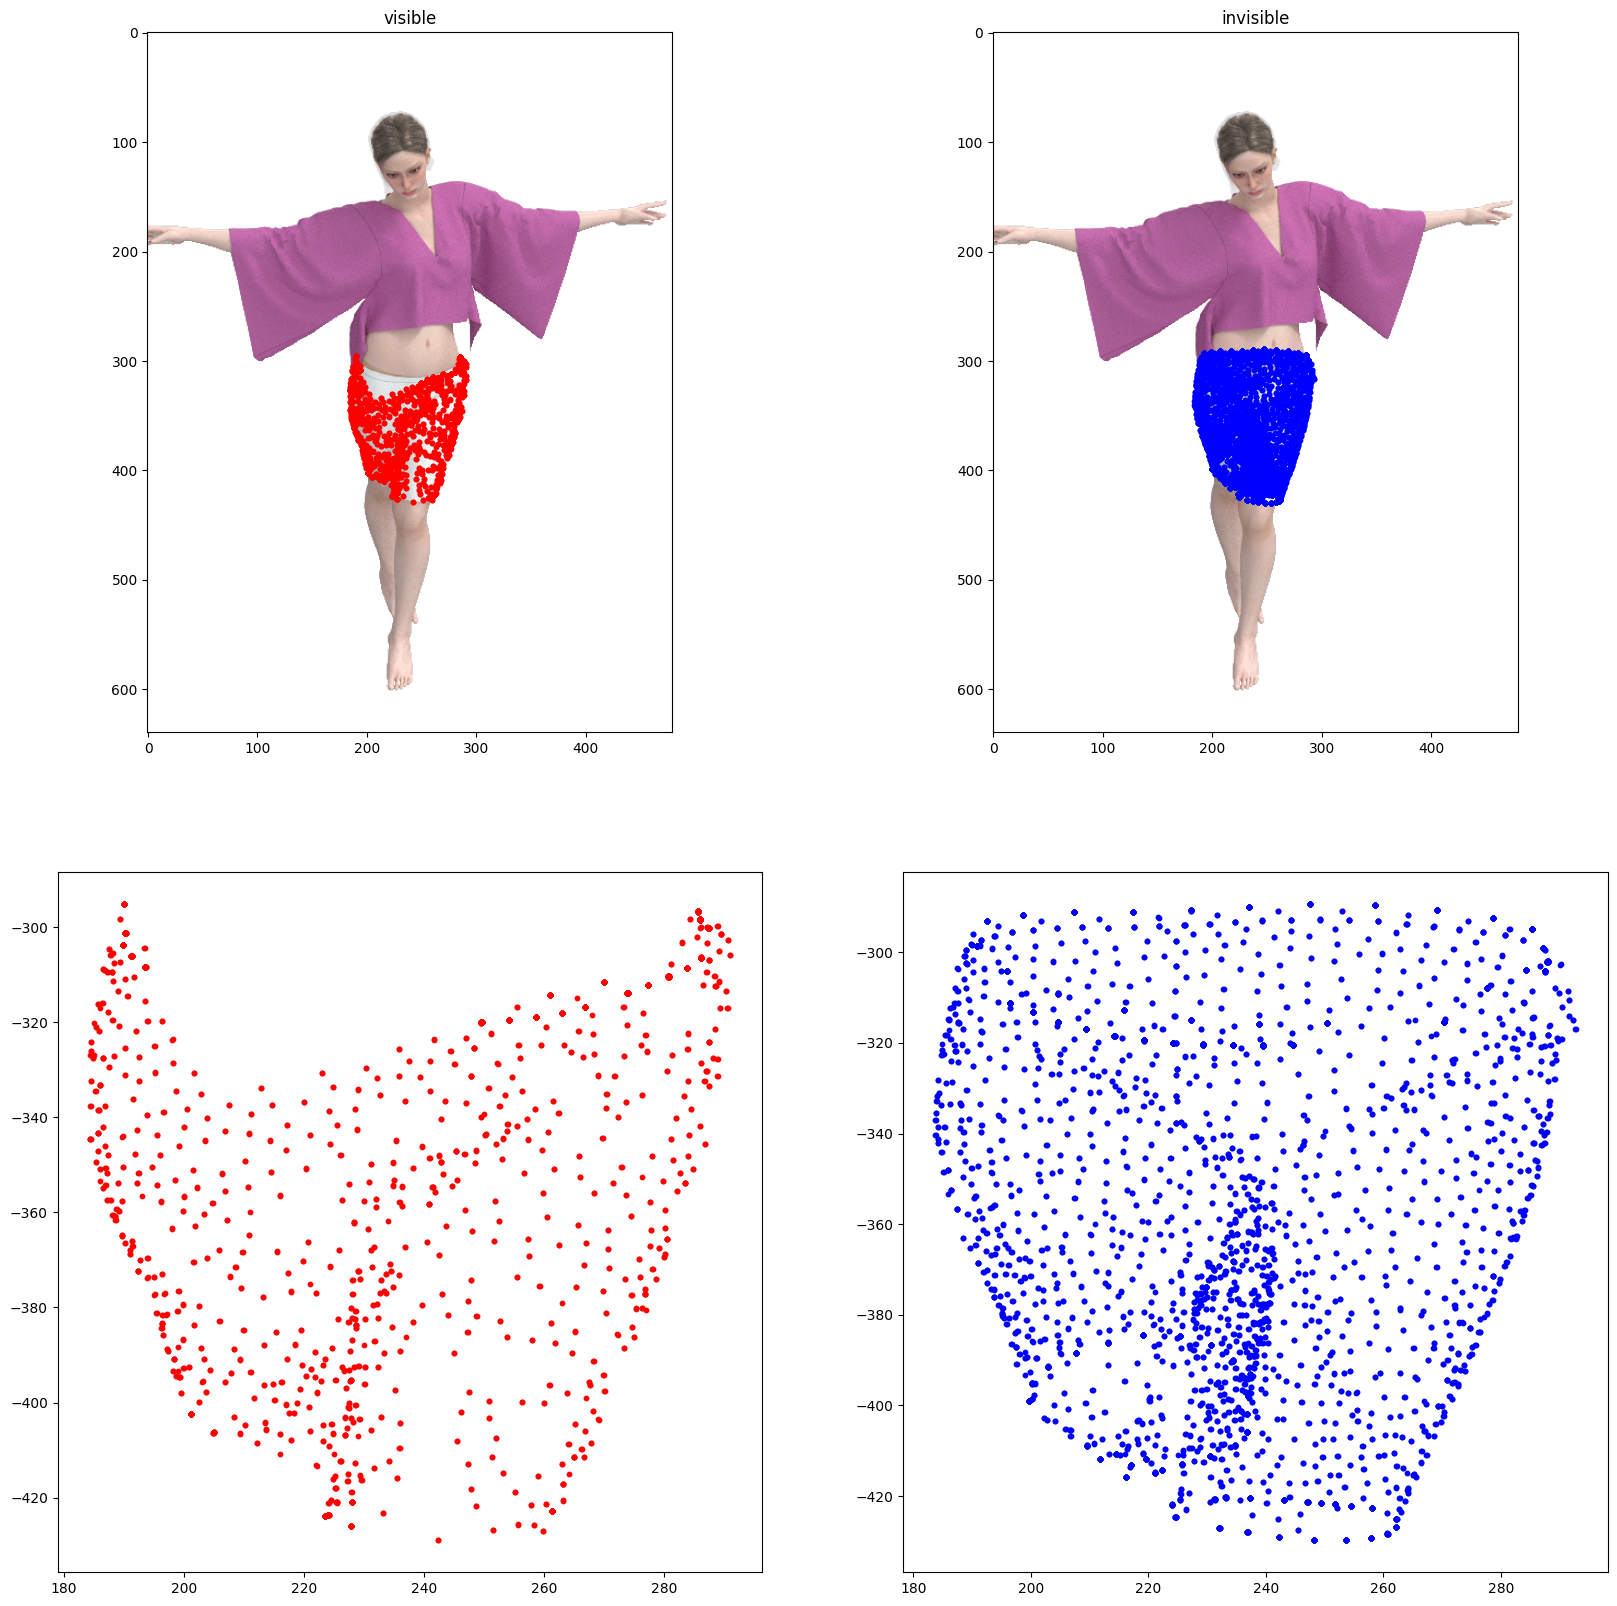

In [408]:
# from simple_visibility_detection import (
#     CloCamera, 
#     get_visible_vertices_simple, 
#     get_visible_vertices_with_occlusion,
#     visualize_visibility_simple
# )

DEPTH_TOLERANCE = 40.0

for view_name, depth in zip(scene.view_name_list, depth_list) :
    cam_name, pose_name = view_name.split("__")
    cam_info = camera_info[cam_name]
    
    body_mesh = scene.body_mesh_dict[view_name]
    garment_mesh_list = list(scene.garment_mesh_dict_dict[view_name].values())

    img = plt.imread(Path(scene.garment_dir) / f"{view_name}.png")
    
    vis_mask_list, pix_coords_list, depths_list = get_visible_vertices_with_occlusion(
        [body_mesh] + garment_mesh_list,
        cam_info,
        depth_map=depth,
        depth_tolerance=DEPTH_TOLERANCE,
    )

    for vis_mask, pix_coords in zip(
        vis_mask_list[1:], pix_coords_list[1:]
    ) :
        
        print(vis_mask.shape, pix_coords.shape)
        
        invis_mask = ~vis_mask
        
        plt.figure(figsize=(20, 20))
        plt.subplot(2, 2, 1)
        plt.title("visible")
        plt.imshow(img)
        plt.scatter(
            pix_coords[vis_mask][:, 0],
            pix_coords[vis_mask][:, 1],
            c="red",
            s=10,
        )
        
        plt.subplot(2, 2, 2)
        plt.title("invisible")
        plt.imshow(img)
        plt.scatter(
            pix_coords[invis_mask][:, 0],
            pix_coords[invis_mask][:, 1],
            c="blue",
            s=10,
        )
        
        plt.subplot(2, 2, 3)
        plt.scatter(
            pix_coords[vis_mask][:, 0],
            -pix_coords[vis_mask][:, 1],
            c="red",
            s=10,
        )
        
        plt.subplot(2, 2, 4)
        plt.scatter(
            pix_coords[invis_mask][:, 0],
            -pix_coords[invis_mask][:, 1],
            c="blue",
            s=10,
        )
        
        
        plt.show()


In [407]:


def get_visible_vertices_simple(
    mesh, 
    camera: CloCamera,
    depth_map=None,
    depth_tolerance=2.0,
    use_depth_test=True
):
    """
    Simple and accurate visibility detection for CLO camera and mesh.
    
    Args:
        mesh: Trimesh object
        camera: CloCamera object with cam2world, fov, width, height
        depth_map: Optional depth map for occlusion testing
        depth_tolerance: Tolerance for depth comparison
        use_depth_test: Whether to use depth map for occlusion testing
    
    Returns:
        visibility_mask: Boolean array indicating visible vertices
        pixel_coords: Pixel coordinates for each vertex
        depths: Depth values for each vertex
    """
    
    # Get camera parameters
    cam2world = camera.cam2world
    fov_rad = np.deg2rad(camera.fov)
    width, height = camera.width, camera.height
    
    # Camera position (inverse of cam2world translation)
    camera_pos = -cam2world[:3, :3].T @ cam2world[:3, 3]
    
    # Create projection matrix
    aspect = width / height
    near, far = 0.1, 10000.0
    
    proj_matrix = np.array([
        [1/(aspect * np.tan(fov_rad/2)), 0, 0, 0],
        [0, 1/np.tan(fov_rad/2), 0, 0],
        [0, 0, -(far + near)/(far - near), -2*far*near/(far - near)],
        [0, 0, -1, 0]
    ])
    
    # Transform vertices to camera space
    vertices_homog = np.hstack([mesh.vertices, np.ones((mesh.vertices.shape[0], 1))])
    view_matrix = np.linalg.inv(cam2world)
    view_proj = proj_matrix @ view_matrix
    projected = vertices_homog @ view_proj.T
    
    # Store w coordinates before perspective division
    w_coords = projected[:, 3].copy()
    
    # Perspective division
    depths = projected[:, 2].copy()
    projected = projected[:, :3] / projected[:, 3:4]
    
    # Convert to pixel coordinates
    pixel_coords = np.zeros((projected.shape[0], 2))
    pixel_coords[:, 0] = (projected[:, 0] + 1.0) * width / 2.0
    pixel_coords[:, 1] = height - (projected[:, 1] + 1.0) * height / 2.0
    
    # Initialize visibility mask
    visibility_mask = np.zeros(len(mesh.vertices), dtype=bool)
    
    # Basic frustum culling
    in_frustum = (
        (depths > 0) &  # In front of camera
        (w_coords > 0) &  # Valid projection (w > 0)
        (pixel_coords[:, 0] >= 0) & (pixel_coords[:, 0] < width) &
        (pixel_coords[:, 1] >= 0) & (pixel_coords[:, 1] < height)
    )
    
    # Mark vertices in frustum as potentially visible
    visibility_mask[in_frustum] = True
    
    # If depth map is provided, perform occlusion testing
    if use_depth_test and depth_map is not None:
        for i in np.where(in_frustum)[0]:
            px, py = int(pixel_coords[i, 0]), int(pixel_coords[i, 1])
            
            if 0 <= px < width and 0 <= py < height:
                depth_at_pixel = depth_map[py, px]
                vertex_depth = depths[i]
                
                # Check if vertex is occluded
                if abs(vertex_depth - depth_at_pixel) > depth_tolerance:
                    visibility_mask[i] = False
    
    return visibility_mask, pixel_coords, depths


def get_visible_vertices_with_occlusion(
    mesh_list, 
    camera: CloCamera,
    depth_map,
    depth_tolerance=2.0
):
    """
    Get visible vertices for multiple meshes with occlusion testing.
    
    Args:
        mesh_list: List of trimesh objects
        camera: CloCamera object
        depth_map: Depth map from rendering
        depth_tolerance: Tolerance for depth comparison
    
    Returns:
        visibility_mask_list: List of visibility masks for each mesh
        pixel_coords_list: List of pixel coordinates for each mesh
        depths_list: List of depth values for each mesh
    """
    
    visibility_mask_list = []
    pixel_coords_list = []
    depths_list = []
    
    for mesh in mesh_list:
        vis_mask, pix_coords, depths = get_visible_vertices_simple(
            mesh, camera, depth_map, depth_tolerance, use_depth_test=True
        )
        
        visibility_mask_list.append(vis_mask)
        pixel_coords_list.append(pix_coords)
        depths_list.append(depths)
    
    return visibility_mask_list, pixel_coords_list, depths_list


def visualize_visibility_simple(
    mesh_list,
    visibility_mask_list,
    pixel_coords_list,
    camera: CloCamera,
    rendered_image=None,
    save_path=None
):
    """
    Simple visualization of visibility results.
    
    Args:
        mesh_list: List of meshes
        visibility_mask_list: List of visibility masks
        pixel_coords_list: List of pixel coordinates
        camera: CloCamera object
        rendered_image: Optional rendered image for background
        save_path: Optional path to save visualization
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Create a blank image if no rendered image provided
    if rendered_image is None:
        rendered_image = np.ones((camera.height, camera.width, 3))
    
    # Original image
    axes[0, 0].imshow(rendered_image)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Visible vertices overlay
    axes[0, 1].imshow(rendered_image)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(mesh_list)))
    
    for i, (vis_mask, pix_coords) in enumerate(zip(visibility_mask_list, pixel_coords_list)):
        visible_pixels = pix_coords[vis_mask]
        if len(visible_pixels) > 0:
            axes[0, 1].scatter(
                visible_pixels[:, 0], visible_pixels[:, 1],
                s=2, alpha=0.8, color=colors[i], label=f'Mesh {i+1}'
            )
    
    axes[0, 1].set_title('Visible Vertices')
    axes[0, 1].legend()
    axes[0, 1].axis('off')
    
    # Visibility mask
    mask_overlay = np.zeros((camera.height, camera.width, 4), dtype=np.uint8)
    mask_overlay[:, :, 3] = 255  # Alpha channel
    
    for i, (vis_mask, pix_coords) in enumerate(zip(visibility_mask_list, pixel_coords_list)):
        visible_pixels = pix_coords[vis_mask].astype(int)
        color = (colors[i][:3] * 255).astype(np.uint8)
        
        for px, py in visible_pixels:
            if 0 <= px < camera.width and 0 <= py < camera.height:
                mask_overlay[py, px, :3] = color
                mask_overlay[py, px, 3] = 255
    
    axes[1, 0].imshow(mask_overlay)
    axes[1, 0].set_title('Visibility Mask')
    axes[1, 0].axis('off')
    
    # Statistics
    total_vertices = sum(len(mesh.vertices) for mesh in mesh_list)
    visible_vertices = sum(np.sum(mask) for mask in visibility_mask_list)
    visibility_percentage = (visible_vertices / total_vertices) * 100 if total_vertices > 0 else 0
    
    axes[1, 1].text(0.1, 0.9, f'Camera: {camera.name}', fontsize=12, fontweight='bold')
    axes[1, 1].text(0.1, 0.8, f'Resolution: {camera.width}x{camera.height}', fontsize=10)
    axes[1, 1].text(0.1, 0.7, f'FOV: {camera.fov}°', fontsize=10)
    axes[1, 1].text(0.1, 0.6, f'Total Vertices: {total_vertices}', fontsize=10)
    axes[1, 1].text(0.1, 0.5, f'Visible Vertices: {visible_vertices}', fontsize=10)
    axes[1, 1].text(0.1, 0.4, f'Visibility: {visibility_percentage:.1f}%', fontsize=10)
    
    for i, (mesh, mask) in enumerate(zip(mesh_list, visibility_mask_list)):
        mesh_visibility = (np.sum(mask) / len(mesh.vertices)) * 100 if len(mesh.vertices) > 0 else 0
        axes[1, 1].text(0.1, 0.3 - i*0.08, f'Mesh {i+1}: {mesh_visibility:.1f}% ({np.sum(mask)}/{len(mesh.vertices)})', 
                        fontsize=9, color=colors[i])
    
    axes[1, 1].set_title('Visibility Statistics')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


# Example usage function
def example_usage():
    """
    Example of how to use the visibility detection functions.
    """
    
    # Example camera (replace with your actual camera)
    camera = CloCamera(
        name='Custom_View_1',
        cam2world=np.array([
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 896.122],
            [0.0, 0.0, 1.0, 7998.56],
            [0.0, 0.0, 0.0, 1.0]
        ]),
        fov=15,
        width=480,
        height=640
    )
    
    # Example usage:
    # 1. For single mesh without depth testing:
    # vis_mask, pix_coords, depths = get_visible_vertices_simple(mesh, camera)
    
    # 2. For multiple meshes with depth testing:
    # vis_masks, pix_coords_list, depths_list = get_visible_vertices_with_occlusion(
    #     mesh_list, camera, depth_map
    # )
    
    # 3. Visualize results:
    # visualize_visibility_simple(mesh_list, vis_masks, pix_coords_list, camera, rendered_image)
    
    print("Visibility detection functions ready to use!")
    print("Use get_visible_vertices_simple() for single mesh")
    print("Use get_visible_vertices_with_occlusion() for multiple meshes with occlusion")
    print("Use visualize_visibility_simple() for visualization")
